In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
#from Database.TPData import TPData, TPDataDa, TPDataAssembly

from Strategies.LeadLagRegression_strategy.backtest_class import BacktestLL
from Strategies.LeadLagRegression_strategy.strategy_class import StrategyLL, VolumeClass
tol=(1e-1)/2

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
#5	17	0.1	1.00	-0.75	

In [5]:
#1.2	60	0.3	0.6	1.0	-1.0	

In [6]:
#0.2750	0.2500	60	0.3	0.6	2.0	-1.0

In [7]:
MACD_long_threshold = 0.075
MACD_short_threshold = -0.050
price_diff_long_threshold = 0.150
price_diff_short_threshold = -0.100

combined_long_threshold = 0.275
combined_short_threshold = 0.25

combined_mode=False

burnout_period=60
stop_profit = 0.3
makeagg_ratio = 0.6
trail_stop=0.8

take_profit=2
stop_loss=-1


br_fee = 0.0175
closing_mode='Martinovo_zatvaranie'

In [8]:
%store -r dates_fltr

# OOT part - Jan, Feb 

## Data preparation

In [9]:
data_lead = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_jan_feb.parquet', engine='fastparquet').reset_index()
data_lag = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_jan_feb.parquet', engine='fastparquet').reset_index()

In [10]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [11]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [12]:
#data_lag=data_lag.drop(index=177223).reset_index()
del data_lag['level_0']
del data_lead['level_0']

In [13]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
17,17,2024-01-02 09:00:26,NaN,NaN,83.25,86.37,84.810,1,269.0
18,18,2024-01-02 09:00:30,NaN,NaN,83.25,86.25,84.750,1,4.0
19,19,2024-01-02 09:01:32,NaN,NaN,83.25,86.00,84.625,1,62.0
20,20,2024-01-02 09:09:57,NaN,NaN,83.25,85.99,84.620,1,505.0
21,21,2024-01-02 09:11:07,NaN,NaN,82.43,85.99,84.210,1,70.0


In [14]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
1,1,2024-01-02 09:00:00.907744884,91.97,2.0,91.97,92.50,92.235,0
2,2,2024-01-02 09:00:40.962116718,92.00,3.0,91.96,92.49,92.225,0
3,3,2024-01-02 09:00:41.104269743,91.97,1.0,91.96,92.49,92.225,0
4,4,2024-01-02 09:00:41.159442425,92.00,1.0,91.96,92.49,92.225,0
5,5,2024-01-02 09:00:50.746176004,91.96,3.0,91.96,92.00,91.980,0


## Parameters and calculations

In [15]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [16]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

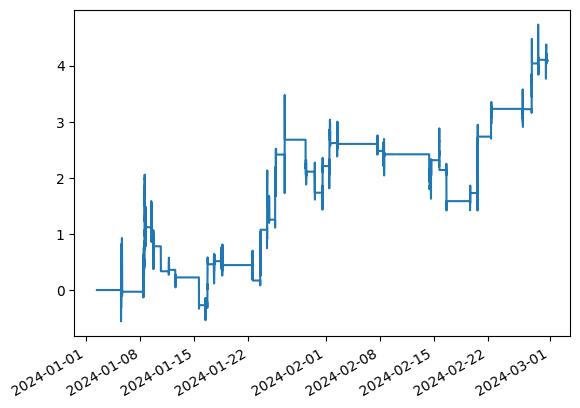

In [17]:
xx.plot()

In [18]:
#df[0:50]

In [19]:
xx[-1:]

2024-02-29 17:59:55    4.09
dtype: float64

# OOT part - Mar,Apr

## Data preparation

In [20]:
data_lead = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_mar_apr.parquet', engine='fastparquet').reset_index()
data_lag = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_mar_apr.parquet', engine='fastparquet').reset_index()

In [21]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [22]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [23]:
#data_lag=data_lag.drop(index=177223).reset_index()
del data_lag['level_0']
del data_lead['level_0']

In [24]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
1279,1279,2024-03-01 09:00:00,NaN,NaN,52.97,53.45,53.210,1,1.0
1280,1280,2024-03-01 09:00:01,NaN,NaN,52.97,53.41,53.190,1,1.0
1281,1281,2024-03-01 09:00:02,NaN,NaN,52.76,53.35,53.055,1,1.0
1282,1282,2024-03-01 09:00:03,NaN,NaN,52.83,53.31,53.070,1,1.0
1283,1283,2024-03-01 09:00:04,NaN,NaN,52.87,53.31,53.090,1,1.0


In [25]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
15,15,2024-03-01 09:00:09.338750124,56.41,2.0,56.41,56.61,56.510,0
16,16,2024-03-01 09:03:07.821218967,56.65,1.0,56.47,56.65,56.560,1
17,17,2024-03-01 09:03:07.821283579,56.70,5.0,56.47,56.65,56.560,1
18,18,2024-03-01 09:03:08.110189915,56.73,1.0,56.49,56.65,56.570,1
19,19,2024-03-01 09:03:14.834126711,56.90,1.0,56.72,56.89,56.805,1


## Parameters and calculations

In [26]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [27]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])
# df['price_level']=df['price_level']-df['position']*br_fee

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

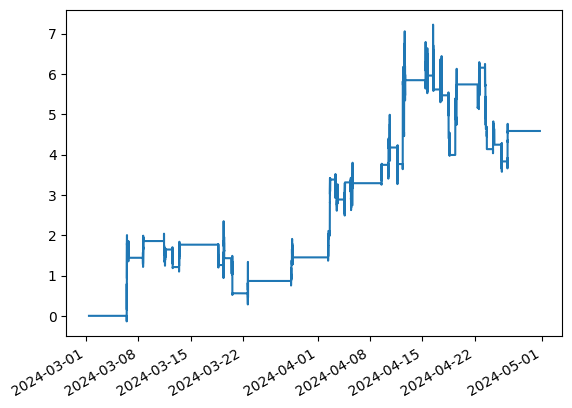

In [28]:
xx.plot()

In [29]:
#df[0:50]

In [30]:
xx[-1:]

2024-04-30 17:59:58    4.585
dtype: float64

# OOT part - May, Jun

## Data preparation

In [31]:
data_lead = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_may_june.parquet', engine='fastparquet').reset_index()
data_lag = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_may_june.parquet', engine='fastparquet').reset_index()

In [32]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [33]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [34]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [35]:
del data_lag['level_0']
del data_lead['level_0']
data_lag=data_lag.drop(index=49887).reset_index()
del data_lag['level_0']


In [36]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
0,875,2024-05-02 09:00:02,NaN,NaN,68.90,70.93,69.915,1,17.0
1,876,2024-05-02 09:00:39,NaN,NaN,68.90,70.94,69.920,1,37.0
2,877,2024-05-02 09:01:01,NaN,NaN,68.88,70.94,69.910,1,22.0
3,878,2024-05-02 09:01:02,NaN,NaN,68.86,70.94,69.900,1,1.0
4,879,2024-05-02 09:01:54,NaN,NaN,68.82,70.94,69.880,1,52.0


In [37]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
35,35,2024-05-02 09:02:02.465197325,65.81,2.0,65.81,66.15,65.980,0
36,36,2024-05-02 09:03:31.473956823,66.00,1.0,65.75,65.99,65.870,1
37,37,2024-05-02 09:03:31.575801849,66.00,1.0,65.75,65.99,65.870,1
38,38,2024-05-02 09:03:32.014014244,65.99,1.0,65.75,65.99,65.870,1
39,39,2024-05-02 09:04:00.009787560,65.99,1.0,65.76,65.95,65.855,1


## Parameters and calculations

In [38]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [39]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

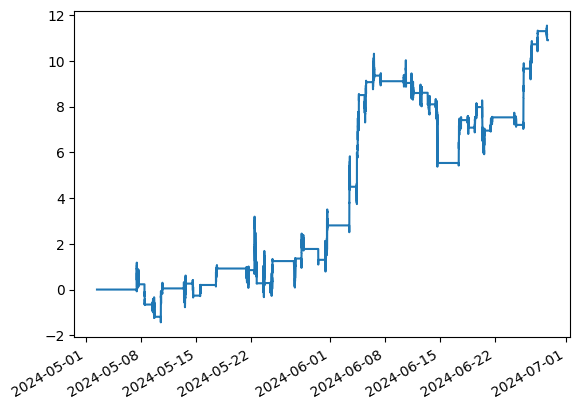

In [40]:
xx.plot()

In [41]:
#df[0:50]

In [42]:
xx[-1:]

2024-06-28 17:59:45    10.905
dtype: float64

# OOT part - July, Aug

## Data preparation

In [43]:
data_lead = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_jul_aug.parquet', engine='fastparquet').reset_index()
data_lag = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_jul_aug.parquet', engine='fastparquet').reset_index()

In [44]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [45]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [46]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [47]:
#data_lag=data_lag.drop(index=177223).reset_index()
del data_lag['level_0']
del data_lead['level_0']

In [48]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
469,469,2024-07-01 09:00:06.000000000,NaN,NaN,84.57,85.59,85.08,1.0,7.000000
470,470,2024-07-01 09:00:07.000000000,NaN,NaN,84.59,85.59,85.09,1.0,1.000000
471,471,2024-07-01 09:00:08.673907280,85.59,2.0,84.59,85.59,85.09,1.0,1.673907
472,472,2024-07-01 09:00:09.000000000,NaN,NaN,84.61,85.59,85.10,1.0,0.326093
473,473,2024-07-01 09:00:10.124257326,85.59,1.0,84.61,85.59,85.10,1.0,1.124257


In [49]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
123,123,2024-07-01 09:00:05.687479496,77.78,1.0,76.90,77.78,77.34,1.0
124,124,2024-07-01 09:00:10.607145071,77.78,1.0,77.00,77.78,77.39,1.0
125,125,2024-07-01 09:00:21.248078108,77.87,8.0,77.17,77.87,77.52,1.0
126,126,2024-07-01 09:01:07.907927752,77.93,6.0,77.51,77.93,77.72,1.0
127,127,2024-07-01 09:01:07.907927752,77.95,1.0,77.51,77.93,77.72,1.0


## Parameters and calculations

In [50]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [51]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

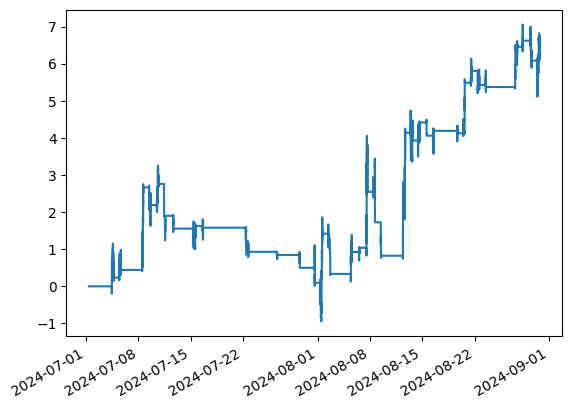

In [52]:
xx.plot()

In [53]:
#df[0:50]

In [54]:
xx[-1:]

2024-08-30 17:59:50.029918909    6.15
dtype: float64

# OOT part - Sep, Oct

## Data preparation

In [55]:
data_lead = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_sep_oct.parquet', engine='fastparquet').reset_index()
data_lag = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_sep_oct.parquet', engine='fastparquet').reset_index()

In [56]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [57]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [58]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [59]:
#data_lag=data_lag.drop(index=177223).reset_index()
del data_lag['level_0']
del data_lead['level_0']

In [60]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
1889,1889,2024-09-02 09:00:00.017744303,101.86,1.0,101.86,102.0,101.93,-1.0,0.823274
1890,1890,2024-09-02 09:00:03.019105434,101.87,1.0,101.86,102.0,101.93,-1.0,3.001361
1891,1891,2024-09-02 09:00:03.019105434,101.86,1.0,101.86,102.0,101.93,-1.0,0.000000
1892,1892,2024-09-02 09:00:03.310868263,101.86,1.0,101.86,102.0,101.93,-1.0,0.291763
1893,1893,2024-09-02 09:00:03.321099758,101.86,1.0,101.86,102.0,101.93,-1.0,0.010231


In [61]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
356,356,2024-09-02 09:00:00.374863148,91.10,1.0,91.01,91.09,91.050,1.0
357,357,2024-09-02 09:00:00.396098137,91.10,2.0,91.01,91.09,91.050,1.0
358,358,2024-09-02 09:00:00.475012779,91.09,1.0,91.01,91.09,91.050,1.0
359,359,2024-09-02 09:00:00.475463152,91.10,2.0,91.01,91.09,91.050,1.0
360,360,2024-09-02 09:01:00.238040686,91.10,1.0,91.01,91.10,91.055,1.0


## Parameters and calculations

In [62]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [63]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# # Convert 'timestamp' to datetime if not already
# df['timestamp'] = pd.to_datetime(df['timestamp'])

# # Assign color based on 'position' value
# df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
# df['price_level']=df['price_level']-df['position']*br_fee

# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

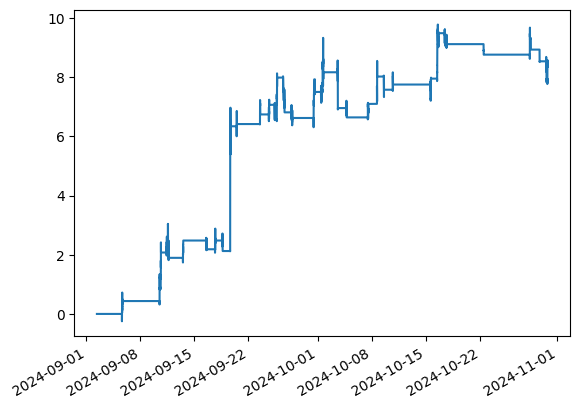

In [64]:
xx.plot()

In [65]:
#df[0:50]

In [66]:
xx[-1:]

2024-10-30 17:59:53.296451807    8.345
dtype: float64

# Production check

## Data preparation

In [335]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_production_sample.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_production_sample.csv',
                    parse_dates=['datetime']).reset_index()

In [336]:
data_lead['datetime'] = pd.to_datetime(data_lead['datetime'], errors='coerce')
data_lag['datetime'] = pd.to_datetime(data_lag['datetime'], errors='coerce')

In [337]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [338]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [339]:
# data_lag=data_lag.drop(index=177223).reset_index()
# del data_lag['level_0']

In [340]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
717,717,2024-10-25 09:00:09.000000000,NaN,NaN,91.00,91.15,91.075,NaN,27.827928
718,718,2024-10-25 09:00:09.934926987,91.23,1.0,91.00,91.15,91.075,1.0,0.934927
719,719,2024-10-25 09:00:24.000000000,NaN,NaN,91.11,91.15,91.130,NaN,14.065073
720,720,2024-10-25 09:00:41.311402082,91.22,1.0,91.11,91.15,91.130,1.0,17.311402
721,721,2024-10-25 09:00:42.338101149,91.22,1.0,91.11,91.15,91.130,1.0,1.026699


In [341]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
188,188,2024-10-25 09:00:47.387298822,97.06,1.0,96.88,97.06,96.970,1.0
189,189,2024-10-25 09:01:05.780653238,97.20,1.0,96.96,97.21,97.085,1.0
190,190,2024-10-25 09:01:06.691666842,97.21,1.0,96.96,97.20,97.080,1.0
191,191,2024-10-25 09:01:07.572153330,97.22,1.0,96.96,97.22,97.090,1.0
192,192,2024-10-25 09:01:08.770913124,97.22,1.0,96.96,97.28,97.120,1.0


## Parameters and calculations

In [342]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [343]:
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
import pandas as pd

# As

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
df['price_level']=df['price_level']-df['position']*br_fee

# Create ColumnDataSources
source_df = ColumnDataSource(df)
source_lead = ColumnDataSource(data_lead)
source_lag = ColumnDataSource(data_lag)

# Create a figure with dynamic sizing
p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# Adjust y-axes ranges
p.extra_y_ranges = {
   "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
   "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
}

# Add left and right y-axes
p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# Plotting with hover tools
lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# Define hover tools for each glyph
hover_position = HoverTool(renderers=[position_circles], tooltips=[
    ("Timestamp", "@timestamp{%F %T}"),
    ("Price Level", "@price_level"),
    ("Position", "@position"),
    ("Color", "@color"),
], formatters={'@timestamp': 'datetime'})

hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lead Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lag Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

# Add hover tools to the plot
p.add_tools(hover_position, hover_lead, hover_lag)

# Customize plot
p.legend.location = "top_left"
p.xaxis.axis_label = "Datetime"
p.yaxis.axis_label = "Price Level"

# Show the plot
show(p)

<Axes: >

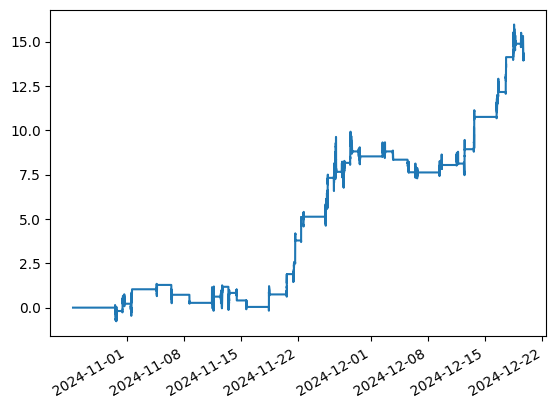

In [344]:
xx.plot()

In [345]:
#df[0:50]

In [346]:
xx[-1:]

2024-12-19 17:59:50    13.98
dtype: float64

In [347]:
# xx

In [348]:

# xx1.reset_index()

In [349]:
# start_time = '2024-06-20 10:27:04'
# end_time = '2024-06-20 10:27:09'

# a=df_ba_data1.reset_index()

# a[(a['timestamp'] >= start_time) & (a['timestamp'] <= end_time)]

In [350]:
# df=data_class.get_orders_data(mkt, tenor, venue_list, start_date1,
#                                           bT, eT, prod, start_date2)

In [351]:
# start_time = '2024-06-19 16:52:00'
# end_time = '2024-06-19 16:54:00'

# a=df.reset_index()

# type(a[(a['timestamp'] >= start_time) & (a['timestamp'] <= end_time)]['bids'][31920][0])

In [352]:
# start_time = '2024-06-19 16:52:00'
# end_time = '2024-06-19 16:54:00'

# ob_class.LoB_dict[130000].bids[1].po_id

# All periods

## Data preparation

In [270]:
data_lead =pd.concat([pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_jan_feb.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_mar_apr.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_may_june.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_jul_aug.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lead_dem1_sep_oct.parquet'        
                    ).reset_index()])

data_lag=pd.concat([pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_jan_feb.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_mar_apr.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_may_june.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_jul_aug.parquet'
                    ).reset_index(), pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_sep_oct.parquet'
                    ).reset_index()])


In [271]:
data_lead['datetime']=pd.to_datetime(data_lead['datetime'], format='mixed')
data_lag['datetime']=pd.to_datetime(data_lag['datetime'], format='mixed')

In [272]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [273]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [274]:
# data_lag=data_lag.drop(index=49887).reset_index()
del data_lag['level_0']
del data_lead['level_0']

In [275]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
17,17,2024-01-02 09:00:26,NaN,NaN,83.25,86.37,84.810,1.0,269.0
18,18,2024-01-02 09:00:30,NaN,NaN,83.25,86.25,84.750,1.0,4.0
19,19,2024-01-02 09:01:32,NaN,NaN,83.25,86.00,84.625,1.0,62.0
20,20,2024-01-02 09:09:57,NaN,NaN,83.25,85.99,84.620,1.0,505.0
21,21,2024-01-02 09:11:07,NaN,NaN,82.43,85.99,84.210,1.0,70.0


In [276]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
1,1,2024-01-02 09:00:00.907744884,91.97,2.0,91.97,92.50,92.235,0.0
2,2,2024-01-02 09:00:40.962116718,92.00,3.0,91.96,92.49,92.225,0.0
3,3,2024-01-02 09:00:41.104269743,91.97,1.0,91.96,92.49,92.225,0.0
4,4,2024-01-02 09:00:41.159442425,92.00,1.0,91.96,92.49,92.225,0.0
5,5,2024-01-02 09:00:50.746176004,91.96,3.0,91.96,92.00,91.980,0.0


## Parameters and calculations

In [277]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee

param_dict['MACD_long_threshold'] = MACD_long_threshold
param_dict['MACD_short_threshold'] = MACD_short_threshold
param_dict['price_diff_long_threshold'] = price_diff_long_threshold
param_dict['price_diff_short_threshold'] = price_diff_short_threshold

param_dict['combined_long_threshold'] = combined_long_threshold
param_dict['combined_short_threshold'] = combined_short_threshold

param_dict['burnout_period']=burnout_period
param_dict['stop_profit']=stop_profit
param_dict['makeagg_ratio']=makeagg_ratio
param_dict['trail_stop']=trail_stop

param_dict['combined_mode'] = combined_mode


vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False,
                            closing_mode=closing_mode)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in list(strategy_class.stats_dict.keys()) if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [278]:
# Convert 'timestamp' to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})
df['price_level']=df['price_level']-df['position']*br_fee

In [279]:
# from bokeh.plotting import figure, show, output_file
# from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
# import pandas as pd

# # Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context



# # Create ColumnDataSources
# source_df = ColumnDataSource(df)
# source_lead = ColumnDataSource(data_lead)
# source_lag = ColumnDataSource(data_lag)

# # Create a figure with dynamic sizing
# p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# # Adjust y-axes ranges
# p.extra_y_ranges = {
#    "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
#    "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
# }

# # Add left and right y-axes
# p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
# p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# # Plotting with hover tools
# lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
# lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
# position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# # Define hover tools for each glyph
# hover_position = HoverTool(renderers=[position_circles], tooltips=[
#     ("Timestamp", "@timestamp{%F %T}"),
#     ("Price Level", "@price_level"),
#     ("Position", "@position"),
#     ("Color", "@color"),
# ], formatters={'@timestamp': 'datetime'})

# hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lead Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
#     ("Datetime", "@datetime{%F %T}"),
#     ("Lag Price", "@trd_price"),
# ], formatters={'@datetime': 'datetime'})

# # Add hover tools to the plot
# p.add_tools(hover_position, hover_lead, hover_lag)

# # Customize plot
# p.legend.location = "top_left"
# p.xaxis.axis_label = "Datetime"
# p.yaxis.axis_label = "Price Level"

# # Show the plot
# show(p)

<Axes: >

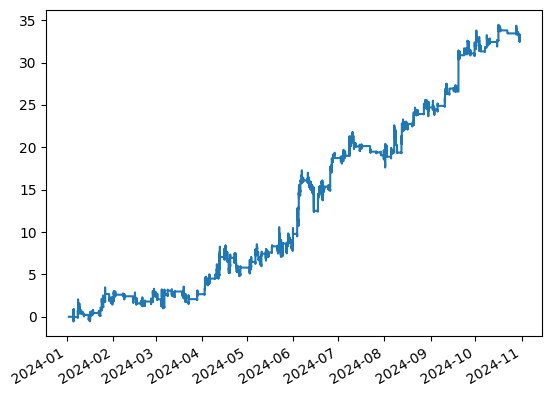

In [280]:
xx.plot()

In [281]:
#df[0:50]

In [282]:
xx[-1:]

2024-10-30 17:59:53.296451807    33.02
dtype: float64

In [283]:
df['date']=df['timestamp'].apply(lambda x: x.date())

In [284]:
# # Ensure that the index is a DatetimeIndex if not already
# xx.index = pd.to_datetime(xx.index)

# # Filter for dates in 2024
# dates_2024 = xx[xx.index.year == 2024].index.normalize().unique()

# # Iterate over each unique date in 2024 and plot
# for date in dates_2024:
#     daily_data = xx[(xx.index >= date) & (xx.index < date + pd.Timedelta(days=1))]
#     daily_data = daily_data-daily_data[0]
    
#     # Plot the data for the current date
#     plt.figure(figsize=(10, 6))
#     daily_data.plot()
#     plt.title(f"Data for {date.date()}")
#     plt.xlabel("Time")
#     plt.ylabel("Values")
#     plt.grid(True)
#     plt.show()

In [285]:
df['revenue']=-1*df['position']*df['price_level']

In [286]:
a=df.groupby('date')['revenue'].sum()

In [287]:
sum(a)

45.54999999999879

In [288]:
(a>0).value_counts()

revenue
True     100
False     70
Name: count, dtype: int64

In [289]:
len(df)

716

In [290]:
sum(a)/len(df)

0.0636173184357525

In [291]:
reutrn_df=pd.DataFrame(xx, columns=['returns'])

reutrn_df['returns']=reutrn_df['returns'].diff()
reutrn_df=reutrn_df[reutrn_df['returns']!=0]

In [292]:
# Select odd and even indexed rows
even_index = df.iloc[1::2]['revenue'].reset_index(drop=True)  # Rows 1, 3, 5, ...
odd_index = df.iloc[0::2]['revenue'].reset_index(drop=True)   # Rows 0, 2, 4, ...

# Subtract odd-indexed rows from even-indexed rows
difference = even_index + odd_index
reutrn_df=pd.DataFrame(difference)
reutrn_df.columns=['returns']
reutrn_df

,returns
0,0.85
1,-0.81
2,0.55
3,0.24
4,0.36
...,...
353,0.57
354,-0.33
355,-0.36
356,-0.59


Accuracy: 0.5251396648044693


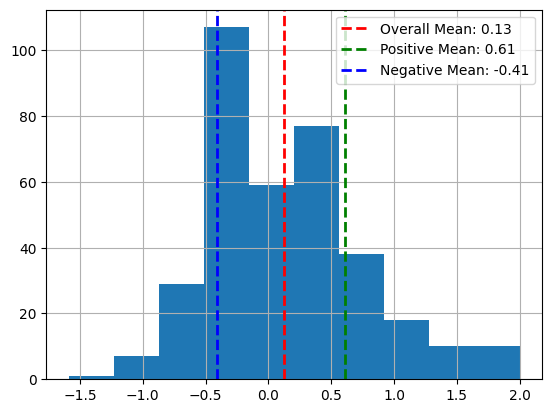

In [293]:
# Assuming 'reutrn_df' is a DataFrame and 'returns' is a column in it
overall_mean = reutrn_df['returns'].mean()
positive_mean = reutrn_df[reutrn_df['returns'] > 0]['returns'].mean()
negative_mean = reutrn_df[reutrn_df['returns'] < 0]['returns'].mean()
 
# Print accuracy
accuracy = sum(reutrn_df['returns'] > 0) / len(reutrn_df)
print('Accuracy:', accuracy)
 
# Plot histogram
reutrn_df[abs(reutrn_df['returns']) >= 0.01]['returns'].hist()
 
# Add vertical lines
plt.axvline(overall_mean, color='r', linestyle='dashed', linewidth=2, label=f'Overall Mean: {overall_mean:.2f}')
plt.axvline(positive_mean, color='g', linestyle='dashed', linewidth=2, label=f'Positive Mean: {positive_mean:.2f}')
plt.axvline(negative_mean, color='b', linestyle='dashed', linewidth=2, label=f'Negative Mean: {negative_mean:.2f}')
 
# Add a legend
plt.legend()
 
# Show plot
plt.show()

In [294]:

# Initialize variables
counts = []
current_value = None
current_count = 0

# Loop through the data
for value in pd.DataFrame(a>0)['revenue'].apply(int):
    if value == current_value:
        current_count += 1
    else:
        if current_value is not None:
            counts.append((current_value, current_count))
        current_value = value
        current_count = 1

# Append the last sequence
counts.append((current_value, current_count))

# Display the result
counts_df = pd.DataFrame(counts, columns=['Value', 'Count'])

counts_df[counts_df['Value']==1].value_counts()

Value  Count
1      1        19
       2        13
       3         8
       4         4
       5         3
Name: count, dtype: int64

In [295]:
# Step 1: Calculate sign changes (+1 for positive, -1 for negative)
signs = reutrn_df['returns'].apply(lambda x: 1 if x > 0 else -1)

# Step 2: Identify streaks by checking where the sign changes
streaks = (signs != signs.shift()).cumsum()

# Step 3: Group by streak and calculate streak lengths
streak_lengths = signs.groupby(streaks).size().reset_index(name='length')
streak_lengths['sign'] = signs.groupby(streaks).first().values

# Step 4: Distribution of positive and negative streaks
streak_distribution = streak_lengths.groupby(['sign', 'length']).size().unstack(fill_value=0)

streak_distribution

length,1,2,3,4,5
sign,,,,,
-1,58,30,13,2,1
1,57,25,14,6,3


In [296]:
production_trades=pd.read_csv(r'c:\Users\andrej\Projects\LeadLag\Leadlag_profits.csv', sep=';')
production_trades['Price']=production_trades['Price'].apply(lambda x: float(x.replace(',','.')))
# Select odd and even indexed rows
even_index = production_trades.iloc[1::2]['Price'].reset_index(drop=True)  # Rows 1, 3, 5, ...
odd_index = production_trades.iloc[0::2]['Price'].reset_index(drop=True)   # Rows 0, 2, 4, ...

# Subtract odd-indexed rows from even-indexed rows
difference = even_index + odd_index
reutrn_df_prod=pd.DataFrame(difference)
reutrn_df_prod.columns=['returns']


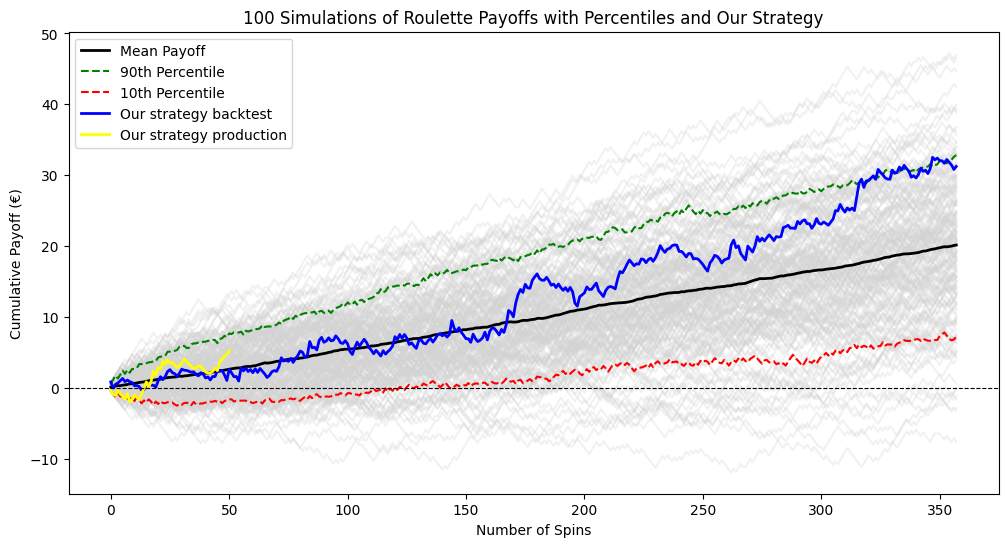

In [297]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_spins = int(len(df) / 2)  # Number of spins per simulation
num_simulations = 200  # Number of simulations
payoff_red = positive_mean - 0.04  # Payoff for red
payoff_black = negative_mean - 0.04  # Loss for black

# Roulette wheel setup
colors = ['red'] * 18 + ['black'] * 18 + ['green']

# Run simulations
all_simulations = []
np.random.seed(22)  # For reproducibility

for _ in range(num_simulations):
    results = np.random.choice(colors, num_spins)
    payoffs = [payoff_red if color == 'red' else payoff_black if color == 'black' else 0 for color in results]
    cumulative_payoffs = np.cumsum(payoffs)
    all_simulations.append(cumulative_payoffs)

# Convert to array for easier calculations
all_simulations = np.array(all_simulations)

# Calculate the mean, 75th percentile, and 25th percentile of cumulative payoffs
mean_payoff = all_simulations.mean(axis=0)
percentile_90 = np.percentile(all_simulations, 90, axis=0)
percentile_10 = np.percentile(all_simulations, 10, axis=0)

# Plot each simulation in one graph
plt.figure(figsize=(12, 6))
for i in range(num_simulations):
    plt.plot(all_simulations[i], color="lightgrey", alpha=0.3)

# Plot the mean of all simulations in black
plt.plot(mean_payoff, color="black", label="Mean Payoff", linewidth=2)

# Plot the 75th and 25th percentiles
plt.plot(percentile_90, color="green", linestyle="--", label="90th Percentile")
plt.plot(percentile_10, color="red", linestyle="--", label="10th Percentile")

# Plot the cumulative payoff of "Our strategy" if defined
plt.plot((reutrn_df['returns'] - 0.04).cumsum(), label="Our strategy backtest", color="blue", linewidth=2)
plt.plot((reutrn_df_prod['returns'] - 0.04).cumsum(), label="Our strategy production", color="yellow", linewidth=2)


# Plot formatting
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Zero line
plt.xlabel("Number of Spins")
plt.ylabel("Cumulative Payoff (€)")
plt.title("100 Simulations of Roulette Payoffs with Percentiles and Our Strategy")
plt.legend()
plt.show()

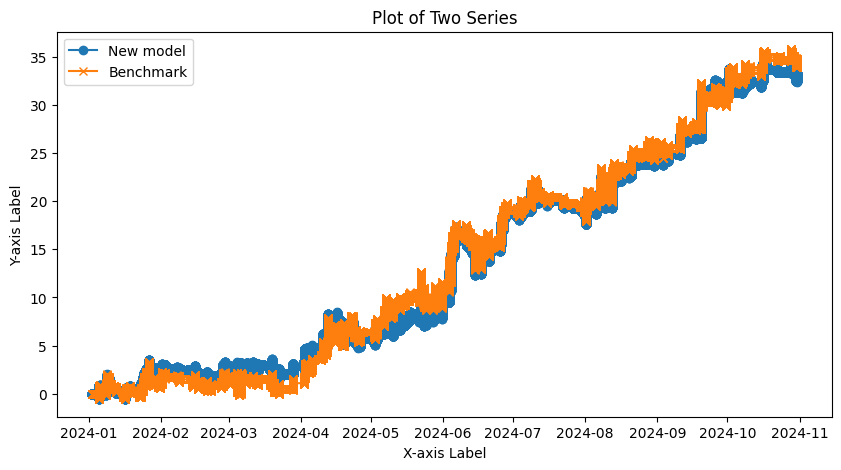

In [298]:
%store -r xx2

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(xx, label="New model", marker='o')
plt.plot(xx2, label="Benchmark", marker='x')


# Add labels and title
plt.xlabel("X-axis Label")
plt.ylabel("Y-axis Label")
plt.title("Plot of Two Series")

# Add legend
plt.legend()

# Show the plot
plt.show()

# Misc

In [299]:
# lag_price_tick=93.99923076923076
# coef1=0
# coef2=0.8661
# lead_price_tick=92.0
# lead_price=92.1

# lag_price_tick*np.exp((coef1+coef2*np.log(lead_price/lead_price_tick)))

In [300]:
# public_lead_trade_list=[(89.75, 1.0, 'Eurex T7/DEBM092024-20240822/2485/1', 1724323584.6690397), (89.75, 2.0, 'Eurex T7/DEBM092024-20240822/2480/2', 1724323559.7314084), (89.85, 1.0, 'Eurex T7/DEBM092024-20240822/2475/1', 1724323501.7010565), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/2454/1', 1724323439.289843), (89.94, 1.0, 'Eurex T7/DEBM092024-20240822/2392/1', 1724322914.0422606), (89.93, 1.0, 'Eurex T7/DEBM092024-20240822/2386/1', 1724322889.804086), (89.93, 1.0, 'Eurex T7/DEBM092024-20240822/2385/1', 1724322889.4707313), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/2384/1', 1724322888.9664116), (89.93, 1.0, 'Eurex T7/DEBM092024-20240822/2383/1', 1724322884.925085), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/2381/1', 1724322884.381066), (89.93, 1.0, 'Eurex T7/DEBM092024-20240822/2378/1', 1724322878.332864), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/2377/1', 1724322871.267875), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/2373/1', 1724322864.9656823), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/2370/1', 1724322864.143631), (89.94, 1.0, 'Eurex T7/DEBM092024-20240822/2368/1', 1724322862.936288), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/2357/1', 1724322814.2470136), (90.01, 1.0, 'Eurex T7/DEBM092024-20240822/2350/1', 1724322764.182361), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2348/1', 1724322764.0795631), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2347/1', 1724322759.9789553), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2346/1', 1724322758.2885172), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2345/1', 1724322752.0831337), (90.0, 3.0, 'Eurex T7/DEBM092024-20240822/2344/3', 1724322751.7735305), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2343/1', 1724322751.769698), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2342/1', 1724322751.758822), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2334/1', 1724322732.7743735), (90.0, 4.0, 'Eurex T7/DEBM092024-20240822/2333/4', 1724322732.7735443), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2331/1', 1724322720.0171447), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/2329/1', 1724322699.3170757), (90.01, 1.0, 'Eurex T7/DEBM092024-20240822/2326/1', 1724322675.822574), (90.01, 1.0, 'Eurex T7/DEBM092024-20240822/2323/1', 1724322665.801591), (90.01, 1.0, 'Eurex T7/DEBM092024-20240822/2322/1', 1724322660.7819748), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2310/1', 1724322638.2830148), (90.0, 4.0, 'Eurex T7/DEBM092024-20240822/2309/4', 1724322638.2698717), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/2308/1', 1724322638.25533), (90.0, 3.0, 'Eurex T7/DEBM092024-20240822/2305/3', 1724322635.9359868), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2303/1', 1724322635.8894951), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2301/1', 1724322635.8775277), (90.0, 2.0, 'Eurex T7/DEBM092024-20240822/2300/2', 1724322635.875678), (90.0, 3.0, 'Eurex T7/DEBM092024-20240822/2299/3', 1724322635.8755999), (90.0, 3.0, 'Eurex T7/DEBM092024-20240822/2295/3', 1724322635.8687346), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2294/1', 1724322635.86869), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2291/1', 1724322635.867508), (90.0, 2.0, 'Eurex T7/DEBM092024-20240822/2290/2', 1724322635.7464259), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2289/1', 1724322635.7326744), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2288/1', 1724322635.732644), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2287/1', 1724322635.7326035), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/2286/1', 1724322635.732501), (90.01, 2.0, 'Eurex T7/DEBM092024-20240822/2285/2', 1724322635.7211576), (90.01, 1.0, 'Eurex T7/DEBM092024-20240822/2284/1', 1724322635.7211225), (90.05, 3.0, 'Eurex T7/DEBM092024-20240822/2252/3', 1724322541.964349), (90.06, 1.0, 'Eurex T7/DEBM092024-20240822/2249/1', 1724322541.9541392), (90.1, 2.0, 'Eurex T7/DEBM092024-20240822/2234/2', 1724322428.2971294), (90.15, 2.0, 'Eurex T7/DEBM092024-20240822/2197/2', 1724321848.1932032), (90.15, 2.0, 'Eurex T7/DEBM092024-20240822/2189/2', 1724321827.6285326), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/2186/1', 1724321803.7072403), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/2184/1', 1724321803.6965804), (90.2, 3.0, 'Eurex T7/DEBM092024-20240822/2183/3', 1724321803.6858444), (90.25, 2.0, 'Eurex T7/DEBM092024-20240822/2140/2', 1724321382.4579003), (90.18, 1.0, 'Eurex T7/DEBM092024-20240822/2110/1', 1724321241.7975068), (90.17, 1.0, 'Eurex T7/DEBM092024-20240822/2109/1', 1724321241.7355912), (90.17, 2.0, 'Eurex T7/DEBM092024-20240822/2108/2', 1724321235.0889227), (90.15, 2.0, 'Eurex T7/DEBM092024-20240822/2104/2', 1724321225.557166), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/2102/1', 1724321223.4257717), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/2101/1', 1724321223.413177), (90.07, 1.0, 'Eurex T7/DEBM092024-20240822/2100/1', 1724321222.5468307), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/2096/1', 1724321216.6300557), (90.11, 3.0, 'Eurex T7/DEBM092024-20240822/2095/3', 1724321216.6299334), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/2088/1', 1724321210.0640044), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/2087/1', 1724321210.0639153), (90.15, 2.0, 'Eurex T7/DEBM092024-20240822/2083/2', 1724321097.8110332), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/2075/1', 1724321062.9818103), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/2071/1', 1724321059.0045133), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/2069/1', 1724321039.487842), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/2068/1', 1724321038.7834573), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/2067/1', 1724321038.5129883), (90.11, 2.0, 'Eurex T7/DEBM092024-20240822/2066/2', 1724321036.1058688), (90.11, 2.0, 'Eurex T7/DEBM092024-20240822/2060/2', 1724320968.1240356), (90.11, 1.0, 'Eurex T7/DEBM092024-20240822/2049/1', 1724320795.0470867), (90.11, 1.0, 'Eurex T7/DEBM092024-20240822/2048/1', 1724320795.0304368), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/2045/1', 1724320783.860824), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/2038/1', 1724320687.6638448), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/2037/1', 1724320687.6365929), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/2036/1', 1724320686.885352), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/2035/1', 1724320686.1036448), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/2034/1', 1724320686.0845134), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/2015/1', 1724320577.2968938), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/2012/1', 1724320577.2967677), (90.24, 1.0, 'Eurex T7/DEBM092024-20240822/1998/1', 1724320422.063694), (90.15, 3.0, 'Eurex T7/DEBM092024-20240822/1996/3', 1724320422.050002), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/1994/1', 1724320422.0498495), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1993/1', 1724320422.0498495), (90.24, 1.0, 'Eurex T7/DEBM092024-20240822/1988/1', 1724320410.2199693), (90.27, 1.0, 'Eurex T7/DEBM092024-20240822/1972/1', 1724320401.1404748), (90.33, 1.0, 'Eurex T7/DEBM092024-20240822/1943/1', 1724320246.60792), (90.35, 1.0, 'Eurex T7/DEBM092024-20240822/1942/1', 1724320246.6066291), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1916/1', 1724320035.7177026), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1915/1', 1724320035.704738), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1913/1', 1724320035.693319), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1911/1', 1724320035.6204538), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1910/1', 1724320035.6063516), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1909/1', 1724320035.6062608), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1905/1', 1724319990.3541467), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1904/1', 1724319990.3399336), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1903/1', 1724319990.3399003), (90.44, 1.0, 'Eurex T7/DEBM092024-20240822/1902/1', 1724319990.260911), (90.34, 2.0, 'Eurex T7/DEBM092024-20240822/1880/2', 1724319958.2520556), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1878/1', 1724319941.6093488), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1873/1', 1724319925.5459907), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1857/1', 1724319897.956918), (90.49, 1.0, 'Eurex T7/DEBM092024-20240822/1856/1', 1724319896.8039272), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1855/1', 1724319896.636464), (90.49, 1.0, 'Eurex T7/DEBM092024-20240822/1854/1', 1724319896.6217148), (90.42, 1.0, 'Eurex T7/DEBM092024-20240822/1853/1', 1724319895.0198953), (90.42, 1.0, 'Eurex T7/DEBM092024-20240822/1852/1', 1724319895.0198545), (90.42, 1.0, 'Eurex T7/DEBM092024-20240822/1837/1', 1724319873.4197235), (90.44, 1.0, 'Eurex T7/DEBM092024-20240822/1836/1', 1724319873.4192967), (90.44, 1.0, 'Eurex T7/DEBM092024-20240822/1823/1', 1724319786.9176896), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1804/1', 1724319601.4754653), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1790/1', 1724319537.901009), (90.49, 1.0, 'Eurex T7/DEBM092024-20240822/1789/1', 1724319537.8996992), (90.49, 1.0, 'Eurex T7/DEBM092024-20240822/1770/1', 1724319435.3499398), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1763/1', 1724319356.3868525), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1761/1', 1724319354.4957492), (90.5, 2.0, 'Eurex T7/DEBM092024-20240822/1760/2', 1724319354.4810712), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/1734/1', 1724319143.6556723), (90.44, 1.0, 'Eurex T7/DEBM092024-20240822/1726/1', 1724319143.4353316), (90.44, 1.0, 'Eurex T7/DEBM092024-20240822/1724/1', 1724319143.4331963), (90.4, 1.0, 'Eurex T7/DEBM092024-20240822/1720/1', 1724319143.4254236), (90.26, 1.0, 'Eurex T7/DEBM092024-20240822/1705/1', 1724319034.4221044), (90.26, 1.0, 'Eurex T7/DEBM092024-20240822/1704/1', 1724319034.4212987), (90.3, 4.0, 'Eurex T7/DEBM092024-20240822/1692/4', 1724318917.9666836), (90.29, 1.0, 'Eurex T7/DEBM092024-20240822/1601/1', 1724318419.2089596), (90.29, 1.0, 'Eurex T7/DEBM092024-20240822/1600/1', 1724318412.8888073), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/1598/1', 1724318412.7772825), (90.24, 2.0, 'Eurex T7/DEBM092024-20240822/1581/2', 1724318359.2311199), (90.24, 1.0, 'Eurex T7/DEBM092024-20240822/1558/1', 1724318181.4386687), (90.24, 1.0, 'Eurex T7/DEBM092024-20240822/1557/1', 1724318180.830302), (90.24, 2.0, 'Eurex T7/DEBM092024-20240822/1556/2', 1724318180.62851), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1550/1', 1724318166.4436169), (90.11, 1.0, 'Eurex T7/DEBM092024-20240822/1543/1', 1724318106.0028267), (90.19, 1.0, 'Eurex T7/DEBM092024-20240822/1541/1', 1724318100.0732207), (90.3, 2.0, 'Eurex T7/DEBM092024-20240822/1506/2', 1724317951.9891336), (90.29, 1.0, 'Eurex T7/DEBM092024-20240822/1505/1', 1724317951.9890788), (90.25, 2.0, 'Eurex T7/DEBM092024-20240822/1492/2', 1724317928.6891723), (90.06, 2.0, 'Eurex T7/DEBM092024-20240822/1449/2', 1724317609.7334461), (90.3, 1.0, 'Eurex T7/DEBM092024-20240822/1435/1', 1724317454.173226), (90.28, 1.0, 'Eurex T7/DEBM092024-20240822/1433/1', 1724317451.1715555), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1424/1', 1724317402.7598703), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1422/1', 1724317402.3868475), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/1421/1', 1724317356.598112), (90.06, 1.0, 'Eurex T7/DEBM092024-20240822/1419/1', 1724317356.598112), (90.33, 2.0, 'Eurex T7/DEBM092024-20240822/1409/2', 1724317285.8655791), (90.22, 1.0, 'Eurex T7/DEBM092024-20240822/1406/1', 1724317281.7007003), (90.22, 1.0, 'Eurex T7/DEBM092024-20240822/1405/1', 1724317281.5933814), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/1403/1', 1724317281.539542), (90.22, 1.0, 'Eurex T7/DEBM092024-20240822/1402/1', 1724317281.5394857), (90.22, 1.0, 'Eurex T7/DEBM092024-20240822/1401/1', 1724317281.5062497), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/1397/1', 1724317226.2090259), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1387/1', 1724317185.553646), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/1378/1', 1724317115.0133877), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/1376/1', 1724317106.328941), (90.06, 1.0, 'Eurex T7/DEBM092024-20240822/1375/1', 1724317106.328941), (90.11, 1.0, 'Eurex T7/DEBM092024-20240822/1357/1', 1724317022.1678813), (90.05, 4.0, 'Eurex T7/DEBM092024-20240822/1356/4', 1724317022.153823), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/1355/1', 1724317022.1538005), (90.05, 4.0, 'Eurex T7/DEBM092024-20240822/1354/4', 1724317022.1536963), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1349/1', 1724316957.865848), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1333/1', 1724316832.1054995), (90.1, 4.0, 'Eurex T7/DEBM092024-20240822/1332/4', 1724316831.888408), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1331/1', 1724316831.8883245), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1329/1', 1724316831.659161), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/1324/1', 1724316813.627568), (90.14, 1.0, 'Eurex T7/DEBM092024-20240822/1322/1', 1724316800.4907196), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/1318/1', 1724316798.7221324), (90.12, 2.0, 'Eurex T7/DEBM092024-20240822/1302/2', 1724316755.4930477), (90.15, 3.0, 'Eurex T7/DEBM092024-20240822/1295/3', 1724316741.4602492), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/1292/1', 1724316716.3892038), (90.16, 3.0, 'Eurex T7/DEBM092024-20240822/1290/3', 1724316693.3911674), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1287/1', 1724316672.23878), (90.2, 6.0, 'Eurex T7/DEBM092024-20240822/1280/6', 1724316635.5652854), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1279/1', 1724316632.839723), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1277/1', 1724316632.0207603), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1276/1', 1724316631.2046995), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1275/1', 1724316630.4206505), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1274/1', 1724316629.5322905), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1273/1', 1724316628.3817768), (90.21, 2.0, 'Eurex T7/DEBM092024-20240822/1272/2', 1724316627.3249743), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1259/1', 1724316523.6255226), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1245/1', 1724316480.100555), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1244/1', 1724316480.1005208), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1234/1', 1724316464.3291733), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/1229/1', 1724316347.540898), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/1227/1', 1724316343.523936), (90.21, 1.0, 'Eurex T7/DEBM092024-20240822/1226/1', 1724316343.5100172), (90.24, 2.0, 'Eurex T7/DEBM092024-20240822/1219/2', 1724316320.129714), (90.24, 1.0, 'Eurex T7/DEBM092024-20240822/1217/1', 1724316320.107968), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/1209/1', 1724316319.30882), (90.31, 3.0, 'Eurex T7/DEBM092024-20240822/1205/3', 1724316317.682334), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/1202/1', 1724316311.0710485), (90.35, 1.0, 'Eurex T7/DEBM092024-20240822/1180/1', 1724316240.9643228), (90.52, 1.0, 'Eurex T7/DEBM092024-20240822/1159/1', 1724316004.8431573), (90.52, 1.0, 'Eurex T7/DEBM092024-20240822/1158/1', 1724316004.8002436), (90.53, 1.0, 'Eurex T7/DEBM092024-20240822/1152/1', 1724315987.9153233), (90.53, 1.0, 'Eurex T7/DEBM092024-20240822/1151/1', 1724315987.9049737), (90.54, 1.0, 'Eurex T7/DEBM092024-20240822/1149/1', 1724315987.891716), (90.54, 1.0, 'Eurex T7/DEBM092024-20240822/1148/1', 1724315987.8916855), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/1145/1', 1724315987.7117484), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/1140/1', 1724315959.702072), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/1069/1', 1724315370.0572128), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/1057/1', 1724315243.460674), (90.28, 1.0, 'Eurex T7/DEBM092024-20240822/997/1', 1724314753.175198), (90.4, 1.0, 'Eurex T7/DEBM092024-20240822/990/1', 1724314624.7983763), (90.54, 1.0, 'Eurex T7/DEBM092024-20240822/986/1', 1724314550.3570404), (90.54, 1.0, 'Eurex T7/DEBM092024-20240822/985/1', 1724314550.3569732), (90.62, 1.0, 'Eurex T7/DEBM092024-20240822/982/1', 1724314422.8114336), (90.78, 1.0, 'Eurex T7/DEBM092024-20240822/969/1', 1724314339.55248), (90.78, 1.0, 'Eurex T7/DEBM092024-20240822/968/1', 1724314334.3446524), (90.78, 1.0, 'Eurex T7/DEBM092024-20240822/967/1', 1724314334.3427045), (90.73, 1.0, 'Eurex T7/DEBM092024-20240822/961/1', 1724314325.7252033), (90.7, 6.0, 'Eurex T7/DEBM092024-20240822/957/6', 1724314301.3723724), (90.7, 1.0, 'Eurex T7/DEBM092024-20240822/956/1', 1724314301.357726), (90.62, 1.0, 'Eurex T7/DEBM092024-20240822/954/1', 1724314232.538169), (90.61, 1.0, 'Eurex T7/DEBM092024-20240822/953/1', 1724314229.562926), (90.62, 3.0, 'Eurex T7/DEBM092024-20240822/951/3', 1724314218.641083), (90.63, 3.0, 'Eurex T7/DEBM092024-20240822/947/3', 1724314174.6748688), (90.68, 3.0, 'Eurex T7/DEBM092024-20240822/946/3', 1724314168.2444692), (90.7, 3.0, 'Eurex T7/DEBM092024-20240822/945/3', 1724314162.5991292), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/944/1', 1724314144.4011118), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/943/1', 1724314144.4010804), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/942/1', 1724314144.4010298), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/941/1', 1724314140.0150821), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/940/1', 1724314138.9744575), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/939/1', 1724314138.89471), (90.68, 1.0, 'Eurex T7/DEBM092024-20240822/932/1', 1724314052.4135036), (90.7, 2.0, 'Eurex T7/DEBM092024-20240822/931/2', 1724314052.21352), (90.7, 1.0, 'Eurex T7/DEBM092024-20240822/930/1', 1724314052.213479), (90.73, 1.0, 'Eurex T7/DEBM092024-20240822/929/1', 1724314045.907944), (90.7, 3.0, 'Eurex T7/DEBM092024-20240822/928/3', 1724314045.3432565), (90.65, 2.0, 'Eurex T7/DEBM092024-20240822/912/2', 1724313908.6212993), (90.65, 1.0, 'Eurex T7/DEBM092024-20240822/911/1', 1724313908.621264), (90.65, 1.0, 'Eurex T7/DEBM092024-20240822/898/1', 1724313651.5306897), (90.73, 1.0, 'Eurex T7/DEBM092024-20240822/894/1', 1724313622.3722167), (90.76, 1.0, 'Eurex T7/DEBM092024-20240822/892/1', 1724313608.4087949), (90.76, 1.0, 'Eurex T7/DEBM092024-20240822/888/1', 1724313608.3323762), (90.75, 1.0, 'Eurex T7/DEBM092024-20240822/887/1', 1724313607.4128115), (90.7, 5.0, 'Eurex T7/DEBM092024-20240822/886/5', 1724313605.4046094), (90.7, 1.0, 'Eurex T7/DEBM092024-20240822/885/1', 1724313605.4045496), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/878/1', 1724313572.538332), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/877/1', 1724313572.5382793), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/876/1', 1724313572.5382283), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/875/1', 1724313572.53452), (90.55, 1.0, 'Eurex T7/DEBM092024-20240822/874/1', 1724313572.5340242), (90.6, 2.0, 'Eurex T7/DEBM092024-20240822/853/2', 1724313470.2874308), (90.69, 1.0, 'Eurex T7/DEBM092024-20240822/847/1', 1724313376.4839187), (90.74, 1.0, 'Eurex T7/DEBM092024-20240822/842/1', 1724313328.7846925), (90.75, 1.0, 'Eurex T7/DEBM092024-20240822/841/1', 1724313328.6770878), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/840/1', 1724313328.1433537), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/839/1', 1724313327.7862072), (90.71, 1.0, 'Eurex T7/DEBM092024-20240822/838/1', 1724313327.550946), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/837/1', 1724313327.5419867), (90.72, 1.0, 'Eurex T7/DEBM092024-20240822/836/1', 1724313327.5402982), (90.63, 1.0, 'Eurex T7/DEBM092024-20240822/828/1', 1724313288.4343708), (90.63, 1.0, 'Eurex T7/DEBM092024-20240822/827/1', 1724313286.9023333), (90.64, 2.0, 'Eurex T7/DEBM092024-20240822/823/2', 1724313244.6769211), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/820/1', 1724313233.9626637), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/819/1', 1724313233.425249), (90.5, 3.0, 'Eurex T7/DEBM092024-20240822/818/3', 1724313230.846643), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/817/1', 1724313230.283558), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/816/1', 1724313230.0752983), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/815/1', 1724313227.2732337), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/814/1', 1724313226.7387185), (90.49, 1.0, 'Eurex T7/DEBM092024-20240822/813/1', 1724313221.584046), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/812/1', 1724313214.853865), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/811/1', 1724313214.068796), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/810/1', 1724313213.891255), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/809/1', 1724313213.4579668), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/808/1', 1724313213.1862864), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/807/1', 1724313212.9036229), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/806/1', 1724313212.6620128), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/805/1', 1724313212.4443069), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/803/1', 1724313212.185825), (90.51, 1.0, 'Eurex T7/DEBM092024-20240822/802/1', 1724313210.7732327), (90.51, 1.0, 'Eurex T7/DEBM092024-20240822/801/1', 1724313210.7731824), (90.51, 3.0, 'Eurex T7/DEBM092024-20240822/800/3', 1724313210.537782), (90.64, 1.0, 'Eurex T7/DEBM092024-20240822/792/1', 1724313191.4650595), (90.64, 1.0, 'Eurex T7/DEBM092024-20240822/789/1', 1724313191.2234528), (90.74, 1.0, 'Eurex T7/DEBM092024-20240822/781/1', 1724313172.7977111), (90.7, 1.0, 'Eurex T7/DEBM092024-20240822/780/1', 1724313156.4188406), (90.8, 1.0, 'Eurex T7/DEBM092024-20240822/762/1', 1724313103.1174984), (90.8, 1.0, 'Eurex T7/DEBM092024-20240822/761/1', 1724313102.492908), (90.93, 1.0, 'Eurex T7/DEBM092024-20240822/754/1', 1724313076.4623723), (90.9, 1.0, 'Eurex T7/DEBM092024-20240822/753/1', 1724313076.22621), (90.9, 1.0, 'Eurex T7/DEBM092024-20240822/752/1', 1724313076.1930268), (90.87, 1.0, 'Eurex T7/DEBM092024-20240822/751/1', 1724313076.0836473), (90.89, 1.0, 'Eurex T7/DEBM092024-20240822/750/1', 1724313076.0836473), (90.9, 2.0, 'Eurex T7/DEBM092024-20240822/749/2', 1724313076.0836473), (90.93, 2.0, 'Eurex T7/DEBM092024-20240822/748/2', 1724313076.0836473), (90.9, 1.0, 'Eurex T7/DEBM092024-20240822/747/1', 1724313072.778052), (90.9, 1.0, 'Eurex T7/DEBM092024-20240822/746/1', 1724313068.1299727), (90.9, 2.0, 'Eurex T7/DEBM092024-20240822/745/2', 1724313066.721953), (90.9, 1.0, 'Eurex T7/DEBM092024-20240822/744/1', 1724313065.8397756), (90.99, 1.0, 'Eurex T7/DEBM092024-20240822/741/1', 1724313062.9201868), (90.99, 2.0, 'Eurex T7/DEBM092024-20240822/740/2', 1724313062.7119522), (90.99, 2.0, 'Eurex T7/DEBM092024-20240822/739/2', 1724313061.3138807), (90.99, 1.0, 'Eurex T7/DEBM092024-20240822/738/1', 1724313059.0862186), (90.99, 1.0, 'Eurex T7/DEBM092024-20240822/737/1', 1724313059.0861423), (90.97, 1.0, 'Eurex T7/DEBM092024-20240822/736/1', 1724313058.995385), (90.97, 1.0, 'Eurex T7/DEBM092024-20240822/734/1', 1724313058.8878937), (90.98, 2.0, 'Eurex T7/DEBM092024-20240822/733/2', 1724313058.887765), (91.05, 1.0, 'Eurex T7/DEBM092024-20240822/731/1', 1724313040.3918269), (91.04, 1.0, 'Eurex T7/DEBM092024-20240822/728/1', 1724313037.8115046), (91.13, 2.0, 'Eurex T7/DEBM092024-20240822/727/2', 1724313037.5437384), (91.05, 3.0, 'Eurex T7/DEBM092024-20240822/726/3', 1724313036.3122308), (91.0, 8.0, 'Eurex T7/DEBM092024-20240822/725/8', 1724313026.4034786), (91.01, 2.0, 'Eurex T7/DEBM092024-20240822/724/2', 1724313026.4034786), (91.2, 5.0, 'Eurex T7/DEBM092024-20240822/715/5', 1724312988.6604123), (91.19, 1.0, 'Eurex T7/DEBM092024-20240822/714/1', 1724312988.6604123), (91.13, 1.0, 'Eurex T7/DEBM092024-20240822/710/1', 1724312987.8000195), (91.12, 1.0, 'Eurex T7/DEBM092024-20240822/708/1', 1724312987.1760936), (91.18, 1.0, 'Eurex T7/DEBM092024-20240822/702/1', 1724312986.6963537), (90.9, 5.0, 'Eurex T7/DEBM092024-20240822/686/5', 1724312941.6969185), (90.9, 1.0, 'Eurex T7/DEBM092024-20240822/682/1', 1724312929.874989), (90.87, 2.0, 'Eurex T7/DEBM092024-20240822/677/2', 1724312907.2507265), (90.79, 1.0, 'Eurex T7/DEBM092024-20240822/676/1', 1724312901.795318), (90.65, 1.0, 'Eurex T7/DEBM092024-20240822/675/1', 1724312889.8726304), (90.65, 1.0, 'Eurex T7/DEBM092024-20240822/673/1', 1724312868.5054967), (90.6, 5.0, 'Eurex T7/DEBM092024-20240822/670/5', 1724312845.8998044), (90.68, 3.0, 'Eurex T7/DEBM092024-20240822/664/3', 1724312787.1193557), (90.6, 1.0, 'Eurex T7/DEBM092024-20240822/661/1', 1724312719.172742), (90.47, 2.0, 'Eurex T7/DEBM092024-20240822/660/2', 1724312711.2968173), (90.47, 2.0, 'Eurex T7/DEBM092024-20240822/659/2', 1724312711.2967172), (90.48, 1.0, 'Eurex T7/DEBM092024-20240822/658/1', 1724312711.2967172), (90.49, 2.0, 'Eurex T7/DEBM092024-20240822/656/2', 1724312666.5518208), (90.49, 1.0, 'Eurex T7/DEBM092024-20240822/655/1', 1724312666.5517902), (90.5, 3.0, 'Eurex T7/DEBM092024-20240822/653/3', 1724312666.4638405), (90.61, 1.0, 'Eurex T7/DEBM092024-20240822/651/1', 1724312666.292862), (90.46, 1.0, 'Eurex T7/DEBM092024-20240822/644/1', 1724312640.6052353), (90.5, 5.0, 'Eurex T7/DEBM092024-20240822/642/5', 1724312627.2470632), (90.51, 2.0, 'Eurex T7/DEBM092024-20240822/641/2', 1724312626.884677), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/638/1', 1724312615.8524363), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/637/1', 1724312615.8523848), (90.58, 1.0, 'Eurex T7/DEBM092024-20240822/632/1', 1724312496.731616), (90.58, 2.0, 'Eurex T7/DEBM092024-20240822/631/2', 1724312496.6239111), (90.59, 2.0, 'Eurex T7/DEBM092024-20240822/629/2', 1724312438.0352187), (90.59, 1.0, 'Eurex T7/DEBM092024-20240822/628/1', 1724312438.0351365), (90.59, 2.0, 'Eurex T7/DEBM092024-20240822/627/2', 1724312437.9032228), (90.59, 1.0, 'Eurex T7/DEBM092024-20240822/626/1', 1724312437.9031343), (90.59, 3.0, 'Eurex T7/DEBM092024-20240822/625/3', 1724312436.2868557), (90.56, 1.0, 'Eurex T7/DEBM092024-20240822/620/1', 1724312396.65112), (90.52, 1.0, 'Eurex T7/DEBM092024-20240822/618/1', 1724312385.8073153), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/617/1', 1724312385.7425811), (90.44, 2.0, 'Eurex T7/DEBM092024-20240822/606/2', 1724312351.131683), (90.4, 3.0, 'Eurex T7/DEBM092024-20240822/604/3', 1724312348.991707), (90.4, 2.0, 'Eurex T7/DEBM092024-20240822/603/2', 1724312348.9916644), (90.35, 1.0, 'Eurex T7/DEBM092024-20240822/602/1', 1724312348.0411608), (90.35, 1.0, 'Eurex T7/DEBM092024-20240822/594/1', 1724312319.0838766), (90.35, 1.0, 'Eurex T7/DEBM092024-20240822/593/1', 1724312318.8944812), (90.35, 2.0, 'Eurex T7/DEBM092024-20240822/593/2', 1724312318.8944812), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/587/1', 1724312303.1176603), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/585/1', 1724312302.7339804), (90.42, 1.0, 'Eurex T7/DEBM092024-20240822/579/1', 1724312247.4645126), (90.43, 1.0, 'Eurex T7/DEBM092024-20240822/570/1', 1724312149.547256), (90.51, 1.0, 'Eurex T7/DEBM092024-20240822/560/1', 1724312111.2571812), (90.5, 1.0, 'Eurex T7/DEBM092024-20240822/558/1', 1724312111.1691132), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/557/1', 1724312111.1551764), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/555/1', 1724312106.521176), (90.39, 1.0, 'Eurex T7/DEBM092024-20240822/554/1', 1724312103.8268387), (90.39, 1.0, 'Eurex T7/DEBM092024-20240822/553/1', 1724312103.046635), (90.39, 1.0, 'Eurex T7/DEBM092024-20240822/552/1', 1724312101.0099647), (90.39, 1.0, 'Eurex T7/DEBM092024-20240822/551/1', 1724312100.8675601), (90.39, 1.0, 'Eurex T7/DEBM092024-20240822/550/1', 1724312100.2869985), (90.4, 1.0, 'Eurex T7/DEBM092024-20240822/549/1', 1724312100.2280526), (90.39, 1.0, 'Eurex T7/DEBM092024-20240822/548/1', 1724312100.2108808), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/547/1', 1724312100.0154066), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/545/1', 1724312088.6211734), (90.45, 1.0, 'Eurex T7/DEBM092024-20240822/543/1', 1724312085.4724908), (90.41, 1.0, 'Eurex T7/DEBM092024-20240822/542/1', 1724312085.4436316), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/539/1', 1724312084.404693), (90.38, 1.0, 'Eurex T7/DEBM092024-20240822/537/1', 1724312084.2672856), (90.25, 1.0, 'Eurex T7/DEBM092024-20240822/531/1', 1724312072.325666), (90.33, 1.0, 'Eurex T7/DEBM092024-20240822/524/1', 1724312032.2868328), (90.3, 1.0, 'Eurex T7/DEBM092024-20240822/523/1', 1724312032.2717023), (90.3, 1.0, 'Eurex T7/DEBM092024-20240822/495/1', 1724311846.885989), (90.28, 1.0, 'Eurex T7/DEBM092024-20240822/485/1', 1724311825.1691587), (90.28, 2.0, 'Eurex T7/DEBM092024-20240822/479/2', 1724311803.1779013), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/457/1', 1724311506.03327), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/455/1', 1724311505.543336), (90.2, 1.0, 'Eurex T7/DEBM092024-20240822/453/1', 1724311505.1617832), (90.18, 1.0, 'Eurex T7/DEBM092024-20240822/450/1', 1724311501.5201457), (90.16, 1.0, 'Eurex T7/DEBM092024-20240822/449/1', 1724311501.4546008), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/448/1', 1724311501.4545383), (90.15, 2.0, 'Eurex T7/DEBM092024-20240822/447/2', 1724311501.4544983), (90.14, 2.0, 'Eurex T7/DEBM092024-20240822/446/2', 1724311501.4544425), (90.02, 6.0, 'Eurex T7/DEBM092024-20240822/364/6', 1724310989.5952454), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/361/1', 1724310929.6132355), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/360/1', 1724310929.3519912), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/359/1', 1724310929.214472), (89.7, 1.0, 'Eurex T7/DEBM092024-20240822/358/1', 1724310915.236), (89.7, 1.0, 'Eurex T7/DEBM092024-20240822/355/1', 1724310870.2522893), (89.72, 5.0, 'Eurex T7/DEBM092024-20240822/354/5', 1724310869.1081583), (89.72, 1.0, 'Eurex T7/DEBM092024-20240822/353/1', 1724310855.9576497), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/351/1', 1724310838.9949777), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/350/1', 1724310838.8898876), (89.73, 1.0, 'Eurex T7/DEBM092024-20240822/349/1', 1724310826.1745887), (89.73, 1.0, 'Eurex T7/DEBM092024-20240822/348/1', 1724310826.0702088), (89.73, 1.0, 'Eurex T7/DEBM092024-20240822/347/1', 1724310826.0573807), (89.73, 2.0, 'Eurex T7/DEBM092024-20240822/346/2', 1724310826.0243237), (89.72, 1.0, 'Eurex T7/DEBM092024-20240822/345/1', 1724310819.7230349), (89.77, 1.0, 'Eurex T7/DEBM092024-20240822/338/1', 1724310816.588315), (89.73, 1.0, 'Eurex T7/DEBM092024-20240822/331/1', 1724310762.5711384), (89.8, 1.0, 'Eurex T7/DEBM092024-20240822/321/1', 1724310601.8698583), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/308/1', 1724310593.155781), (90.0, 2.0, 'Eurex T7/DEBM092024-20240822/280/2', 1724310388.9064784), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/279/1', 1724310386.223662), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/278/1', 1724310384.8626685), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/277/1', 1724310384.8605804), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/275/1', 1724310384.7769737), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/273/1', 1724310384.688986), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/268/1', 1724310360.2854674), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/267/1', 1724310360.2326145), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/266/1', 1724310355.554044), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/265/1', 1724310355.4747448), (90.1, 2.0, 'Eurex T7/DEBM092024-20240822/264/2', 1724310343.9097536), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/258/1', 1724310312.5667489), (90.06, 1.0, 'Eurex T7/DEBM092024-20240822/257/1', 1724310312.5667489), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/256/1', 1724310243.946018), (90.03, 1.0, 'Eurex T7/DEBM092024-20240822/255/1', 1724310243.8454757), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/254/1', 1724310206.0017161), (90.11, 2.0, 'Eurex T7/DEBM092024-20240822/253/2', 1724310204.7485049), (90.14, 1.0, 'Eurex T7/DEBM092024-20240822/251/1', 1724310181.656366), (90.12, 1.0, 'Eurex T7/DEBM092024-20240822/249/1', 1724310175.587924), (90.1, 1.0, 'Eurex T7/DEBM092024-20240822/248/1', 1724310170.0022564), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/245/1', 1724310103.47456), (90.15, 1.0, 'Eurex T7/DEBM092024-20240822/244/1', 1724310100.120732), (90.1, 5.0, 'Eurex T7/DEBM092024-20240822/243/5', 1724310086.4319265), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/240/1', 1724310065.2860217), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/238/1', 1724310063.3558557), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/237/1', 1724310062.2810955), (90.05, 1.0, 'Eurex T7/DEBM092024-20240822/231/1', 1724310033.8511124), (90.04, 2.0, 'Eurex T7/DEBM092024-20240822/226/2', 1724310005.4722004), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/224/1', 1724310000.328297), (89.99, 2.0, 'Eurex T7/DEBM092024-20240822/223/2', 1724310000.328297), (89.89, 5.0, 'Eurex T7/DEBM092024-20240822/220/5', 1724309835.8115532), (89.9, 7.0, 'Eurex T7/DEBM092024-20240822/216/7', 1724309790.166789), (89.9, 2.0, 'Eurex T7/DEBM092024-20240822/215/2', 1724309789.83091), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/211/1', 1724309776.113027), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/207/1', 1724309757.5831256), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/206/1', 1724309756.4233139), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/201/1', 1724309730.1642284), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/200/1', 1724309723.8828812), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/199/1', 1724309720.9878085), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/198/1', 1724309720.9870718), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/193/1', 1724309709.997769), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/191/1', 1724309682.1489964), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/189/1', 1724309682.0293715), (89.97, 1.0, 'Eurex T7/DEBM092024-20240822/184/1', 1724309667.07036), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/182/1', 1724309659.8789022), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/180/1', 1724309629.10755), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/179/1', 1724309629.1069896), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/178/1', 1724309629.1062171), (89.91, 3.0, 'Eurex T7/DEBM092024-20240822/177/3', 1724309628.2317712), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/176/1', 1724309628.231708), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/175/1', 1724309623.51605), (89.9, 5.0, 'Eurex T7/DEBM092024-20240822/174/5', 1724309623.1392248), (89.9, 4.0, 'Eurex T7/DEBM092024-20240822/173/4', 1724309623.1056707), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/172/1', 1724309623.0730057), (89.9, 5.0, 'Eurex T7/DEBM092024-20240822/171/5', 1724309623.0722446), (89.91, 2.0, 'Eurex T7/DEBM092024-20240822/170/2', 1724309623.0721614), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/169/1', 1724309616.3741205), (89.9, 5.0, 'Eurex T7/DEBM092024-20240822/168/5', 1724309616.3733392), (90.08, 1.0, 'Eurex T7/DEBM092024-20240822/161/1', 1724309546.0422711), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/157/1', 1724309510.7677777), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/156/1', 1724309510.7538888), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/155/1', 1724309510.5795038), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/154/1', 1724309506.9986928), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/151/1', 1724309499.9772575), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/150/1', 1724309499.9740047), (90.0, 1.0, 'Eurex T7/DEBM092024-20240822/149/1', 1724309499.9636595), (90.0, 3.0, 'Eurex T7/DEBM092024-20240822/148/3', 1724309498.1455767), (89.89, 1.0, 'Eurex T7/DEBM092024-20240822/128/1', 1724309219.2094903), (89.98, 1.0, 'Eurex T7/DEBM092024-20240822/125/1', 1724309142.5979505), (89.94, 1.0, 'Eurex T7/DEBM092024-20240822/123/1', 1724309133.887172), (89.9, 2.0, 'Eurex T7/DEBM092024-20240822/121/2', 1724309133.8771243), (89.9, 3.0, 'Eurex T7/DEBM092024-20240822/120/3', 1724309133.8770928), (89.8, 4.0, 'Eurex T7/DEBM092024-20240822/99/4', 1724308752.064205), (89.8, 2.0, 'Eurex T7/DEBM092024-20240822/98/2', 1724308705.2163212), (89.38, 1.0, 'Eurex T7/DEBM092024-20240822/90/1', 1724308558.4140668), (89.64, 2.0, 'Eurex T7/DEBM092024-20240822/88/2', 1724308497.434343), (89.64, 2.0, 'Eurex T7/DEBM092024-20240822/87/2', 1724308492.4149659), (89.64, 2.0, 'Eurex T7/DEBM092024-20240822/86/2', 1724308487.3960445), (89.52, 1.0, 'Eurex T7/DEBM092024-20240822/85/1', 1724308486.6142216), (89.52, 1.0, 'Eurex T7/DEBM092024-20240822/84/1', 1724308485.8142185), (89.6, 1.0, 'Eurex T7/DEBM092024-20240822/83/1', 1724308485.342009), (89.61, 5.0, 'Eurex T7/DEBM092024-20240822/82/5', 1724308485.3419852), (89.62, 1.0, 'Eurex T7/DEBM092024-20240822/80/1', 1724308485.3379831), (89.65, 2.0, 'Eurex T7/DEBM092024-20240822/79/2', 1724308485.1328983), (89.65, 2.0, 'Eurex T7/DEBM092024-20240822/78/2', 1724308482.350674), (89.68, 5.0, 'Eurex T7/DEBM092024-20240822/77/5', 1724308473.7273452), (89.7, 1.0, 'Eurex T7/DEBM092024-20240822/69/1', 1724308383.6153364), (89.71, 2.0, 'Eurex T7/DEBM092024-20240822/68/2', 1724308380.0152783), (89.71, 1.0, 'Eurex T7/DEBM092024-20240822/63/1', 1724308320.8672493), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/62/1', 1724308320.8398485), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/61/1', 1724308320.8347523), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/60/1', 1724308320.793697), (89.75, 1.0, 'Eurex T7/DEBM092024-20240822/59/1', 1724308320.7878113), (89.77, 1.0, 'Eurex T7/DEBM092024-20240822/58/1', 1724308272.068467), (89.78, 1.0, 'Eurex T7/DEBM092024-20240822/51/1', 1724308252.66252), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/49/1', 1724308149.710172), (89.87, 2.0, 'Eurex T7/DEBM092024-20240822/48/2', 1724308140.0733852), (89.8, 5.0, 'Eurex T7/DEBM092024-20240822/41/5', 1724308033.665103), (89.86, 1.0, 'Eurex T7/DEBM092024-20240822/40/1', 1724308012.6004214), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/39/1', 1724308012.5359755), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/38/1', 1724308012.521078), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/36/1', 1724307994.0736327), (89.89, 1.0, 'Eurex T7/DEBM092024-20240822/31/1', 1724307887.751231), (89.81, 1.0, 'Eurex T7/DEBM092024-20240822/30/1', 1724307829.7744524), (89.81, 1.0, 'Eurex T7/DEBM092024-20240822/29/1', 1724307829.537316), (89.82, 1.0, 'Eurex T7/DEBM092024-20240822/28/1', 1724307829.5359993), (89.82, 1.0, 'Eurex T7/DEBM092024-20240822/27/1', 1724307829.1120715), (89.82, 1.0, 'Eurex T7/DEBM092024-20240822/26/1', 1724307828.8668523), (89.82, 1.0, 'Eurex T7/DEBM092024-20240822/25/1', 1724307828.5655742), (89.82, 1.0, 'Eurex T7/DEBM092024-20240822/24/1', 1724307828.3657467), (89.81, 1.0, 'Eurex T7/DEBM092024-20240822/23/1', 1724307828.1181793), (89.9, 3.0, 'Eurex T7/DEBM092024-20240822/22/3', 1724307763.853368), (89.92, 1.0, 'Eurex T7/DEBM092024-20240822/20/1', 1724307646.6080775), (89.92, 2.0, 'Eurex T7/DEBM092024-20240822/19/2', 1724307643.314752), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/18/1', 1724307637.8534052), (89.91, 1.0, 'Eurex T7/DEBM092024-20240822/17/1', 1724307637.815487), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/16/1', 1724307637.814086), (89.9, 1.0, 'Eurex T7/DEBM092024-20240822/15/1', 1724307637.814002), (89.8, 2.0, 'Eurex T7/DEBM092024-20240822/14/2', 1724307549.9824705), (89.8, 3.0, 'Eurex T7/DEBM092024-20240822/12/3', 1724307339.1703608), (89.8, 2.0, 'Eurex T7/DEBM092024-20240822/11/2', 1724307332.1066935), (89.7, 1.0, 'Eurex T7/DEBM092024-20240822/7/1', 1724307236.06749), (89.7, 1.0, 'Eurex T7/DEBM092024-20240822/6/1', 1724307236.0570045), (89.7, 1.0, 'Eurex T7/DEBM092024-20240822/5/1', 1724307236.0465364), (89.3, 1.0, 'Eurex T7/DEBM092024-20240822/4/1', 1724307161.7017753), (89.31, 1.0, 'Eurex T7/DEBM092024-20240822/3/1', 1724307160.702554), (89.23, 2.0, 'Eurex T7/DEBM092024-20240822/2/2', 1724307008.2592883), (89.22, 2.0, 'Eurex T7/DEBM092024-20240822/1/2', 1724306897.5436828), (90.25, 1.0, 'Eurex T7/DEBM092024-20240821/8324/1', 1724255936.7855563), (90.24, 1.0, 'Eurex T7/DEBM092024-20240821/8323/1', 1724255936.7854784), (90.13, 1.0, 'Eurex T7/DEBM092024-20240821/8319/1', 1724255924.4278436), (90.18, 1.0, 'Eurex T7/DEBM092024-20240821/8316/1', 1724255862.1909611), (90.21, 1.0, 'Eurex T7/DEBM092024-20240821/8308/1', 1724255752.0667663), (90.06, 1.0, 'Eurex T7/DEBM092024-20240821/8285/1', 1724255572.7463403), (90.1, 1.0, 'Eurex T7/DEBM092024-20240821/8284/1', 1724255534.748784), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8283/1', 1724255534.7471433), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8282/1', 1724255534.747008), (90.1, 2.0, 'Eurex T7/DEBM092024-20240821/8278/2', 1724255534.541846), (90.1, 2.0, 'Eurex T7/DEBM092024-20240821/8269/2', 1724255444.5701644), (90.24, 1.0, 'Eurex T7/DEBM092024-20240821/8248/1', 1724254916.329058), (90.24, 2.0, 'Eurex T7/DEBM092024-20240821/8226/2', 1724254835.4670465), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8224/1', 1724254809.1732428), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8223/1', 1724254808.6585171), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8222/1', 1724254808.0688777), (90.2, 5.0, 'Eurex T7/DEBM092024-20240821/8222/5', 1724254808.0688777), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8221/1', 1724254808.045462), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8220/1', 1724254808.0441532), (90.17, 1.0, 'Eurex T7/DEBM092024-20240821/8219/1', 1724254801.2721152), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8181/1', 1724254542.1504188), (90.22, 1.0, 'Eurex T7/DEBM092024-20240821/8176/1', 1724254542.14226), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/8174/1', 1724254542.1392791), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8170/1', 1724254526.9867685), (90.14, 1.0, 'Eurex T7/DEBM092024-20240821/8169/1', 1724254526.986724), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8168/1', 1724254526.8356967), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8167/1', 1724254526.665379), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8166/1', 1724254526.586864), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8165/1', 1724254525.4053752), (90.1, 1.0, 'Eurex T7/DEBM092024-20240821/8160/1', 1724254462.8022137), (90.15, 1.0, 'Eurex T7/DEBM092024-20240821/8159/1', 1724254460.3690836), (90.11, 1.0, 'Eurex T7/DEBM092024-20240821/8158/1', 1724254455.2107575), (90.1, 1.0, 'Eurex T7/DEBM092024-20240821/8157/1', 1724254452.0562108), (90.02, 1.0, 'Eurex T7/DEBM092024-20240821/8156/1', 1724254449.4504073), (90.02, 2.0, 'Eurex T7/DEBM092024-20240821/8155/2', 1724254449.450338), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/8154/1', 1724254447.3360035), (90.0, 3.0, 'Eurex T7/DEBM092024-20240821/8153/3', 1724254441.4152253), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/8152/1', 1724254418.475004), (89.93, 1.0, 'Eurex T7/DEBM092024-20240821/8150/1', 1724254392.3915346), (89.93, 1.0, 'Eurex T7/DEBM092024-20240821/8149/1', 1724254386.453961), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/8148/1', 1724254386.2903628), (89.93, 3.0, 'Eurex T7/DEBM092024-20240821/8140/3', 1724254321.3859217), (89.9, 1.0, 'Eurex T7/DEBM092024-20240821/8135/1', 1724254289.4734602), (89.9, 1.0, 'Eurex T7/DEBM092024-20240821/8134/1', 1724254280.5569596), (89.92, 1.0, 'Eurex T7/DEBM092024-20240821/8133/1', 1724254258.2161064), (89.92, 1.0, 'Eurex T7/DEBM092024-20240821/8132/1', 1724254255.1034367), (89.92, 1.0, 'Eurex T7/DEBM092024-20240821/8131/1', 1724254251.4084141), (89.93, 2.0, 'Eurex T7/DEBM092024-20240821/8130/2', 1724254250.1272547), (89.92, 1.0, 'Eurex T7/DEBM092024-20240821/8129/1', 1724254242.8436236), (89.91, 1.0, 'Eurex T7/DEBM092024-20240821/8125/1', 1724254234.331185), (89.91, 1.0, 'Eurex T7/DEBM092024-20240821/8124/1', 1724254232.5696635), (89.91, 1.0, 'Eurex T7/DEBM092024-20240821/8123/1', 1724254229.735822), (89.91, 1.0, 'Eurex T7/DEBM092024-20240821/8122/1', 1724254225.4657283), (89.91, 2.0, 'Eurex T7/DEBM092024-20240821/8120/2', 1724254222.8101292), (89.91, 1.0, 'Eurex T7/DEBM092024-20240821/8119/1', 1724254219.7598372), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/8111/1', 1724254216.615788), (89.84, 1.0, 'Eurex T7/DEBM092024-20240821/8110/1', 1724254213.0794427), (89.84, 1.0, 'Eurex T7/DEBM092024-20240821/8107/1', 1724254207.9481924), (89.84, 2.0, 'Eurex T7/DEBM092024-20240821/8104/2', 1724254206.5948453), (89.84, 2.0, 'Eurex T7/DEBM092024-20240821/8100/2', 1724254203.4227223), (89.81, 7.0, 'Eurex T7/DEBM092024-20240821/8098/7', 1724254200.1909215), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/8097/1', 1724254200.1684697), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/8096/1', 1724254197.563824), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/8092/1', 1724254182.2402053), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/8088/1', 1724254175.6781332), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/8086/1', 1724254172.8773887), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/8085/1', 1724254172.8037384), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/8084/1', 1724254172.7323565), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/8083/1', 1724254172.7255733), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/8082/1', 1724254172.7247243), (89.75, 1.0, 'Eurex T7/DEBM092024-20240821/8080/1', 1724254159.803522), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8068/1', 1724254119.9485748), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8066/1', 1724254118.886124), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8064/1', 1724254118.172719), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8062/1', 1724254117.4551392), (89.66, 1.0, 'Eurex T7/DEBM092024-20240821/8060/1', 1724254116.1920063), (89.67, 1.0, 'Eurex T7/DEBM092024-20240821/8058/1', 1724254114.7402894), (89.81, 2.0, 'Eurex T7/DEBM092024-20240821/8042/2', 1724254029.8869033), (89.8, 2.0, 'Eurex T7/DEBM092024-20240821/8034/2', 1724253956.2786775), (89.68, 1.0, 'Eurex T7/DEBM092024-20240821/8029/1', 1724253892.3151057), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8028/1', 1724253892.1492057), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8027/1', 1724253892.1483705), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/8026/1', 1724253885.6642), (89.72, 1.0, 'Eurex T7/DEBM092024-20240821/8025/1', 1724253869.5046532), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/8011/1', 1724253704.4235349), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/8006/1', 1724253703.9422023), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/8005/1', 1724253703.9410107), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/8002/1', 1724253703.9397728), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7985/1', 1724253633.4019873), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7984/1', 1724253633.2951765), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/7981/1', 1724253631.024541), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7975/1', 1724253618.4156969), (89.83, 5.0, 'Eurex T7/DEBM092024-20240821/7971/5', 1724253617.638158), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7970/1', 1724253617.6381269), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7969/1', 1724253617.5351186), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7968/1', 1724253617.3613796), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7967/1', 1724253617.35955), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7966/1', 1724253617.3582106), (89.83, 1.0, 'Eurex T7/DEBM092024-20240821/7965/1', 1724253617.3581493), (89.81, 2.0, 'Eurex T7/DEBM092024-20240821/7957/2', 1724253609.8435853), (89.81, 4.0, 'Eurex T7/DEBM092024-20240821/7952/4', 1724253592.3591988), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7951/1', 1724253592.3591695), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7948/1', 1724253592.3514109), (89.74, 5.0, 'Eurex T7/DEBM092024-20240821/7931/5', 1724253556.8059697), (89.73, 1.0, 'Eurex T7/DEBM092024-20240821/7926/1', 1724253551.5134556), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7925/1', 1724253545.0472977), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7924/1', 1724253544.945635), (89.68, 4.0, 'Eurex T7/DEBM092024-20240821/7923/4', 1724253543.929432), (89.68, 2.0, 'Eurex T7/DEBM092024-20240821/7922/2', 1724253540.733732), (89.68, 1.0, 'Eurex T7/DEBM092024-20240821/7921/1', 1724253539.2788017), (89.68, 1.0, 'Eurex T7/DEBM092024-20240821/7920/1', 1724253532.553462), (89.68, 1.0, 'Eurex T7/DEBM092024-20240821/7919/1', 1724253529.984339), (89.68, 1.0, 'Eurex T7/DEBM092024-20240821/7917/1', 1724253519.169822), (89.66, 1.0, 'Eurex T7/DEBM092024-20240821/7911/1', 1724253504.835255), (89.66, 1.0, 'Eurex T7/DEBM092024-20240821/7910/1', 1724253503.5069945), (89.66, 1.0, 'Eurex T7/DEBM092024-20240821/7909/1', 1724253497.8841214), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7906/1', 1724253494.370652), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7905/1', 1724253494.2705076), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7904/1', 1724253494.1702225), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7903/1', 1724253493.755751), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7901/1', 1724253484.649446), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7900/1', 1724253480.347667), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7898/1', 1724253480.3428), (89.66, 1.0, 'Eurex T7/DEBM092024-20240821/7889/1', 1724253441.690344), (89.66, 2.0, 'Eurex T7/DEBM092024-20240821/7888/2', 1724253441.690234), (89.74, 1.0, 'Eurex T7/DEBM092024-20240821/7880/1', 1724253417.5316796), (89.74, 1.0, 'Eurex T7/DEBM092024-20240821/7879/1', 1724253417.5316503), (89.74, 1.0, 'Eurex T7/DEBM092024-20240821/7878/1', 1724253417.407238), (89.74, 1.0, 'Eurex T7/DEBM092024-20240821/7877/1', 1724253417.4071681), (89.66, 2.0, 'Eurex T7/DEBM092024-20240821/7872/2', 1724253395.4301608), (89.73, 1.0, 'Eurex T7/DEBM092024-20240821/7865/1', 1724253338.3465123), (89.73, 2.0, 'Eurex T7/DEBM092024-20240821/7865/2', 1724253338.3465123), (89.76, 2.0, 'Eurex T7/DEBM092024-20240821/7834/2', 1724253245.1629283), (89.69, 1.0, 'Eurex T7/DEBM092024-20240821/7833/1', 1724253242.1420336), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7825/1', 1724253225.148484), (89.62, 1.0, 'Eurex T7/DEBM092024-20240821/7818/1', 1724253203.9037752), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7804/1', 1724253115.4176471), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7796/1', 1724253101.3239484), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7795/1', 1724253101.3239176), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7794/1', 1724253098.4915233), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7793/1', 1724253091.6489894), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7752/1', 1724252886.6729288), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7751/1', 1724252886.6728349), (89.81, 2.0, 'Eurex T7/DEBM092024-20240821/7748/2', 1724252884.2541947), (89.71, 2.0, 'Eurex T7/DEBM092024-20240821/7734/2', 1724252855.4410205), (89.71, 1.0, 'Eurex T7/DEBM092024-20240821/7733/1', 1724252850.2374284), (89.71, 1.0, 'Eurex T7/DEBM092024-20240821/7732/1', 1724252849.900133), (89.71, 1.0, 'Eurex T7/DEBM092024-20240821/7731/1', 1724252846.386057), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7727/1', 1724252835.6384223), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7724/1', 1724252811.0196333), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7723/1', 1724252811.0094805), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/7722/1', 1724252810.99931), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7721/1', 1724252810.9888537), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/7720/1', 1724252810.9784913), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/7719/1', 1724252810.9678211), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/7718/1', 1724252810.9570832), (89.8, 1.0, 'Eurex T7/DEBM092024-20240821/7717/1', 1724252810.9456859), (89.79, 1.0, 'Eurex T7/DEBM092024-20240821/7716/1', 1724252810.9353046), (89.79, 1.0, 'Eurex T7/DEBM092024-20240821/7715/1', 1724252810.905694), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7704/1', 1724252800.3784456), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7703/1', 1724252800.1285481), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7702/1', 1724252799.9561925), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7698/1', 1724252799.6021168), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7692/1', 1724252794.110679), (89.67, 1.0, 'Eurex T7/DEBM092024-20240821/7686/1', 1724252794.0029416), (89.65, 1.0, 'Eurex T7/DEBM092024-20240821/7683/1', 1724252793.539915), (89.59, 1.0, 'Eurex T7/DEBM092024-20240821/7668/1', 1724252749.2516882), (89.63, 1.0, 'Eurex T7/DEBM092024-20240821/7664/1', 1724252738.8934276), (89.6, 1.0, 'Eurex T7/DEBM092024-20240821/7663/1', 1724252737.028669), (89.6, 1.0, 'Eurex T7/DEBM092024-20240821/7662/1', 1724252737.02081), (89.6, 1.0, 'Eurex T7/DEBM092024-20240821/7661/1', 1724252736.9398408), (89.6, 1.0, 'Eurex T7/DEBM092024-20240821/7660/1', 1724252736.9392233), (89.6, 1.0, 'Eurex T7/DEBM092024-20240821/7659/1', 1724252736.9391541), (89.55, 2.0, 'Eurex T7/DEBM092024-20240821/7646/2', 1724252701.0657833), (89.56, 1.0, 'Eurex T7/DEBM092024-20240821/7645/1', 1724252701.0657833), (89.55, 1.0, 'Eurex T7/DEBM092024-20240821/7641/1', 1724252687.347231), (89.46, 1.0, 'Eurex T7/DEBM092024-20240821/7623/1', 1724252638.882749), (89.45, 2.0, 'Eurex T7/DEBM092024-20240821/7622/2', 1724252638.4725952), (89.45, 1.0, 'Eurex T7/DEBM092024-20240821/7621/1', 1724252635.8756168), (89.45, 1.0, 'Eurex T7/DEBM092024-20240821/7620/1', 1724252635.6774948), (89.45, 1.0, 'Eurex T7/DEBM092024-20240821/7619/1', 1724252635.3500657), (89.5, 4.0, 'Eurex T7/DEBM092024-20240821/7604/4', 1724252591.38971), (89.49, 1.0, 'Eurex T7/DEBM092024-20240821/7603/1', 1724252591.38971), (89.46, 1.0, 'Eurex T7/DEBM092024-20240821/7600/1', 1724252580.1796813), (89.46, 1.0, 'Eurex T7/DEBM092024-20240821/7599/1', 1724252578.713395), (89.46, 1.0, 'Eurex T7/DEBM092024-20240821/7586/1', 1724252533.0597925), (89.47, 1.0, 'Eurex T7/DEBM092024-20240821/7585/1', 1724252533.0597925), (89.47, 1.0, 'Eurex T7/DEBM092024-20240821/7584/1', 1724252532.9278648), (89.47, 1.0, 'Eurex T7/DEBM092024-20240821/7583/1', 1724252532.9216652), (89.47, 1.0, 'Eurex T7/DEBM092024-20240821/7582/1', 1724252532.9112475), (89.47, 1.0, 'Eurex T7/DEBM092024-20240821/7581/1', 1724252532.9000013), (89.47, 1.0, 'Eurex T7/DEBM092024-20240821/7580/1', 1724252532.8854263), (89.39, 1.0, 'Eurex T7/DEBM092024-20240821/7570/1', 1724252509.3045316), (89.38, 1.0, 'Eurex T7/DEBM092024-20240821/7569/1', 1724252509.3044584), (89.32, 1.0, 'Eurex T7/DEBM092024-20240821/7568/1', 1724252488.8607457), (89.32, 1.0, 'Eurex T7/DEBM092024-20240821/7567/1', 1724252488.8606696), (89.37, 1.0, 'Eurex T7/DEBM092024-20240821/7551/1', 1724252450.3625915), (89.35, 1.0, 'Eurex T7/DEBM092024-20240821/7547/1', 1724252449.247861), (89.35, 2.0, 'Eurex T7/DEBM092024-20240821/7542/2', 1724252443.1041317), (89.31, 1.0, 'Eurex T7/DEBM092024-20240821/7538/1', 1724252437.5715811), (89.35, 1.0, 'Eurex T7/DEBM092024-20240821/7535/1', 1724252436.749051), (89.35, 1.0, 'Eurex T7/DEBM092024-20240821/7534/1', 1724252436.672629), (89.34, 1.0, 'Eurex T7/DEBM092024-20240821/7527/1', 1724252433.1015236), (89.35, 1.0, 'Eurex T7/DEBM092024-20240821/7526/1', 1724252433.1014612), (89.35, 1.0, 'Eurex T7/DEBM092024-20240821/7525/1', 1724252433.1014016), (89.41, 1.0, 'Eurex T7/DEBM092024-20240821/7514/1', 1724252396.3246896), (89.41, 3.0, 'Eurex T7/DEBM092024-20240821/7513/3', 1724252396.2513368), (89.4, 2.0, 'Eurex T7/DEBM092024-20240821/7512/2', 1724252396.2512493), (89.34, 1.0, 'Eurex T7/DEBM092024-20240821/7503/1', 1724252340.2265165), (89.34, 1.0, 'Eurex T7/DEBM092024-20240821/7502/1', 1724252340.2264624), (89.34, 1.0, 'Eurex T7/DEBM092024-20240821/7501/1', 1724252340.1498888), (89.37, 1.0, 'Eurex T7/DEBM092024-20240821/7465/1', 1724252159.1518571), (89.38, 1.0, 'Eurex T7/DEBM092024-20240821/7464/1', 1724252158.3401828), (89.35, 1.0, 'Eurex T7/DEBM092024-20240821/7416/1', 1724252028.4930537), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7405/1', 1724252021.1794643), (89.53, 1.0, 'Eurex T7/DEBM092024-20240821/7396/1', 1724251948.5608764), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7374/1', 1724251911.9139564), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7373/1', 1724251911.9033515), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7364/1', 1724251898.6685407), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7357/1', 1724251874.272109), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7355/1', 1724251871.442093), (89.5, 5.0, 'Eurex T7/DEBM092024-20240821/7354/5', 1724251870.679122), (89.5, 4.0, 'Eurex T7/DEBM092024-20240821/7352/4', 1724251864.4790883), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7346/1', 1724251852.7680247), (89.51, 1.0, 'Eurex T7/DEBM092024-20240821/7345/1', 1724251852.5572677), (89.55, 1.0, 'Eurex T7/DEBM092024-20240821/7339/1', 1724251798.3202057), (89.55, 1.0, 'Eurex T7/DEBM092024-20240821/7338/1', 1724251798.2316132), (89.5, 2.0, 'Eurex T7/DEBM092024-20240821/7328/2', 1724251745.7628176), (89.5, 1.0, 'Eurex T7/DEBM092024-20240821/7327/1', 1724251745.7628176), (89.63, 1.0, 'Eurex T7/DEBM092024-20240821/7289/1', 1724251689.075552), (89.69, 1.0, 'Eurex T7/DEBM092024-20240821/7277/1', 1724251666.53352), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7235/1', 1724251580.4941127), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7234/1', 1724251580.0290189), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7233/1', 1724251579.7682252), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7232/1', 1724251579.5043173), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7231/1', 1724251579.2524428), (89.7, 1.0, 'Eurex T7/DEBM092024-20240821/7230/1', 1724251578.9991317), (89.69, 1.0, 'Eurex T7/DEBM092024-20240821/7229/1', 1724251578.8002777), (89.63, 1.0, 'Eurex T7/DEBM092024-20240821/7224/1', 1724251568.2990327), (89.64, 1.0, 'Eurex T7/DEBM092024-20240821/7223/1', 1724251568.2990327), (89.75, 1.0, 'Eurex T7/DEBM092024-20240821/7218/1', 1724251552.294834), (89.75, 3.0, 'Eurex T7/DEBM092024-20240821/7217/3', 1724251551.97692), (89.75, 1.0, 'Eurex T7/DEBM092024-20240821/7213/1', 1724251523.874462), (89.75, 1.0, 'Eurex T7/DEBM092024-20240821/7212/1', 1724251523.4087532), (89.74, 1.0, 'Eurex T7/DEBM092024-20240821/7211/1', 1724251523.2087536), (89.73, 2.0, 'Eurex T7/DEBM092024-20240821/7203/2', 1724251506.0542276), (89.75, 1.0, 'Eurex T7/DEBM092024-20240821/7172/1', 1724251389.6908484), (89.78, 1.0, 'Eurex T7/DEBM092024-20240821/7166/1', 1724251364.9577684), (89.78, 1.0, 'Eurex T7/DEBM092024-20240821/7155/1', 1724251353.3248017), (89.78, 1.0, 'Eurex T7/DEBM092024-20240821/7154/1', 1724251353.32196), (89.78, 1.0, 'Eurex T7/DEBM092024-20240821/7153/1', 1724251353.3218944), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7146/1', 1724251332.3190937), (89.81, 1.0, 'Eurex T7/DEBM092024-20240821/7145/1', 1724251332.3190615), (89.9, 1.0, 'Eurex T7/DEBM092024-20240821/7104/1', 1724251282.848184), (89.9, 1.0, 'Eurex T7/DEBM092024-20240821/7103/1', 1724251282.847978), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7087/1', 1724251275.3332222), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7085/1', 1724251271.399542), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7084/1', 1724251271.066352), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7083/1', 1724251270.8526964), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7082/1', 1724251270.6007652), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7081/1', 1724251270.1863997), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7080/1', 1724251269.5380259), (89.95, 2.0, 'Eurex T7/DEBM092024-20240821/7076/2', 1724251268.5954428), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7075/1', 1724251268.580086), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7074/1', 1724251268.1868465), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7064/1', 1724251240.8110824), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7062/1', 1724251240.6362224), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7061/1', 1724251240.3205156), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7060/1', 1724251239.8868814), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7059/1', 1724251239.6936476), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7057/1', 1724251238.9771216), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7051/1', 1724251237.7704253), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7049/1', 1724251234.1560898), (90.01, 1.0, 'Eurex T7/DEBM092024-20240821/7047/1', 1724251212.2379265), (90.01, 1.0, 'Eurex T7/DEBM092024-20240821/7046/1', 1724251212.2101772), (90.0, 4.0, 'Eurex T7/DEBM092024-20240821/7044/4', 1724251196.3143687), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7043/1', 1724251195.9393315), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/7027/1', 1724251029.597442), (89.97, 1.0, 'Eurex T7/DEBM092024-20240821/7026/1', 1724251029.2797933), (90.1, 1.0, 'Eurex T7/DEBM092024-20240821/6988/1', 1724250839.0673416), (90.1, 1.0, 'Eurex T7/DEBM092024-20240821/6986/1', 1724250839.0498636), (90.05, 6.0, 'Eurex T7/DEBM092024-20240821/6980/6', 1724250828.749158), (90.11, 1.0, 'Eurex T7/DEBM092024-20240821/6939/1', 1724250717.172406), (90.11, 1.0, 'Eurex T7/DEBM092024-20240821/6938/1', 1724250717.1723397), (90.06, 1.0, 'Eurex T7/DEBM092024-20240821/6937/1', 1724250716.7987993), (90.06, 1.0, 'Eurex T7/DEBM092024-20240821/6936/1', 1724250716.7985969), (90.06, 1.0, 'Eurex T7/DEBM092024-20240821/6935/1', 1724250716.7985108), (90.07, 1.0, 'Eurex T7/DEBM092024-20240821/6934/1', 1724250716.7985108), (90.09, 1.0, 'Eurex T7/DEBM092024-20240821/6921/1', 1724250656.5570295), (90.03, 1.0, 'Eurex T7/DEBM092024-20240821/6901/1', 1724250571.700302), (90.02, 1.0, 'Eurex T7/DEBM092024-20240821/6900/1', 1724250571.6841924), (89.91, 2.0, 'Eurex T7/DEBM092024-20240821/6880/2', 1724250549.8716764), (89.91, 2.0, 'Eurex T7/DEBM092024-20240821/6862/2', 1724250526.2625344), (89.98, 1.0, 'Eurex T7/DEBM092024-20240821/6861/1', 1724250525.576821), (89.95, 1.0, 'Eurex T7/DEBM092024-20240821/6860/1', 1724250525.5764384), (89.95, 1.0, 'Eurex T7/DEBM092024-20240821/6859/1', 1724250525.5763826), (89.95, 1.0, 'Eurex T7/DEBM092024-20240821/6845/1', 1724250458.9393868), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6844/1', 1724250456.6224031), (90.0, 2.0, 'Eurex T7/DEBM092024-20240821/6843/2', 1724250456.0339708), (89.99, 1.0, 'Eurex T7/DEBM092024-20240821/6842/1', 1724250455.8123093), (89.99, 1.0, 'Eurex T7/DEBM092024-20240821/6841/1', 1724250455.5817204), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6839/1', 1724250455.0785708), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6824/1', 1724250349.338925), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6823/1', 1724250349.3388572), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6822/1', 1724250349.3387918), (90.01, 1.0, 'Eurex T7/DEBM092024-20240821/6819/1', 1724250345.422204), (90.0, 3.0, 'Eurex T7/DEBM092024-20240821/6806/3', 1724250309.4998302), (90.01, 1.0, 'Eurex T7/DEBM092024-20240821/6805/1', 1724250309.4998302), (90.0, 2.0, 'Eurex T7/DEBM092024-20240821/6804/2', 1724250309.1949453), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6793/1', 1724250258.973808), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6792/1', 1724250256.2585015), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6791/1', 1724250255.9662156), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6790/1', 1724250254.955497), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6789/1', 1724250254.9544845), (89.85, 2.0, 'Eurex T7/DEBM092024-20240821/6788/2', 1724250254.8974264), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6781/1', 1724250242.522035), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6779/1', 1724250240.8884115), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6778/1', 1724250240.56294), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6777/1', 1724250240.550568), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6776/1', 1724250240.538231), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6775/1', 1724250240.5259356), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6774/1', 1724250240.5136633), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6773/1', 1724250240.487723), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6772/1', 1724250240.4753468), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6771/1', 1724250240.4631453), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6770/1', 1724250240.4511373), (89.85, 1.0, 'Eurex T7/DEBM092024-20240821/6769/1', 1724250240.2511935), (89.86, 1.0, 'Eurex T7/DEBM092024-20240821/6768/1', 1724250240.235783), (89.89, 1.0, 'Eurex T7/DEBM092024-20240821/6752/1', 1724250164.2385972), (89.89, 1.0, 'Eurex T7/DEBM092024-20240821/6751/1', 1724250164.2341049), (89.9, 1.0, 'Eurex T7/DEBM092024-20240821/6749/1', 1724250164.2319243), (89.89, 1.0, 'Eurex T7/DEBM092024-20240821/6746/1', 1724250164.223754), (89.89, 1.0, 'Eurex T7/DEBM092024-20240821/6744/1', 1724250164.2236562), (89.89, 1.0, 'Eurex T7/DEBM092024-20240821/6743/1', 1724250164.2235973), (89.9, 1.0, 'Eurex T7/DEBM092024-20240821/6738/1', 1724250164.2214968), (89.91, 1.0, 'Eurex T7/DEBM092024-20240821/6733/1', 1724250158.8409805), (89.95, 1.0, 'Eurex T7/DEBM092024-20240821/6732/1', 1724250158.8409193), (89.95, 1.0, 'Eurex T7/DEBM092024-20240821/6731/1', 1724250158.8408687), (89.93, 1.0, 'Eurex T7/DEBM092024-20240821/6728/1', 1724250143.2612076), (89.99, 2.0, 'Eurex T7/DEBM092024-20240821/6726/2', 1724250138.7615523), (89.98, 1.0, 'Eurex T7/DEBM092024-20240821/6725/1', 1724250138.7615523), (89.95, 2.0, 'Eurex T7/DEBM092024-20240821/6721/2', 1724250120.251865), (89.96, 1.0, 'Eurex T7/DEBM092024-20240821/6720/1', 1724250120.2517896), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6718/1', 1724250114.983906), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6717/1', 1724250114.9719036), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6715/1', 1724250114.9593997), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6714/1', 1724250114.948465), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6713/1', 1724250114.9381068), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6712/1', 1724250114.927672), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6711/1', 1724250114.9173334), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6710/1', 1724250114.9021556), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6709/1', 1724250114.8919632), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6708/1', 1724250114.8816388), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6705/1', 1724250088.227972), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6704/1', 1724250082.1702971), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6701/1', 1724250077.4242804), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6700/1', 1724250077.412361), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6698/1', 1724250077.3949907), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6697/1', 1724250077.394894), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6696/1', 1724250077.38184), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6695/1', 1724250077.277979), (90.02, 1.0, 'Eurex T7/DEBM092024-20240821/6691/1', 1724250064.9585555), (89.95, 1.0, 'Eurex T7/DEBM092024-20240821/6668/1', 1724250022.968348), (89.95, 2.0, 'Eurex T7/DEBM092024-20240821/6667/2', 1724250022.9683175), (89.96, 1.0, 'Eurex T7/DEBM092024-20240821/6657/1', 1724250022.9368842), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6648/1', 1724250008.8757048), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6647/1', 1724250008.6183064), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6646/1', 1724250008.2849696), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6644/1', 1724250008.0241942), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6643/1', 1724250007.9233396), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6642/1', 1724250007.7788503), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6641/1', 1724250007.7210884), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6640/1', 1724250007.7006063), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6639/1', 1724250005.4733915), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6633/1', 1724250004.5180137), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6629/1', 1724250003.1550736), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6620/1', 1724249989.4069855), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6619/1', 1724249989.3671613), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6618/1', 1724249989.336518), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6617/1', 1724249989.3018312), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6616/1', 1724249987.8871589), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6615/1', 1724249987.8441489), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6614/1', 1724249987.8149793), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6613/1', 1724249987.7988489), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6612/1', 1724249987.5858743), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6611/1', 1724249987.5458338), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6610/1', 1724249987.3397803), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6609/1', 1724249986.0442517), (90.0, 1.0, 'Eurex T7/DEBM092024-20240821/6608/1', 1724249986.028258), (90.0, 3.0, 'Eurex T7/DEBM092024-20240821/6602/3', 1724249980.2651129), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6598/1', 1724249953.8204195), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6597/1', 1724249953.8078697), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6596/1', 1724249953.736029), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6595/1', 1724249953.685158), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6594/1', 1724249953.5970256), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6593/1', 1724249953.5850952), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6592/1', 1724249953.5730808), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6591/1', 1724249953.5593543), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6590/1', 1724249953.5473008), (90.05, 1.0, 'Eurex T7/DEBM092024-20240821/6589/1', 1724249953.5352256), (90.12, 1.0, 'Eurex T7/DEBM092024-20240821/6588/1', 1724249950.9527988), (90.23, 1.0, 'Eurex T7/DEBM092024-20240821/6518/1', 1724249754.2069504), (90.24, 1.0, 'Eurex T7/DEBM092024-20240821/6504/1', 1724249704.941834), (90.22, 1.0, 'Eurex T7/DEBM092024-20240821/6503/1', 1724249704.8684144), (90.2, 1.0, 'Eurex T7/DEBM092024-20240821/6502/1', 1724249704.868346), (90.25, 1.0, 'Eurex T7/DEBM092024-20240821/6475/1', 1724249642.6105385), (90.26, 1.0, 'Eurex T7/DEBM092024-20240821/6473/1', 1724249642.6043108), (90.35, 1.0, 'Eurex T7/DEBM092024-20240821/6460/1', 1724249617.8621902), (90.35, 1.0, 'Eurex T7/DEBM092024-20240821/6455/1', 1724249613.1355891), (90.35, 1.0, 'Eurex T7/DEBM092024-20240821/6454/1', 1724249608.37896), (90.35, 1.0, 'Eurex T7/DEBM092024-20240821/6453/1', 1724249606.5347793), (90.35, 1.0, 'Eurex T7/DEBM092024-20240821/6427/1', 1724249586.3397799), (90.36, 1.0, 'Eurex T7/DEBM092024-20240821/6425/1', 1724249586.3396745), (90.49, 1.0, 'Eurex T7/DEBM092024-20240821/6404/1', 1724249511.3774323), (90.42, 1.0, 'Eurex T7/DEBM092024-20240821/6395/1', 1724249492.4207747), (90.42, 1.0, 'Eurex T7/DEBM092024-20240821/6394/1', 1724249492.4206936), (90.5, 1.0, 'Eurex T7/DEBM092024-20240821/6387/1', 1724249450.5404363), (90.5, 1.0, 'Eurex T7/DEBM092024-20240821/6386/1', 1724249431.2223885), (90.5, 1.0, 'Eurex T7/DEBM092024-20240821/6384/1', 1724249414.6564584), (90.52, 1.0, 'Eurex T7/DEBM092024-20240821/6359/1', 1724249378.3110783), (90.53, 1.0, 'Eurex T7/DEBM092024-20240821/6343/1', 1724249249.0057113), (90.6, 1.0, 'Eurex T7/DEBM092024-20240821/6298/1', 1724249069.5181422), (90.53, 1.0, 'Eurex T7/DEBM092024-20240821/6293/1', 1724249041.1027353), (90.52, 1.0, 'Eurex T7/DEBM092024-20240821/6291/1', 1724248994.0264518), (90.52, 2.0, 'Eurex T7/DEBM092024-20240821/6289/2', 1724248988.5726352), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6288/1', 1724248983.0328398), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6283/1', 1724248980.0154757), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6282/1', 1724248978.9848726), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6278/1', 1724248972.725502), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6274/1', 1724248970.3780737), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6271/1', 1724248969.3726814), (90.51, 1.0, 'Eurex T7/DEBM092024-20240821/6267/1', 1724248968.4536), (90.55, 1.0, 'Eurex T7/DEBM092024-20240821/6255/1', 1724248961.0463974), (90.6, 2.0, 'Eurex T7/DEBM092024-20240821/6237/2', 1724248874.7524242), (90.6, 1.0, 'Eurex T7/DEBM092024-20240821/6235/1', 1724248858.6090481), (90.7, 3.0, 'Eurex T7/DEBM092024-20240821/6228/3', 1724248767.3431847), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6227/1', 1724248767.3428624), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6226/1', 1724248767.3377812), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6225/1', 1724248767.3359113), (90.69, 1.0, 'Eurex T7/DEBM092024-20240821/6220/1', 1724248721.5411596), (90.69, 1.0, 'Eurex T7/DEBM092024-20240821/6219/1', 1724248721.5405104), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6210/1', 1724248680.023412), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6209/1', 1724248680.0228963), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6208/1', 1724248680.022235), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6205/1', 1724248655.3686452), (90.7, 1.0, 'Eurex T7/DEBM092024-20240821/6204/1', 1724248636.0847423), (90.69, 1.0, 'Eurex T7/DEBM092024-20240821/6203/1', 1724248634.259359), (90.7, 6.0, 'Eurex T7/DEBM092024-20240821/6200/6', 1724248589.0275247), (90.69, 1.0, 'Eurex T7/DEBM092024-20240821/6199/1', 1724248586.5452032), (90.65, 4.0, 'Eurex T7/DEBM092024-20240821/6193/4', 1724248547.4002001), (90.65, 1.0, 'Eurex T7/DEBM092024-20240821/6192/1', 1724248547.400169), (90.75, 1.0, 'Eurex T7/DEBM092024-20240821/6191/1', 1724248545.8723655), (90.74, 1.0, 'Eurex T7/DEBM092024-20240821/6190/1', 1724248531.3163888), (90.72, 2.0, 'Eurex T7/DEBM092024-20240821/6184/2', 1724248515.240318), (90.6, 1.0, 'Eurex T7/DEBM092024-20240821/6175/1', 1724248501.98026), (90.6, 1.0, 'Eurex T7/DEBM092024-20240821/6174/1', 1724248501.9801292), (90.6, 3.0, 'Eurex T7/DEBM092024-20240821/6168/3', 1724248487.127102), (90.6, 1.0, 'Eurex T7/DEBM092024-20240821/6167/1', 1724248487.1141133), (90.61, 1.0, 'Eurex T7/DEBM092024-20240821/6166/1', 1724248487.1141133), (90.62, 2.0, 'Eurex T7/DEBM092024-20240821/6157/2', 1724248484.4840913)]
# public_lag_trade_list=[(90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2416/1', 1724323089.0696645), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2415/1', 1724323086.0497613), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2413/1', 1724323083.0298605), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2412/1', 1724323080.0171156), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2410/1', 1724323028.7569065), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2409/1', 1724323028.7458725), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/2408/1', 1724323028.7283401), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/2392/1', 1724322914.0422606), (90.59, 1.0, 'Eurex T7/DEBM102024-20240822/2385/1', 1724322889.4707313), (90.59, 1.0, 'Eurex T7/DEBM102024-20240822/2383/1', 1724322884.925085), (90.57, 1.0, 'Eurex T7/DEBM102024-20240822/2381/1', 1724322884.381066), (90.59, 1.0, 'Eurex T7/DEBM102024-20240822/2378/1', 1724322878.332864), (90.57, 1.0, 'Eurex T7/DEBM102024-20240822/2377/1', 1724322871.267875), (90.57, 1.0, 'Eurex T7/DEBM102024-20240822/2373/1', 1724322864.9656823), (90.57, 1.0, 'Eurex T7/DEBM102024-20240822/2370/1', 1724322864.143631), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/2368/1', 1724322862.936288), (90.63, 2.0, 'Eurex T7/DEBM102024-20240822/2364/2', 1724322817.4471223), (90.63, 2.0, 'Eurex T7/DEBM102024-20240822/2363/2', 1724322817.4469793), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/2362/1', 1724322817.4469793), (90.81, 1.0, 'Eurex T7/DEBM102024-20240822/2361/1', 1724322816.526537), (90.63, 2.0, 'Eurex T7/DEBM102024-20240822/2360/2', 1724322814.2471302), (90.63, 1.0, 'Eurex T7/DEBM102024-20240822/2359/1', 1724322814.247099), (90.63, 1.0, 'Eurex T7/DEBM102024-20240822/2358/1', 1724322814.2470627), (90.63, 1.0, 'Eurex T7/DEBM102024-20240822/2357/1', 1724322814.2470136), (90.63, 1.0, 'Eurex T7/DEBM102024-20240822/2355/1', 1724322805.703582), (90.66, 2.0, 'Eurex T7/DEBM102024-20240822/2354/2', 1724322787.1260254), (90.66, 2.0, 'Eurex T7/DEBM102024-20240822/2352/2', 1724322777.6890848), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/2350/1', 1724322764.182361), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/2349/1', 1724322764.1057947), (90.66, 1.0, 'Eurex T7/DEBM102024-20240822/2345/1', 1724322752.0831337), (90.66, 1.0, 'Eurex T7/DEBM102024-20240822/2343/1', 1724322751.769698), (90.66, 1.0, 'Eurex T7/DEBM102024-20240822/2342/1', 1724322751.758822), (90.66, 2.0, 'Eurex T7/DEBM102024-20240822/2342/2', 1724322751.758822), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/2341/1', 1724322745.2569091), (90.66, 1.0, 'Eurex T7/DEBM102024-20240822/2331/1', 1724322720.0171447), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/2329/1', 1724322699.3170757), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/2328/1', 1724322695.541859), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/2326/1', 1724322675.822574), (90.67, 2.0, 'Eurex T7/DEBM102024-20240822/2326/2', 1724322675.822574), (90.67, 3.0, 'Eurex T7/DEBM102024-20240822/2325/3', 1724322670.8218694), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/2323/1', 1724322665.801591), (90.68, 1.0, 'Eurex T7/DEBM102024-20240822/2322/1', 1724322660.7819748), (90.69, 3.0, 'Eurex T7/DEBM102024-20240822/2318/3', 1724322650.7612062), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/2317/1', 1724322645.741478), (90.68, 2.0, 'Eurex T7/DEBM102024-20240822/2311/2', 1724322640.7215428), (90.67, 3.0, 'Eurex T7/DEBM102024-20240822/2299/3', 1724322635.8755999), (90.68, 1.0, 'Eurex T7/DEBM102024-20240822/2292/1', 1724322635.8685136), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/2286/1', 1724322635.732501), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/2283/1', 1724322635.4752529), (90.69, 3.0, 'Eurex T7/DEBM102024-20240822/2282/3', 1724322630.699758), (90.73, 1.0, 'Eurex T7/DEBM102024-20240822/2261/1', 1724322561.0195987), (90.75, 1.0, 'Eurex T7/DEBM102024-20240822/2253/1', 1724322542.0868528), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/2236/1', 1724322441.6645408), (90.83, 1.0, 'Eurex T7/DEBM102024-20240822/2228/1', 1724322366.3213775), (90.82, 2.0, 'Eurex T7/DEBM102024-20240822/2206/2', 1724321936.611915), (90.82, 1.0, 'Eurex T7/DEBM102024-20240822/2204/1', 1724321902.9518664), (90.81, 1.0, 'Eurex T7/DEBM102024-20240822/2198/1', 1724321848.2310555), (90.86, 1.0, 'Eurex T7/DEBM102024-20240822/2185/1', 1724321803.699018), (90.86, 1.0, 'Eurex T7/DEBM102024-20240822/2184/1', 1724321803.6965804), (90.86, 3.0, 'Eurex T7/DEBM102024-20240822/2183/3', 1724321803.6858444), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/2176/1', 1724321787.9294546), (90.79, 2.0, 'Eurex T7/DEBM102024-20240822/2175/2', 1724321784.9017866), (90.94, 2.0, 'Eurex T7/DEBM102024-20240822/2140/2', 1724321382.4579003), (90.84, 2.0, 'Eurex T7/DEBM102024-20240822/2123/2', 1724321313.4002657), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/2102/1', 1724321223.4257717), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/2101/1', 1724321223.413177), (90.87, 1.0, 'Eurex T7/DEBM102024-20240822/2084/1', 1724321118.5070848), (90.8, 1.0, 'Eurex T7/DEBM102024-20240822/2082/1', 1724321079.7695591), (90.8, 1.0, 'Eurex T7/DEBM102024-20240822/2081/1', 1724321079.7577376), (90.8, 1.0, 'Eurex T7/DEBM102024-20240822/2080/1', 1724321079.7382896), (90.8, 1.0, 'Eurex T7/DEBM102024-20240822/2079/1', 1724321079.7268384), (90.8, 2.0, 'Eurex T7/DEBM102024-20240822/2078/2', 1724321079.7107723), (90.8, 2.0, 'Eurex T7/DEBM102024-20240822/2077/2', 1724321079.6208885), (90.8, 2.0, 'Eurex T7/DEBM102024-20240822/2076/2', 1724321079.5886385), (90.84, 1.0, 'Eurex T7/DEBM102024-20240822/2075/1', 1724321062.9818103), (90.8, 2.0, 'Eurex T7/DEBM102024-20240822/2073/2', 1724321060.438716), (90.81, 1.0, 'Eurex T7/DEBM102024-20240822/2059/1', 1724320951.2999325), (90.9, 7.0, 'Eurex T7/DEBM102024-20240822/2057/7', 1724320837.6333249), (90.8, 2.0, 'Eurex T7/DEBM102024-20240822/2056/2', 1724320837.6188073), (90.8, 2.0, 'Eurex T7/DEBM102024-20240822/2052/2', 1724320832.288754), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/2016/1', 1724320577.296929), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/2015/1', 1724320577.2968938), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/2014/1', 1724320577.296857), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/2013/1', 1724320577.296826), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/2012/1', 1724320577.2967677), (90.89, 1.0, 'Eurex T7/DEBM102024-20240822/1998/1', 1724320422.063694), (90.8, 1.0, 'Eurex T7/DEBM102024-20240822/1997/1', 1724320422.0501404), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1980/1', 1724320403.878366), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1976/1', 1724320401.514118), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1975/1', 1724320401.3306987), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1974/1', 1724320401.3306212), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1973/1', 1724320401.2142234), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1972/1', 1724320401.1404748), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1971/1', 1724320401.1403692), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1962/1', 1724320381.3013196), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1907/1', 1724319999.1428216), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1897/1', 1724319990.1049862), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1895/1', 1724319989.8768735), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1894/1', 1724319986.2018373), (91.05, 2.0, 'Eurex T7/DEBM102024-20240822/1880/2', 1724319958.2520556), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1878/1', 1724319941.6093488), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1873/1', 1724319925.5459907), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1869/1', 1724319919.5387845), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1868/1', 1724319919.0785983), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1867/1', 1724319918.840442), (91.0, 1.0, 'Eurex T7/DEBM102024-20240822/1866/1', 1724319917.9974084), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1865/1', 1724319914.1341548), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1864/1', 1724319914.1241307), (91.05, 2.0, 'Eurex T7/DEBM102024-20240822/1863/2', 1724319914.037259), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1862/1', 1724319914.023507), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1861/1', 1724319914.0000532), (91.04, 1.0, 'Eurex T7/DEBM102024-20240822/1842/1', 1724319883.5634525), (91.06, 2.0, 'Eurex T7/DEBM102024-20240822/1841/2', 1724319878.726232), (91.06, 1.0, 'Eurex T7/DEBM102024-20240822/1839/1', 1724319873.842034), (91.06, 1.0, 'Eurex T7/DEBM102024-20240822/1838/1', 1724319873.7400804), (91.06, 1.0, 'Eurex T7/DEBM102024-20240822/1835/1', 1724319873.305874), (91.17, 1.0, 'Eurex T7/DEBM102024-20240822/1804/1', 1724319601.4754653), (91.24, 2.0, 'Eurex T7/DEBM102024-20240822/1799/2', 1724319581.3767729), (91.13, 1.0, 'Eurex T7/DEBM102024-20240822/1735/1', 1724319144.9642482), (91.1, 1.0, 'Eurex T7/DEBM102024-20240822/1732/1', 1724319143.4438033), (91.1, 1.0, 'Eurex T7/DEBM102024-20240822/1731/1', 1724319143.4437747), (91.1, 1.0, 'Eurex T7/DEBM102024-20240822/1726/1', 1724319143.4353316), (91.1, 1.0, 'Eurex T7/DEBM102024-20240822/1724/1', 1724319143.4331963), (91.1, 1.0, 'Eurex T7/DEBM102024-20240822/1722/1', 1724319143.4294548), (91.09, 1.0, 'Eurex T7/DEBM102024-20240822/1717/1', 1724319125.1437712), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1709/1', 1724319038.1287923), (91.05, 2.0, 'Eurex T7/DEBM102024-20240822/1686/2', 1724318876.174682), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1673/1', 1724318726.653257), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1665/1', 1724318655.1511235), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1649/1', 1724318577.5248373), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1648/1', 1724318577.5123422), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1647/1', 1724318577.512313), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1646/1', 1724318577.5122492), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1645/1', 1724318577.4336295), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1644/1', 1724318577.4106617), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1643/1', 1724318577.3427432), (91.05, 1.0, 'Eurex T7/DEBM102024-20240822/1642/1', 1724318577.330682), (91.0, 1.0, 'Eurex T7/DEBM102024-20240822/1608/1', 1724318427.2350676), (91.0, 1.0, 'Eurex T7/DEBM102024-20240822/1606/1', 1724318427.231104), (91.0, 2.0, 'Eurex T7/DEBM102024-20240822/1603/2', 1724318419.3434324), (90.98, 2.0, 'Eurex T7/DEBM102024-20240822/1602/2', 1724318419.329956), (90.98, 2.0, 'Eurex T7/DEBM102024-20240822/1599/2', 1724318412.7773936), (90.95, 1.0, 'Eurex T7/DEBM102024-20240822/1550/1', 1724318166.4436169), (90.86, 1.0, 'Eurex T7/DEBM102024-20240822/1543/1', 1724318106.0028267), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/1542/1', 1724318106.0027945), (90.96, 1.0, 'Eurex T7/DEBM102024-20240822/1507/1', 1724317951.9896855), (90.96, 2.0, 'Eurex T7/DEBM102024-20240822/1506/2', 1724317951.9891336), (90.95, 1.0, 'Eurex T7/DEBM102024-20240822/1504/1', 1724317951.6442907), (90.96, 1.0, 'Eurex T7/DEBM102024-20240822/1503/1', 1724317950.5221522), (90.96, 1.0, 'Eurex T7/DEBM102024-20240822/1502/1', 1724317950.384288), (90.96, 1.0, 'Eurex T7/DEBM102024-20240822/1501/1', 1724317946.6243365), (90.96, 1.0, 'Eurex T7/DEBM102024-20240822/1495/1', 1724317941.6232035), (90.95, 1.0, 'Eurex T7/DEBM102024-20240822/1493/1', 1724317936.5428872), (90.94, 2.0, 'Eurex T7/DEBM102024-20240822/1449/2', 1724317609.7334461), (90.95, 1.0, 'Eurex T7/DEBM102024-20240822/1432/1', 1724317451.1714706), (90.95, 1.0, 'Eurex T7/DEBM102024-20240822/1421/1', 1724317356.598112), (90.94, 1.0, 'Eurex T7/DEBM102024-20240822/1419/1', 1724317356.598112), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/1378/1', 1724317115.0133877), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/1376/1', 1724317106.328941), (90.79, 1.0, 'Eurex T7/DEBM102024-20240822/1375/1', 1724317106.328941), (90.74, 1.0, 'Eurex T7/DEBM102024-20240822/1336/1', 1724316860.9045773), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/1299/1', 1724316748.0580227), (90.61, 1.0, 'Eurex T7/DEBM102024-20240822/1289/1', 1724316691.6669245), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/1287/1', 1724316672.23878), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/1269/1', 1724316619.9016647), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/1259/1', 1724316523.6255226), (90.65, 2.0, 'Eurex T7/DEBM102024-20240822/1183/2', 1724316246.0003989), (90.89, 1.0, 'Eurex T7/DEBM102024-20240822/1180/1', 1724316240.9643228), (90.83, 1.0, 'Eurex T7/DEBM102024-20240822/1162/1', 1724316005.124814), (90.83, 1.0, 'Eurex T7/DEBM102024-20240822/1161/1', 1724316005.0549858), (90.83, 1.0, 'Eurex T7/DEBM102024-20240822/1160/1', 1724316005.0549314), (90.84, 1.0, 'Eurex T7/DEBM102024-20240822/1155/1', 1724316004.707172), (90.84, 1.0, 'Eurex T7/DEBM102024-20240822/1153/1', 1724315988.245462), (90.84, 1.0, 'Eurex T7/DEBM102024-20240822/1150/1', 1724315987.8919098), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1147/1', 1724315987.730134), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1146/1', 1724315987.7184536), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1144/1', 1724315987.7110214), (90.86, 1.0, 'Eurex T7/DEBM102024-20240822/1143/1', 1724315987.7109563), (90.89, 1.0, 'Eurex T7/DEBM102024-20240822/1141/1', 1724315963.577268), (90.89, 1.0, 'Eurex T7/DEBM102024-20240822/1140/1', 1724315959.702072), (90.86, 1.0, 'Eurex T7/DEBM102024-20240822/1128/1', 1724315762.762508), (90.85, 1.0, 'Eurex T7/DEBM102024-20240822/1127/1', 1724315762.7624424), (90.74, 1.0, 'Eurex T7/DEBM102024-20240822/1108/1', 1724315583.0439167), (90.74, 2.0, 'Eurex T7/DEBM102024-20240822/1107/2', 1724315583.0438838), (90.75, 3.0, 'Eurex T7/DEBM102024-20240822/1106/3', 1724315580.0171573), (90.72, 1.0, 'Eurex T7/DEBM102024-20240822/1100/1', 1724315523.11567), (90.71, 1.0, 'Eurex T7/DEBM102024-20240822/1099/1', 1724315520.7340477), (90.72, 1.0, 'Eurex T7/DEBM102024-20240822/1098/1', 1724315520.733987), (90.72, 1.0, 'Eurex T7/DEBM102024-20240822/1097/1', 1724315520.0791383), (90.78, 1.0, 'Eurex T7/DEBM102024-20240822/1086/1', 1724315436.8381188), (90.9, 2.0, 'Eurex T7/DEBM102024-20240822/962/2', 1724314327.4049144), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/901/1', 1724313682.3542457), (90.84, 1.0, 'Eurex T7/DEBM102024-20240822/898/1', 1724313651.5306897), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/893/1', 1724313608.4431803), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/892/1', 1724313608.4087949), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/891/1', 1724313608.363289), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/890/1', 1724313608.353076), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/889/1', 1724313608.3427126), (90.9, 1.0, 'Eurex T7/DEBM102024-20240822/888/1', 1724313608.3323762), (90.9, 5.0, 'Eurex T7/DEBM102024-20240822/886/5', 1724313605.4046094), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/868/1', 1724313558.1572144), (90.91, 1.0, 'Eurex T7/DEBM102024-20240822/838/1', 1724313327.550946), (90.95, 1.0, 'Eurex T7/DEBM102024-20240822/836/1', 1724313327.5402982), (91.08, 1.0, 'Eurex T7/DEBM102024-20240822/765/1', 1724313115.6390848), (91.04, 1.0, 'Eurex T7/DEBM102024-20240822/760/1', 1724313102.329095), (91.19, 1.0, 'Eurex T7/DEBM102024-20240822/735/1', 1724313058.8949547), (91.19, 1.0, 'Eurex T7/DEBM102024-20240822/732/1', 1724313058.8877296), (91.25, 1.0, 'Eurex T7/DEBM102024-20240822/730/1', 1724313039.8969238), (91.32, 2.0, 'Eurex T7/DEBM102024-20240822/727/2', 1724313037.5437384), (91.35, 2.0, 'Eurex T7/DEBM102024-20240822/716/2', 1724312990.9229064), (91.33, 1.0, 'Eurex T7/DEBM102024-20240822/713/1', 1724312988.64609), (91.33, 1.0, 'Eurex T7/DEBM102024-20240822/712/1', 1724312988.304896), (91.33, 1.0, 'Eurex T7/DEBM102024-20240822/711/1', 1724312988.1511412), (91.33, 1.0, 'Eurex T7/DEBM102024-20240822/710/1', 1724312987.8000195), (91.34, 1.0, 'Eurex T7/DEBM102024-20240822/709/1', 1724312987.188335), (91.33, 1.0, 'Eurex T7/DEBM102024-20240822/708/1', 1724312987.1760936), (91.4, 1.0, 'Eurex T7/DEBM102024-20240822/705/1', 1724312986.6965685), (91.25, 2.0, 'Eurex T7/DEBM102024-20240822/696/2', 1724312975.8085525), (91.0, 1.0, 'Eurex T7/DEBM102024-20240822/676/1', 1724312901.795318), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/616/1', 1724312378.314516), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/605/1', 1724312348.9918144), (90.65, 8.0, 'Eurex T7/DEBM102024-20240822/601/8', 1724312347.887581), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/600/1', 1724312347.887581), (90.65, 1.0, 'Eurex T7/DEBM102024-20240822/599/1', 1724312347.872386), (90.66, 1.0, 'Eurex T7/DEBM102024-20240822/598/1', 1724312347.872386), (90.65, 1.0, 'Eurex T7/DEBM102024-20240822/593/1', 1724312318.8944812), (90.65, 1.0, 'Eurex T7/DEBM102024-20240822/591/1', 1724312313.2406964), (90.68, 1.0, 'Eurex T7/DEBM102024-20240822/586/1', 1724312302.9043324), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/584/1', 1724312302.0670612), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/581/1', 1724312262.9565723), (90.74, 1.0, 'Eurex T7/DEBM102024-20240822/579/1', 1724312247.4645126), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/536/1', 1724312084.2672477), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/510/1', 1724311945.6550977), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/508/1', 1724311920.9052062), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/507/1', 1724311920.7056713), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/486/1', 1724311825.1692798), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/478/1', 1724311803.163746), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/469/1', 1724311741.4567876), (90.7, 1.0, 'Eurex T7/DEBM102024-20240822/468/1', 1724311740.8945713), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/467/1', 1724311674.7725675), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/456/1', 1724311505.7753425), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/454/1', 1724311505.3374336), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/452/1', 1724311504.972799), (90.6, 2.0, 'Eurex T7/DEBM102024-20240822/451/2', 1724311504.787125), (90.53, 1.0, 'Eurex T7/DEBM102024-20240822/407/1', 1724311221.3929942), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/385/1', 1724311210.0999455), (90.16, 1.0, 'Eurex T7/DEBM102024-20240822/345/1', 1724310819.7230349), (90.25, 1.0, 'Eurex T7/DEBM102024-20240822/343/1', 1724310818.8718693), (90.25, 1.0, 'Eurex T7/DEBM102024-20240822/342/1', 1724310818.610381), (90.25, 1.0, 'Eurex T7/DEBM102024-20240822/341/1', 1724310818.5988665), (90.25, 1.0, 'Eurex T7/DEBM102024-20240822/340/1', 1724310818.3255887), (90.25, 1.0, 'Eurex T7/DEBM102024-20240822/339/1', 1724310818.1749003), (90.22, 1.0, 'Eurex T7/DEBM102024-20240822/331/1', 1724310762.5711384), (90.28, 1.0, 'Eurex T7/DEBM102024-20240822/322/1', 1724310613.8399773), (90.4, 1.0, 'Eurex T7/DEBM102024-20240822/317/1', 1724310593.1696825), (90.44, 1.0, 'Eurex T7/DEBM102024-20240822/309/1', 1724310593.1558335), (90.53, 1.0, 'Eurex T7/DEBM102024-20240822/295/1', 1724310463.9131153), (90.53, 1.0, 'Eurex T7/DEBM102024-20240822/294/1', 1724310463.8914597), (90.53, 1.0, 'Eurex T7/DEBM102024-20240822/272/1', 1724310384.6655207), (90.47, 1.0, 'Eurex T7/DEBM102024-20240822/242/1', 1724310086.2871563), (90.35, 1.0, 'Eurex T7/DEBM102024-20240822/227/1', 1724310010.6152327), (90.34, 1.0, 'Eurex T7/DEBM102024-20240822/225/1', 1724310005.4717088), (90.35, 1.0, 'Eurex T7/DEBM102024-20240822/222/1', 1724310000.327634), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/217/1', 1724309790.1669087), (90.63, 1.0, 'Eurex T7/DEBM102024-20240822/207/1', 1724309757.5831256), (90.63, 1.0, 'Eurex T7/DEBM102024-20240822/206/1', 1724309756.4233139), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/188/1', 1724309676.188784), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/187/1', 1724309673.16888), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/186/1', 1724309671.6318495), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/185/1', 1724309670.0818803), (90.67, 1.0, 'Eurex T7/DEBM102024-20240822/184/1', 1724309667.07036), (90.64, 2.0, 'Eurex T7/DEBM102024-20240822/183/2', 1724309664.067442), (90.64, 1.0, 'Eurex T7/DEBM102024-20240822/182/1', 1724309659.8789022), (90.65, 2.0, 'Eurex T7/DEBM102024-20240822/181/2', 1724309659.8789022), (90.65, 1.0, 'Eurex T7/DEBM102024-20240822/166/1', 1724309595.9835825), (90.65, 1.0, 'Eurex T7/DEBM102024-20240822/165/1', 1724309580.8179936), (90.65, 1.0, 'Eurex T7/DEBM102024-20240822/164/1', 1724309580.816913), (90.69, 1.0, 'Eurex T7/DEBM102024-20240822/162/1', 1724309551.387062), (90.7, 5.0, 'Eurex T7/DEBM102024-20240822/159/5', 1724309515.912305), (90.51, 1.0, 'Eurex T7/DEBM102024-20240822/114/1', 1724309127.0317097), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/113/1', 1724309127.0198612), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/112/1', 1724309124.1150613), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/111/1', 1724309118.511222), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/102/1', 1724308871.8505263), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/101/1', 1724308871.5663476), (90.48, 1.0, 'Eurex T7/DEBM102024-20240822/100/1', 1724308871.3669796), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/96/1', 1724308640.4571888), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/95/1', 1724308635.2731495), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/94/1', 1724308624.0224533), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/93/1', 1724308621.0021868), (90.26, 1.0, 'Eurex T7/DEBM102024-20240822/81/1', 1724308485.3380215), (90.25, 1.0, 'Eurex T7/DEBM102024-20240822/74/1', 1724308450.848058), (90.5, 1.0, 'Eurex T7/DEBM102024-20240822/73/1', 1724308438.1183245), (90.48, 1.0, 'Eurex T7/DEBM102024-20240822/62/1', 1724308320.8398485), (90.6, 1.0, 'Eurex T7/DEBM102024-20240822/57/1', 1724308272.063589), (90.52, 1.0, 'Eurex T7/DEBM102024-20240821/8272/1', 1724255445.0002177), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8236/1', 1724254855.6317396), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8235/1', 1724254855.620886), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8234/1', 1724254855.6103463), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8233/1', 1724254855.599654), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8232/1', 1724254855.3988085), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8231/1', 1724254855.3727016), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8230/1', 1724254855.3449135), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8229/1', 1724254855.2716289), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8222/1', 1724254808.0688777), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8220/1', 1724254808.0441532), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8219/1', 1724254801.2721152), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8218/1', 1724254798.3253036), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8217/1', 1724254798.3145144), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8215/1', 1724254779.3874724), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8214/1', 1724254779.376916), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8213/1', 1724254779.366681), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8212/1', 1724254779.2650487), (90.7, 5.0, 'Eurex T7/DEBM102024-20240821/8211/5', 1724254778.8799603), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8201/1', 1724254648.363146), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8200/1', 1724254645.3432386), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8199/1', 1724254642.318748), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8196/1', 1724254627.6264997), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8195/1', 1724254624.6233766), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8193/1', 1724254621.619686), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/8192/1', 1724254593.2893038), (90.78, 1.0, 'Eurex T7/DEBM102024-20240821/8188/1', 1724254568.4028125), (90.77, 1.0, 'Eurex T7/DEBM102024-20240821/8187/1', 1724254568.4028125), (90.78, 1.0, 'Eurex T7/DEBM102024-20240821/8177/1', 1724254542.1423187), (90.66, 1.0, 'Eurex T7/DEBM102024-20240821/8152/1', 1724254418.475004), (90.62, 1.0, 'Eurex T7/DEBM102024-20240821/8149/1', 1724254386.453961), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/8115/1', 1724254218.0856645), (90.58, 1.0, 'Eurex T7/DEBM102024-20240821/7978/1', 1724253625.9460104), (90.58, 1.0, 'Eurex T7/DEBM102024-20240821/7973/1', 1724253617.6381967), (90.57, 1.0, 'Eurex T7/DEBM102024-20240821/7972/1', 1724253617.6381967), (90.46, 1.0, 'Eurex T7/DEBM102024-20240821/7953/1', 1724253592.3996055), (90.46, 1.0, 'Eurex T7/DEBM102024-20240821/7945/1', 1724253592.3490896), (90.46, 1.0, 'Eurex T7/DEBM102024-20240821/7938/1', 1724253562.7711432), (90.4, 1.0, 'Eurex T7/DEBM102024-20240821/7918/1', 1724253519.5478313), (90.39, 1.0, 'Eurex T7/DEBM102024-20240821/7915/1', 1724253514.812922), (90.39, 1.0, 'Eurex T7/DEBM102024-20240821/7913/1', 1724253513.4512618), (90.38, 1.0, 'Eurex T7/DEBM102024-20240821/7865/1', 1724253338.3465123), (90.4, 1.0, 'Eurex T7/DEBM102024-20240821/7852/1', 1724253292.3139462), (90.41, 2.0, 'Eurex T7/DEBM102024-20240821/7834/2', 1724253245.1629283), (90.32, 1.0, 'Eurex T7/DEBM102024-20240821/7833/1', 1724253242.1420336), (90.31, 2.0, 'Eurex T7/DEBM102024-20240821/7832/2', 1724253237.587659), (90.31, 5.0, 'Eurex T7/DEBM102024-20240821/7831/5', 1724253236.8312612), (90.3, 3.0, 'Eurex T7/DEBM102024-20240821/7829/3', 1724253230.7670631), (90.3, 1.0, 'Eurex T7/DEBM102024-20240821/7826/1', 1724253227.0787096), (90.3, 1.0, 'Eurex T7/DEBM102024-20240821/7825/1', 1724253225.148484), (90.32, 1.0, 'Eurex T7/DEBM102024-20240821/7824/1', 1724253222.8096802), (90.33, 4.0, 'Eurex T7/DEBM102024-20240821/7821/4', 1724253222.1291456), (90.33, 1.0, 'Eurex T7/DEBM102024-20240821/7820/1', 1724253222.1291173), (90.35, 1.0, 'Eurex T7/DEBM102024-20240821/7817/1', 1724253201.3125424), (90.35, 1.0, 'Eurex T7/DEBM102024-20240821/7735/1', 1724252855.4762988), (90.35, 2.0, 'Eurex T7/DEBM102024-20240821/7734/2', 1724252855.4410205), (90.35, 1.0, 'Eurex T7/DEBM102024-20240821/7733/1', 1724252850.2374284), (90.35, 1.0, 'Eurex T7/DEBM102024-20240821/7732/1', 1724252849.900133), (90.33, 1.0, 'Eurex T7/DEBM102024-20240821/7727/1', 1724252835.6384223), (90.43, 1.0, 'Eurex T7/DEBM102024-20240821/7719/1', 1724252810.9678211), (90.43, 1.0, 'Eurex T7/DEBM102024-20240821/7718/1', 1724252810.9570832), (90.43, 1.0, 'Eurex T7/DEBM102024-20240821/7717/1', 1724252810.9456859), (90.35, 1.0, 'Eurex T7/DEBM102024-20240821/7712/1', 1724252806.703853), (90.25, 1.0, 'Eurex T7/DEBM102024-20240821/7679/1', 1724252777.6043606), (90.23, 1.0, 'Eurex T7/DEBM102024-20240821/7668/1', 1724252749.2516882), (90.27, 1.0, 'Eurex T7/DEBM102024-20240821/7666/1', 1724252739.9705672), (90.27, 2.0, 'Eurex T7/DEBM102024-20240821/7665/2', 1724252739.9548187), (90.29, 1.0, 'Eurex T7/DEBM102024-20240821/7660/1', 1724252736.9392233), (90.28, 1.0, 'Eurex T7/DEBM102024-20240821/7650/1', 1724252720.4935565), (90.38, 1.0, 'Eurex T7/DEBM102024-20240821/7644/1', 1724252697.98841), (90.24, 1.0, 'Eurex T7/DEBM102024-20240821/7642/1', 1724252690.4179192), (90.23, 1.0, 'Eurex T7/DEBM102024-20240821/7627/1', 1724252668.0102315), (90.27, 1.0, 'Eurex T7/DEBM102024-20240821/7626/1', 1724252661.231589), (90.27, 1.0, 'Eurex T7/DEBM102024-20240821/7625/1', 1724252661.231521), (90.17, 1.0, 'Eurex T7/DEBM102024-20240821/7617/1', 1724252632.5855813), (90.17, 1.0, 'Eurex T7/DEBM102024-20240821/7612/1', 1724252626.274844), (90.13, 1.0, 'Eurex T7/DEBM102024-20240821/7602/1', 1724252590.9940488), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7600/1', 1724252580.1796813), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7599/1', 1724252578.713395), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7598/1', 1724252574.8155646), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7592/1', 1724252560.118998), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7591/1', 1724252560.1110497), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7581/1', 1724252532.9000013), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7580/1', 1724252532.8854263), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7578/1', 1724252522.11883), (90.18, 2.0, 'Eurex T7/DEBM102024-20240821/7542/2', 1724252443.1041317), (90.18, 1.0, 'Eurex T7/DEBM102024-20240821/7535/1', 1724252436.749051), (90.26, 2.0, 'Eurex T7/DEBM102024-20240821/7492/2', 1724252301.7813416), (90.25, 1.0, 'Eurex T7/DEBM102024-20240821/7469/1', 1724252214.9919565), (90.25, 1.0, 'Eurex T7/DEBM102024-20240821/7468/1', 1724252211.0171728), (90.25, 1.0, 'Eurex T7/DEBM102024-20240821/7467/1', 1724252210.7375493), (90.26, 1.0, 'Eurex T7/DEBM102024-20240821/7320/1', 1724251711.3431165), (90.45, 1.0, 'Eurex T7/DEBM102024-20240821/7303/1', 1724251691.5641367), (90.44, 1.0, 'Eurex T7/DEBM102024-20240821/7296/1', 1724251690.814948), (90.44, 1.0, 'Eurex T7/DEBM102024-20240821/7294/1', 1724251690.2472572), (90.44, 1.0, 'Eurex T7/DEBM102024-20240821/7292/1', 1724251689.568221), (90.45, 1.0, 'Eurex T7/DEBM102024-20240821/7289/1', 1724251689.075552), (90.46, 1.0, 'Eurex T7/DEBM102024-20240821/7287/1', 1724251687.8351028), (90.42, 1.0, 'Eurex T7/DEBM102024-20240821/7286/1', 1724251687.750183), (90.5, 1.0, 'Eurex T7/DEBM102024-20240821/7274/1', 1724251664.6929226), (90.56, 1.0, 'Eurex T7/DEBM102024-20240821/7250/1', 1724251595.7546124), (90.5, 1.0, 'Eurex T7/DEBM102024-20240821/7245/1', 1724251595.271499), (90.5, 2.0, 'Eurex T7/DEBM102024-20240821/7240/2', 1724251594.795179), (90.51, 1.0, 'Eurex T7/DEBM102024-20240821/7229/1', 1724251578.8002777), (90.53, 1.0, 'Eurex T7/DEBM102024-20240821/7226/1', 1724251568.4120672), (90.54, 1.0, 'Eurex T7/DEBM102024-20240821/7225/1', 1724251568.4120672), (90.53, 1.0, 'Eurex T7/DEBM102024-20240821/7224/1', 1724251568.2990327), (90.54, 1.0, 'Eurex T7/DEBM102024-20240821/7223/1', 1724251568.2990327), (90.54, 2.0, 'Eurex T7/DEBM102024-20240821/7222/2', 1724251568.2825735), (90.56, 1.0, 'Eurex T7/DEBM102024-20240821/7210/1', 1724251522.6214516), (90.56, 1.0, 'Eurex T7/DEBM102024-20240821/7209/1', 1724251522.610752), (90.56, 3.0, 'Eurex T7/DEBM102024-20240821/7208/3', 1724251522.6106875), (90.62, 3.0, 'Eurex T7/DEBM102024-20240821/7138/3', 1724251318.6325755), (90.62, 1.0, 'Eurex T7/DEBM102024-20240821/7133/1', 1724251318.2940743), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7114/1', 1724251283.3166656), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7113/1', 1724251283.316522), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7111/1', 1724251283.0501254), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7110/1', 1724251282.9500763), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7107/1', 1724251282.8582509), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7106/1', 1724251282.8507597), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7105/1', 1724251282.8482387), (90.7, 1.0, 'Eurex T7/DEBM102024-20240821/7102/1', 1724251282.847573), (90.78, 1.0, 'Eurex T7/DEBM102024-20240821/7054/1', 1724251237.8598652), (90.87, 1.0, 'Eurex T7/DEBM102024-20240821/7046/1', 1724251212.2101772), (90.87, 1.0, 'Eurex T7/DEBM102024-20240821/7026/1', 1724251029.2797933), (90.9, 1.0, 'Eurex T7/DEBM102024-20240821/6988/1', 1724250839.0673416), (90.9, 1.0, 'Eurex T7/DEBM102024-20240821/6986/1', 1724250839.0498636), (90.89, 1.0, 'Eurex T7/DEBM102024-20240821/6964/1', 1724250767.3118513), (90.89, 1.0, 'Eurex T7/DEBM102024-20240821/6963/1', 1724250767.2226255), (90.89, 1.0, 'Eurex T7/DEBM102024-20240821/6940/1', 1724250717.172474), (90.86, 1.0, 'Eurex T7/DEBM102024-20240821/6921/1', 1724250656.5570295), (90.76, 1.0, 'Eurex T7/DEBM102024-20240821/6825/1', 1724250349.339329), (90.6, 1.0, 'Eurex T7/DEBM102024-20240821/6786/1', 1724250248.6747637), (90.59, 1.0, 'Eurex T7/DEBM102024-20240821/6785/1', 1724250248.6747637), (90.71, 1.0, 'Eurex T7/DEBM102024-20240821/6752/1', 1724250164.2385972), (90.69, 1.0, 'Eurex T7/DEBM102024-20240821/6744/1', 1724250164.2236562), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/6736/1', 1724250164.2177987), (90.75, 1.0, 'Eurex T7/DEBM102024-20240821/6728/1', 1724250143.2612076), (90.8, 1.0, 'Eurex T7/DEBM102024-20240821/6724/1', 1724250129.4092648), (90.8, 1.0, 'Eurex T7/DEBM102024-20240821/6723/1', 1724250121.438629), (90.8, 3.0, 'Eurex T7/DEBM102024-20240821/6722/3', 1724250121.4281986), (90.81, 1.0, 'Eurex T7/DEBM102024-20240821/6692/1', 1724250065.0210822), (90.85, 1.0, 'Eurex T7/DEBM102024-20240821/6691/1', 1724250064.9585555), (90.85, 3.0, 'Eurex T7/DEBM102024-20240821/6690/3', 1724250064.9584723), (90.86, 1.0, 'Eurex T7/DEBM102024-20240821/6689/1', 1724250064.9584723), (90.86, 1.0, 'Eurex T7/DEBM102024-20240821/6688/1', 1724250064.941303), (90.85, 1.0, 'Eurex T7/DEBM102024-20240821/6687/1', 1724250064.9412324), (90.86, 1.0, 'Eurex T7/DEBM102024-20240821/6686/1', 1724250064.9411974), (90.82, 1.0, 'Eurex T7/DEBM102024-20240821/6668/1', 1724250022.968348), (90.86, 1.0, 'Eurex T7/DEBM102024-20240821/6658/1', 1724250022.9369586), (90.86, 1.0, 'Eurex T7/DEBM102024-20240821/6657/1', 1724250022.9368842), (90.92, 2.0, 'Eurex T7/DEBM102024-20240821/6651/2', 1724250010.4180005), (90.9, 1.0, 'Eurex T7/DEBM102024-20240821/6643/1', 1724250007.9233396), (90.91, 1.0, 'Eurex T7/DEBM102024-20240821/6634/1', 1724250004.5180516), (91.0, 1.0, 'Eurex T7/DEBM102024-20240821/6596/1', 1724249953.736029), (91.0, 1.0, 'Eurex T7/DEBM102024-20240821/6592/1', 1724249953.5730808), (91.0, 1.0, 'Eurex T7/DEBM102024-20240821/6564/1', 1724249896.5915568), (91.27, 1.0, 'Eurex T7/DEBM102024-20240821/6529/1', 1724249779.2114463), (91.2, 1.0, 'Eurex T7/DEBM102024-20240821/6528/1', 1724249775.5868664), (91.2, 1.0, 'Eurex T7/DEBM102024-20240821/6527/1', 1724249772.5884905), (91.2, 1.0, 'Eurex T7/DEBM102024-20240821/6526/1', 1724249767.5595164), (91.2, 1.0, 'Eurex T7/DEBM102024-20240821/6525/1', 1724249763.3701432), (91.27, 2.0, 'Eurex T7/DEBM102024-20240821/6524/2', 1724249760.5148711), (91.18, 1.0, 'Eurex T7/DEBM102024-20240821/6518/1', 1724249754.2069504), (91.18, 1.0, 'Eurex T7/DEBM102024-20240821/6517/1', 1724249753.3905575), (91.17, 1.0, 'Eurex T7/DEBM102024-20240821/6510/1', 1724249751.1312568), (91.05, 1.0, 'Eurex T7/DEBM102024-20240821/6509/1', 1724249748.4430995), (91.13, 2.0, 'Eurex T7/DEBM102024-20240821/6467/2', 1724249631.4718544), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6377/1', 1724249395.1899374), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6376/1', 1724249395.189196), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6375/1', 1724249395.1882412), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6373/1', 1724249391.6560795), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6372/1', 1724249391.5255237), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6371/1', 1724249391.314107), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6367/1', 1724249389.805944), (91.41, 1.0, 'Eurex T7/DEBM102024-20240821/6365/1', 1724249387.0480554), (91.46, 1.0, 'Eurex T7/DEBM102024-20240821/6359/1', 1724249378.3110783), (91.39, 1.0, 'Eurex T7/DEBM102024-20240821/6266/1', 1724248968.4534662), (91.39, 1.0, 'Eurex T7/DEBM102024-20240821/6264/1', 1724248968.4426043), (91.46, 1.0, 'Eurex T7/DEBM102024-20240821/6249/1', 1724248955.8801308), (91.46, 1.0, 'Eurex T7/DEBM102024-20240821/6248/1', 1724248955.8800633), (91.46, 1.0, 'Eurex T7/DEBM102024-20240821/6247/1', 1724248955.8799708), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/6235/1', 1724248858.6090481), (91.61, 1.0, 'Eurex T7/DEBM102024-20240821/6191/1', 1724248545.8723655), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/6174/1', 1724248501.9801292), (91.49, 1.0, 'Eurex T7/DEBM102024-20240821/6169/1', 1724248487.127228), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/6167/1', 1724248487.1141133), (91.51, 1.0, 'Eurex T7/DEBM102024-20240821/6166/1', 1724248487.1141133), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/6165/1', 1724248485.632854), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/6159/1', 1724248484.5364232), (91.52, 2.0, 'Eurex T7/DEBM102024-20240821/6157/2', 1724248484.4840913), (91.47, 1.0, 'Eurex T7/DEBM102024-20240821/6139/1', 1724248455.3631313), (91.47, 1.0, 'Eurex T7/DEBM102024-20240821/6138/1', 1724248455.3630834), (91.47, 1.0, 'Eurex T7/DEBM102024-20240821/6137/1', 1724248455.3629868), (91.44, 1.0, 'Eurex T7/DEBM102024-20240821/6129/1', 1724248442.463629), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/6128/1', 1724248438.3388038), (91.44, 1.0, 'Eurex T7/DEBM102024-20240821/6126/1', 1724248394.7535024), (91.43, 1.0, 'Eurex T7/DEBM102024-20240821/6118/1', 1724248383.7122664), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/6115/1', 1724248346.8626995), (91.29, 1.0, 'Eurex T7/DEBM102024-20240821/6079/1', 1724248184.0263186), (91.29, 1.0, 'Eurex T7/DEBM102024-20240821/6078/1', 1724248183.536646), (91.29, 4.0, 'Eurex T7/DEBM102024-20240821/6077/4', 1724248183.3937724), (91.43, 1.0, 'Eurex T7/DEBM102024-20240821/6042/1', 1724248002.4799633), (91.51, 1.0, 'Eurex T7/DEBM102024-20240821/5995/1', 1724247855.1868608), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/5973/1', 1724247792.5231538), (91.58, 1.0, 'Eurex T7/DEBM102024-20240821/5834/1', 1724247609.5318105), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/5819/2', 1724247544.7657814), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/5787/1', 1724247389.5506916), (91.8, 1.0, 'Eurex T7/DEBM102024-20240821/5759/1', 1724247280.7748058), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/5741/1', 1724247202.4957476), (91.89, 1.0, 'Eurex T7/DEBM102024-20240821/5738/1', 1724247202.445528), (91.89, 1.0, 'Eurex T7/DEBM102024-20240821/5737/1', 1724247202.4324782), (91.8, 1.0, 'Eurex T7/DEBM102024-20240821/5731/1', 1724247202.247595), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/5719/1', 1724247180.075984), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/5714/1', 1724247148.252282), (91.9, 2.0, 'Eurex T7/DEBM102024-20240821/5713/2', 1724247123.132798), (92.0, 3.0, 'Eurex T7/DEBM102024-20240821/5688/3', 1724247057.577351), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5648/1', 1724246841.0435493), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/5629/1', 1724246695.9950533), (91.8, 1.0, 'Eurex T7/DEBM102024-20240821/5607/1', 1724246620.1741617), (91.83, 1.0, 'Eurex T7/DEBM102024-20240821/5546/1', 1724246384.1330464), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/5523/1', 1724246306.107767), (92.0, 3.0, 'Eurex T7/DEBM102024-20240821/5499/3', 1724246276.7661932), (92.14, 1.0, 'Eurex T7/DEBM102024-20240821/5450/1', 1724246088.114378), (92.15, 1.0, 'Eurex T7/DEBM102024-20240821/5437/1', 1724245987.6811576), (92.14, 3.0, 'Eurex T7/DEBM102024-20240821/5425/3', 1724245884.574238), (92.21, 2.0, 'Eurex T7/DEBM102024-20240821/5415/2', 1724245825.1279752), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5412/1', 1724245821.0164006), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5411/1', 1724245821.004841), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5410/1', 1724245820.9931896), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5409/1', 1724245820.9215147), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5408/1', 1724245820.907373), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5407/1', 1724245820.891682), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5406/1', 1724245820.8795316), (92.25, 1.0, 'Eurex T7/DEBM102024-20240821/5357/1', 1724245571.621605), (92.25, 1.0, 'Eurex T7/DEBM102024-20240821/5356/1', 1724245571.6111932), (92.3, 1.0, 'Eurex T7/DEBM102024-20240821/5342/1', 1724245538.22804), (92.28, 1.0, 'Eurex T7/DEBM102024-20240821/5315/1', 1724245471.1127365), (92.32, 1.0, 'Eurex T7/DEBM102024-20240821/5311/1', 1724245458.4962623), (92.4, 2.0, 'Eurex T7/DEBM102024-20240821/5309/2', 1724245456.456438), (92.29, 1.0, 'Eurex T7/DEBM102024-20240821/5270/1', 1724245383.1819303), (92.26, 1.0, 'Eurex T7/DEBM102024-20240821/5264/1', 1724245383.015071), (92.25, 1.0, 'Eurex T7/DEBM102024-20240821/5259/1', 1724245382.8143992), (92.2, 1.0, 'Eurex T7/DEBM102024-20240821/5255/1', 1724245379.0303605), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/5150/1', 1724245223.2526257), (92.06, 1.0, 'Eurex T7/DEBM102024-20240821/5146/1', 1724245204.605499), (91.99, 1.0, 'Eurex T7/DEBM102024-20240821/5145/1', 1724245204.3211832), (91.93, 2.0, 'Eurex T7/DEBM102024-20240821/5131/2', 1724245080.2618785), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/5131/1', 1724245080.2618785), (91.99, 1.0, 'Eurex T7/DEBM102024-20240821/5130/1', 1724245067.140957), (91.92, 1.0, 'Eurex T7/DEBM102024-20240821/5128/1', 1724245066.422129), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/5127/1', 1724245066.402583), (91.92, 1.0, 'Eurex T7/DEBM102024-20240821/5124/1', 1724245061.8366961), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5116/1', 1724244989.1176994), (92.0, 2.0, 'Eurex T7/DEBM102024-20240821/5115/2', 1724244988.4223945), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5108/1', 1724244981.5568445), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5107/1', 1724244979.156751), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5106/1', 1724244979.140978), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5104/1', 1724244960.08626), (91.99, 1.0, 'Eurex T7/DEBM102024-20240821/5103/1', 1724244958.5962868), (91.94, 1.0, 'Eurex T7/DEBM102024-20240821/5097/1', 1724244937.5454562), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5092/1', 1724244919.0951092), (91.95, 1.0, 'Eurex T7/DEBM102024-20240821/5070/1', 1724244869.7974288), (91.95, 1.0, 'Eurex T7/DEBM102024-20240821/5069/1', 1724244869.6967928), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5060/1', 1724244843.3708932), (92.01, 2.0, 'Eurex T7/DEBM102024-20240821/5053/2', 1724244840.2512589), (92.02, 1.0, 'Eurex T7/DEBM102024-20240821/5051/1', 1724244840.1191149), (91.95, 1.0, 'Eurex T7/DEBM102024-20240821/5045/1', 1724244832.8859508), (91.96, 1.0, 'Eurex T7/DEBM102024-20240821/5043/1', 1724244832.8414876), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5042/1', 1724244832.5547984), (91.94, 1.0, 'Eurex T7/DEBM102024-20240821/5036/1', 1724244831.311061), (92.12, 1.0, 'Eurex T7/DEBM102024-20240821/5035/1', 1724244831.2380013), (92.01, 1.0, 'Eurex T7/DEBM102024-20240821/5034/1', 1724244831.2380013), (91.97, 1.0, 'Eurex T7/DEBM102024-20240821/5032/1', 1724244831.2224023), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/5031/1', 1724244831.2217498), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5028/1', 1724244809.2276115), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/5024/1', 1724244808.065707), (91.95, 1.0, 'Eurex T7/DEBM102024-20240821/4980/1', 1724244600.016956), (92.01, 2.0, 'Eurex T7/DEBM102024-20240821/4953/2', 1724244405.0607746), (92.01, 1.0, 'Eurex T7/DEBM102024-20240821/4953/1', 1724244405.0607746), (92.08, 1.0, 'Eurex T7/DEBM102024-20240821/4930/1', 1724244303.4080217), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/4917/1', 1724244120.6211393), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/4907/1', 1724244115.6058505), (92.04, 1.0, 'Eurex T7/DEBM102024-20240821/4905/1', 1724244114.0234509), (92.04, 1.0, 'Eurex T7/DEBM102024-20240821/4904/1', 1724244112.72764), (92.04, 1.0, 'Eurex T7/DEBM102024-20240821/4903/1', 1724244109.745829), (92.04, 1.0, 'Eurex T7/DEBM102024-20240821/4902/1', 1724244106.5827084), (91.92, 1.0, 'Eurex T7/DEBM102024-20240821/4900/1', 1724244104.3161001), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4899/1', 1724244095.8852997), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4898/1', 1724244095.559646), (92.06, 1.0, 'Eurex T7/DEBM102024-20240821/4897/1', 1724244090.762498), (92.06, 1.0, 'Eurex T7/DEBM102024-20240821/4896/1', 1724244087.3306725), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4895/1', 1724244086.495195), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4894/1', 1724244086.4421792), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4890/1', 1724244080.5514023), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4889/1', 1724244080.0476103), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4888/1', 1724244080.030449), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4879/1', 1724244079.9065137), (92.01, 1.0, 'Eurex T7/DEBM102024-20240821/4877/1', 1724244079.8722827), (92.11, 1.0, 'Eurex T7/DEBM102024-20240821/4875/1', 1724244075.9319327), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/4874/1', 1724244066.3661127), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4872/1', 1724244054.0235012), (91.96, 1.0, 'Eurex T7/DEBM102024-20240821/4871/1', 1724244053.9328313), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4870/1', 1724244053.9326267), (92.08, 1.0, 'Eurex T7/DEBM102024-20240821/4866/1', 1724244033.1151583), (92.07, 1.0, 'Eurex T7/DEBM102024-20240821/4865/1', 1724244033.097931), (92.07, 1.0, 'Eurex T7/DEBM102024-20240821/4860/1', 1724244027.7206037), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4859/1', 1724244001.5706947), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/4858/1', 1724243992.1689792), (91.86, 1.0, 'Eurex T7/DEBM102024-20240821/4849/1', 1724243952.4827638), (91.85, 1.0, 'Eurex T7/DEBM102024-20240821/4848/1', 1724243952.482732), (91.91, 1.0, 'Eurex T7/DEBM102024-20240821/4825/1', 1724243916.779962), (91.96, 1.0, 'Eurex T7/DEBM102024-20240821/4822/1', 1724243915.3363748), (91.96, 1.0, 'Eurex T7/DEBM102024-20240821/4818/1', 1724243915.3361115), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4811/1', 1724243904.0677447), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4810/1', 1724243904.066054), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/4808/1', 1724243904.0504177), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/4760/1', 1724243845.3842337), (91.92, 1.0, 'Eurex T7/DEBM102024-20240821/4758/1', 1724243845.2996225), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/4745/1', 1724243845.220425), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/4739/1', 1724243845.2153175), (91.85, 1.0, 'Eurex T7/DEBM102024-20240821/4725/1', 1724243840.6020648), (91.85, 1.0, 'Eurex T7/DEBM102024-20240821/4723/1', 1724243839.620134), (91.85, 1.0, 'Eurex T7/DEBM102024-20240821/4721/1', 1724243839.6086507), (91.79, 1.0, 'Eurex T7/DEBM102024-20240821/4699/1', 1724243793.060538), (91.79, 1.0, 'Eurex T7/DEBM102024-20240821/4696/1', 1724243792.0595245), (91.67, 1.0, 'Eurex T7/DEBM102024-20240821/4667/1', 1724243734.0941625), (91.69, 1.0, 'Eurex T7/DEBM102024-20240821/4666/1', 1724243734.0935972), (91.69, 1.0, 'Eurex T7/DEBM102024-20240821/4665/1', 1724243734.092917), (91.69, 1.0, 'Eurex T7/DEBM102024-20240821/4662/1', 1724243725.8130076), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/4661/1', 1724243725.8130076), (91.87, 1.0, 'Eurex T7/DEBM102024-20240821/4651/1', 1724243665.7323549), (91.87, 1.0, 'Eurex T7/DEBM102024-20240821/4650/1', 1724243661.07697), (91.76, 1.0, 'Eurex T7/DEBM102024-20240821/4647/1', 1724243659.2806833), (91.69, 1.0, 'Eurex T7/DEBM102024-20240821/4635/1', 1724243645.805911), (91.69, 2.0, 'Eurex T7/DEBM102024-20240821/4634/2', 1724243645.805863), (91.69, 2.0, 'Eurex T7/DEBM102024-20240821/4632/2', 1724243645.5270984), (91.69, 1.0, 'Eurex T7/DEBM102024-20240821/4631/1', 1724243645.5270553), (91.79, 1.0, 'Eurex T7/DEBM102024-20240821/4624/1', 1724243642.7530532), (91.75, 1.0, 'Eurex T7/DEBM102024-20240821/4606/1', 1724243642.2984817), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4588/1', 1724243627.151168), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4587/1', 1724243626.7315557), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4586/1', 1724243626.719451), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4585/1', 1724243626.69449), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4584/1', 1724243626.613155), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4583/1', 1724243626.0427148), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4580/1', 1724243616.0908844), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4579/1', 1724243616.0590293), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4576/1', 1724243592.8213627), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4575/1', 1724243592.8056805), (91.57, 1.0, 'Eurex T7/DEBM102024-20240821/4572/1', 1724243515.389493), (91.53, 2.0, 'Eurex T7/DEBM102024-20240821/4561/2', 1724243474.7739792), (91.53, 2.0, 'Eurex T7/DEBM102024-20240821/4543/2', 1724243404.566002), (91.65, 4.0, 'Eurex T7/DEBM102024-20240821/4542/4', 1724243396.6247916), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4541/1', 1724243396.6247554), (91.68, 1.0, 'Eurex T7/DEBM102024-20240821/4537/1', 1724243366.0780168), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4508/1', 1724243321.2513137), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4507/1', 1724243320.409122), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4505/1', 1724243320.0625973), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4504/2', 1724243319.7871585), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4500/1', 1724243298.2441368), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4499/1', 1724243289.2390108), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4498/2', 1724243286.197422), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4495/1', 1724243281.4026904), (91.59, 1.0, 'Eurex T7/DEBM102024-20240821/4494/1', 1724243276.8487968), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4490/1', 1724243268.456136), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4489/1', 1724243265.4981155), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4488/1', 1724243265.4783964), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4487/1', 1724243265.4652553), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4483/1', 1724243265.4060867), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4482/1', 1724243265.3956938), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4476/2', 1724243265.3853295), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4474/1', 1724243265.385245), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4460/2', 1724243220.017141), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/4456/1', 1724243195.349244), (91.59, 1.0, 'Eurex T7/DEBM102024-20240821/4444/1', 1724243153.7094312), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4442/1', 1724243153.6022317), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/4421/1', 1724243135.1430774), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4420/1', 1724243135.1424468), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4416/2', 1724243134.0783608), (91.59, 1.0, 'Eurex T7/DEBM102024-20240821/4413/1', 1724243112.717996), (91.59, 2.0, 'Eurex T7/DEBM102024-20240821/4411/2', 1724243107.4733489), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/4408/1', 1724243096.8580453), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4406/1', 1724243091.24505), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4405/1', 1724243091.139964), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4404/1', 1724243091.1370127), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4403/1', 1724243091.0508175), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/4395/1', 1724243077.352147), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/4394/1', 1724243077.342239), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/4393/1', 1724243077.3414903), (91.51, 1.0, 'Eurex T7/DEBM102024-20240821/4385/1', 1724243017.07243), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4380/2', 1724242976.073847), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4378/1', 1724242957.9217355), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4377/2', 1724242957.731209), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4376/1', 1724242957.5817833), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4375/2', 1724242957.5698402), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4374/1', 1724242957.1524026), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4373/1', 1724242957.0670462), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4372/1', 1724242957.067004), (91.58, 1.0, 'Eurex T7/DEBM102024-20240821/4371/1', 1724242942.0561945), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4353/1', 1724242826.5305874), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4351/1', 1724242822.1995163), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4350/1', 1724242821.732434), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4349/1', 1724242818.088664), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4345/1', 1724242817.2240252), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4343/1', 1724242815.3194044), (91.52, 1.0, 'Eurex T7/DEBM102024-20240821/4342/1', 1724242808.769272), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4341/1', 1724242808.769272), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/4338/1', 1724242808.7534509), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/4253/1', 1724242708.6455867), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/4252/1', 1724242708.6402435), (91.59, 1.0, 'Eurex T7/DEBM102024-20240821/4234/1', 1724242582.0451546), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/4232/1', 1724242566.0497105), (91.51, 2.0, 'Eurex T7/DEBM102024-20240821/4231/2', 1724242563.025622), (91.51, 1.0, 'Eurex T7/DEBM102024-20240821/4231/1', 1724242563.025622), (91.55, 1.0, 'Eurex T7/DEBM102024-20240821/4226/1', 1724242560.0170977), (91.6, 1.0, 'Eurex T7/DEBM102024-20240821/4216/1', 1724242540.6886628), (91.58, 1.0, 'Eurex T7/DEBM102024-20240821/4215/1', 1724242540.4315572), (91.55, 1.0, 'Eurex T7/DEBM102024-20240821/4213/1', 1724242530.1315825), (91.55, 1.0, 'Eurex T7/DEBM102024-20240821/4212/1', 1724242530.1315255), (91.6, 3.0, 'Eurex T7/DEBM102024-20240821/4205/3', 1724242483.7959306), (91.6, 2.0, 'Eurex T7/DEBM102024-20240821/4202/2', 1724242478.8081863), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4201/1', 1724242475.7949133), (91.63, 1.0, 'Eurex T7/DEBM102024-20240821/4192/1', 1724242443.0391629), (91.63, 1.0, 'Eurex T7/DEBM102024-20240821/4191/1', 1724242440.0170488), (91.62, 1.0, 'Eurex T7/DEBM102024-20240821/4182/1', 1724242389.9889617), (91.62, 1.0, 'Eurex T7/DEBM102024-20240821/4181/1', 1724242386.7834587), (91.62, 1.0, 'Eurex T7/DEBM102024-20240821/4180/1', 1724242383.3164287), (91.62, 1.0, 'Eurex T7/DEBM102024-20240821/4179/1', 1724242379.1491816), (91.63, 1.0, 'Eurex T7/DEBM102024-20240821/4178/1', 1724242378.8839147), (91.62, 1.0, 'Eurex T7/DEBM102024-20240821/4174/1', 1724242375.891544), (91.63, 1.0, 'Eurex T7/DEBM102024-20240821/4171/1', 1724242358.4090471), (91.64, 1.0, 'Eurex T7/DEBM102024-20240821/4162/1', 1724242304.4694614), (91.67, 1.0, 'Eurex T7/DEBM102024-20240821/4150/1', 1724242160.415654), (91.67, 1.0, 'Eurex T7/DEBM102024-20240821/4149/1', 1724242157.9570408), (91.67, 2.0, 'Eurex T7/DEBM102024-20240821/4145/2', 1724242135.6495218), (91.67, 1.0, 'Eurex T7/DEBM102024-20240821/4142/1', 1724242115.1155686), (91.65, 1.0, 'Eurex T7/DEBM102024-20240821/4127/1', 1724242065.645394), (91.66, 1.0, 'Eurex T7/DEBM102024-20240821/4084/1', 1724241871.2270365), (91.89, 3.0, 'Eurex T7/DEBM102024-20240821/3918/3', 1724241105.5472388), (91.95, 1.0, 'Eurex T7/DEBM102024-20240821/3903/1', 1724241083.2877245), (91.9, 2.0, 'Eurex T7/DEBM102024-20240821/3895/2', 1724241077.8315258), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/3894/1', 1724241077.8314998), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/3891/1', 1724241077.8200724), (91.9, 1.0, 'Eurex T7/DEBM102024-20240821/3887/1', 1724241031.655874), (91.75, 1.0, 'Eurex T7/DEBM102024-20240821/3847/1', 1724240425.2776046), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3840/1', 1724240347.368964), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3838/1', 1724240324.6095295), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3837/1', 1724240321.523957), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3836/1', 1724240321.1829264), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3833/1', 1724240320.5999277), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3832/1', 1724240320.565014), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3831/1', 1724240320.5138867), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3829/1', 1724240320.5018957), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3825/1', 1724240320.4835925), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3823/1', 1724240310.8361454), (91.68, 1.0, 'Eurex T7/DEBM102024-20240821/3817/1', 1724240182.387378), (91.68, 1.0, 'Eurex T7/DEBM102024-20240821/3816/1', 1724240182.3873267), (91.68, 1.0, 'Eurex T7/DEBM102024-20240821/3815/1', 1724240182.387254), (91.56, 1.0, 'Eurex T7/DEBM102024-20240821/3777/1', 1724239980.2047672), (91.56, 1.0, 'Eurex T7/DEBM102024-20240821/3776/1', 1724239980.1885583), (91.56, 1.0, 'Eurex T7/DEBM102024-20240821/3775/1', 1724239980.17619), (91.57, 1.0, 'Eurex T7/DEBM102024-20240821/3757/1', 1724239835.04365), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/3717/1', 1724239688.1686223), (91.49, 1.0, 'Eurex T7/DEBM102024-20240821/3716/1', 1724239688.1163833), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/3713/1', 1724239683.8880448), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/3709/1', 1724239683.4782023), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3703/1', 1724239682.7595196), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3701/1', 1724239682.746728), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3700/1', 1724239682.741207), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3695/1', 1724239682.7367096), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3693/1', 1724239682.7353818), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3688/1', 1724239682.73346), (91.4, 1.0, 'Eurex T7/DEBM102024-20240821/3664/1', 1724239576.3708606), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3662/1', 1724239571.616546), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3661/1', 1724239571.6054382), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3658/1', 1724239563.7655685), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3657/1', 1724239563.4594653), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3656/1', 1724239558.8668454), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3655/1', 1724239558.8538053), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3654/1', 1724239558.841082), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3652/1', 1724239558.8165133), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3651/1', 1724239558.8038812), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3650/1', 1724239558.790305), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3647/1', 1724239548.4617789), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3646/1', 1724239548.4490795), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3645/1', 1724239548.435779), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3644/1', 1724239548.4224582), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3639/1', 1724239537.3601928), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3638/1', 1724239537.3284795), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3637/1', 1724239537.1517153), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3636/1', 1724239536.8321493), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3633/1', 1724239536.497293), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3558/1', 1724239222.551082), (91.44, 1.0, 'Eurex T7/DEBM102024-20240821/3557/1', 1724239222.5510156), (91.34, 1.0, 'Eurex T7/DEBM102024-20240821/3543/1', 1724239174.5633888), (91.35, 1.0, 'Eurex T7/DEBM102024-20240821/3536/1', 1724239156.0173404), (91.64, 1.0, 'Eurex T7/DEBM102024-20240821/3502/1', 1724239028.2009914), (91.53, 1.0, 'Eurex T7/DEBM102024-20240821/3452/1', 1724238781.4256475), (91.45, 1.0, 'Eurex T7/DEBM102024-20240821/3442/1', 1724238751.2538505), (91.5, 1.0, 'Eurex T7/DEBM102024-20240821/3433/1', 1724238740.7408395), (91.69, 1.0, 'Eurex T7/DEBM102024-20240821/3408/1', 1724238693.4362876), (91.58, 1.0, 'Eurex T7/DEBM102024-20240821/3381/1', 1724238635.6240776), (91.76, 1.0, 'Eurex T7/DEBM102024-20240821/3328/1', 1724238534.7719755), (91.7, 1.0, 'Eurex T7/DEBM102024-20240821/3327/1', 1724238534.551874), (91.75, 5.0, 'Eurex T7/DEBM102024-20240821/3326/5', 1724238534.5388951), (91.76, 1.0, 'Eurex T7/DEBM102024-20240821/3325/1', 1724238534.5241992), (91.81, 1.0, 'Eurex T7/DEBM102024-20240821/3303/1', 1724238519.1706028), (91.77, 1.0, 'Eurex T7/DEBM102024-20240821/3302/1', 1724238519.1441984), (91.83, 1.0, 'Eurex T7/DEBM102024-20240821/3280/1', 1724238518.8921585), (91.83, 1.0, 'Eurex T7/DEBM102024-20240821/3274/1', 1724238518.891122), (91.86, 1.0, 'Eurex T7/DEBM102024-20240821/3263/1', 1724238518.8851988), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/3249/1', 1724238508.8984027), (91.92, 1.0, 'Eurex T7/DEBM102024-20240821/3226/1', 1724238325.8532166), (91.93, 1.0, 'Eurex T7/DEBM102024-20240821/3225/1', 1724238319.6773348), (91.95, 1.0, 'Eurex T7/DEBM102024-20240821/3224/1', 1724238319.5982487), (91.98, 1.0, 'Eurex T7/DEBM102024-20240821/3223/1', 1724238313.7030413), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/3174/1', 1724237900.6887283), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/3173/1', 1724237900.675773), (92.02, 1.0, 'Eurex T7/DEBM102024-20240821/3134/1', 1724237550.6383076), (92.02, 1.0, 'Eurex T7/DEBM102024-20240821/3124/1', 1724237500.0421119), (92.0, 3.0, 'Eurex T7/DEBM102024-20240821/3121/3', 1724237499.7907166), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/3120/1', 1724237499.7901707), (91.99, 1.0, 'Eurex T7/DEBM102024-20240821/3095/1', 1724237271.333412), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/3051/1', 1724237010.04756), (91.96, 1.0, 'Eurex T7/DEBM102024-20240821/3020/1', 1724236823.21277), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/3018/1', 1724236822.9986563), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/3003/1', 1724236752.6520915), (92.07, 1.0, 'Eurex T7/DEBM102024-20240821/2982/1', 1724236501.6441917), (92.0, 4.0, 'Eurex T7/DEBM102024-20240821/2943/4', 1724236190.3537774), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2939/1', 1724236169.580917), (91.9, 2.0, 'Eurex T7/DEBM102024-20240821/2918/2', 1724235941.6874304), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2909/1', 1724235916.137797), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2906/1', 1724235916.137355), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2886/1', 1724235882.1703267), (91.99, 1.0, 'Eurex T7/DEBM102024-20240821/2837/1', 1724235772.5856264), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2827/1', 1724235751.659767), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2826/1', 1724235751.656237), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/2728/1', 1724235420.5103934), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2647/1', 1724234966.297154), (92.0, 1.0, 'Eurex T7/DEBM102024-20240821/2639/1', 1724234956.045166), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/2557/1', 1724234754.30123), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/2552/1', 1724234748.9204447), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/2551/1', 1724234748.274058), (92.05, 1.0, 'Eurex T7/DEBM102024-20240821/2550/1', 1724234748.101308), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/2549/1', 1724234748.0853465), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/2541/1', 1724234740.6354768), (92.1, 1.0, 'Eurex T7/DEBM102024-20240821/2534/1', 1724234740.3744273), (92.09, 1.0, 'Eurex T7/DEBM102024-20240821/2499/1', 1724234695.7772455), (92.2, 1.0, 'Eurex T7/DEBM102024-20240821/2448/1', 1724234653.3596635), (92.2, 1.0, 'Eurex T7/DEBM102024-20240821/2447/1', 1724234653.359624), (92.2, 1.0, 'Eurex T7/DEBM102024-20240821/2446/1', 1724234653.3594484), (92.2, 1.0, 'Eurex T7/DEBM102024-20240821/2444/1', 1724234653.3593044), (92.4, 1.0, 'Eurex T7/DEBM102024-20240821/2396/1', 1724234539.9811647), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2395/1', 1724234539.8261209), (92.29, 1.0, 'Eurex T7/DEBM102024-20240821/2390/1', 1724234523.1823225), (92.35, 1.0, 'Eurex T7/DEBM102024-20240821/2388/1', 1724234520.27709), (92.35, 2.0, 'Eurex T7/DEBM102024-20240821/2384/2', 1724234506.279048), (92.35, 2.0, 'Eurex T7/DEBM102024-20240821/2382/2', 1724234491.5421886), (92.4, 1.0, 'Eurex T7/DEBM102024-20240821/2348/1', 1724234355.8175247), (92.4, 1.0, 'Eurex T7/DEBM102024-20240821/2331/1', 1724234340.0151477), (92.4, 1.0, 'Eurex T7/DEBM102024-20240821/2330/1', 1724234338.6791415), (92.4, 1.0, 'Eurex T7/DEBM102024-20240821/2329/1', 1724234338.6669457), (92.4, 1.0, 'Eurex T7/DEBM102024-20240821/2328/1', 1724234338.6668077), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2303/1', 1724234267.911448), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2302/1', 1724234267.896586), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2301/1', 1724234267.8815858), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2300/1', 1724234267.8667612), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2299/1', 1724234267.8514237), (92.29, 1.0, 'Eurex T7/DEBM102024-20240821/2298/1', 1724234267.836934), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2297/1', 1724234267.835971), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2296/1', 1724234267.8204818), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2295/1', 1724234267.805145), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2294/1', 1724234267.789935), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2293/1', 1724234267.7745297), (92.38, 1.0, 'Eurex T7/DEBM102024-20240821/2292/1', 1724234267.77024), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2291/1', 1724234267.7594705), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2290/1', 1724234267.7435105), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2289/1', 1724234267.6486056), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2288/1', 1724234267.47086), (92.39, 1.0, 'Eurex T7/DEBM102024-20240821/2287/1', 1724234267.4544537), (92.45, 1.0, 'Eurex T7/DEBM102024-20240821/2271/1', 1724234218.2789707), (92.45, 1.0, 'Eurex T7/DEBM102024-20240821/2269/1', 1724234212.3642452), (92.45, 1.0, 'Eurex T7/DEBM102024-20240821/2268/1', 1724234212.3476665), (92.45, 1.0, 'Eurex T7/DEBM102024-20240821/2266/1', 1724234212.2325816), (92.45, 1.0, 'Eurex T7/DEBM102024-20240821/2265/1', 1724234212.230156), (92.5, 2.0, 'Eurex T7/DEBM102024-20240821/2251/2', 1724234202.3227565), (92.5, 2.0, 'Eurex T7/DEBM102024-20240821/2250/2', 1724234202.0961874), (92.5, 1.0, 'Eurex T7/DEBM102024-20240821/2247/1', 1724234199.0012293), (92.5, 1.0, 'Eurex T7/DEBM102024-20240821/2227/1', 1724234185.013516), (92.51, 1.0, 'Eurex T7/DEBM102024-20240821/2222/1', 1724234183.4582708), (92.63, 1.0, 'Eurex T7/DEBM102024-20240821/2208/1', 1724234144.418388), (92.65, 1.0, 'Eurex T7/DEBM102024-20240821/2184/1', 1724234094.259766), (92.63, 1.0, 'Eurex T7/DEBM102024-20240821/2182/1', 1724234071.9960637), (92.7, 1.0, 'Eurex T7/DEBM102024-20240821/2171/1', 1724234049.520569), (92.75, 1.0, 'Eurex T7/DEBM102024-20240821/2163/1', 1724234031.4208944), (92.71, 1.0, 'Eurex T7/DEBM102024-20240821/2158/1', 1724234004.6004872), (92.71, 1.0, 'Eurex T7/DEBM102024-20240821/2156/1', 1724233991.340001), (92.75, 1.0, 'Eurex T7/DEBM102024-20240821/2154/1', 1724233986.3203113), (92.75, 1.0, 'Eurex T7/DEBM102024-20240821/2152/1', 1724233981.299606), (92.75, 1.0, 'Eurex T7/DEBM102024-20240821/2151/1', 1724233981.1900086), (92.8, 1.0, 'Eurex T7/DEBM102024-20240821/2116/1', 1724233921.532175), (92.8, 1.0, 'Eurex T7/DEBM102024-20240821/2115/1', 1724233921.5291424), (92.9, 2.0, 'Eurex T7/DEBM102024-20240821/2047/2', 1724233561.062823), (92.77, 1.0, 'Eurex T7/DEBM102024-20240821/2025/1', 1724233446.1327372), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1962/1', 1724233046.9727063), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1961/1', 1724233046.971492), (92.86, 1.0, 'Eurex T7/DEBM102024-20240821/1952/1', 1724233027.0287025), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1948/1', 1724233022.0091348), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1946/1', 1724233016.9887445), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1943/1', 1724233011.9690533), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1932/1', 1724233006.968156), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1919/1', 1724233001.9485075), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1917/1', 1724232996.9287193), (92.85, 1.0, 'Eurex T7/DEBM102024-20240821/1913/1', 1724232994.6962461), (92.86, 1.0, 'Eurex T7/DEBM102024-20240821/1894/1', 1724232991.9077773), (92.95, 1.0, 'Eurex T7/DEBM102024-20240821/1888/1', 1724232948.6670396), (92.93, 1.0, 'Eurex T7/DEBM102024-20240821/1886/1', 1724232936.8482907), (92.94, 1.0, 'Eurex T7/DEBM102024-20240821/1879/1', 1724232882.24561), (92.94, 2.0, 'Eurex T7/DEBM102024-20240821/1873/2', 1724232851.865636), (93.2, 2.0, 'Eurex T7/DEBM102024-20240821/1854/2', 1724232781.236222), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1853/1', 1724232781.236222), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1852/1', 1724232781.2212725), (93.05, 1.0, 'Eurex T7/DEBM102024-20240821/1845/1', 1724232760.5533478), (93.0, 1.0, 'Eurex T7/DEBM102024-20240821/1820/1', 1724232742.590608), (93.01, 1.0, 'Eurex T7/DEBM102024-20240821/1819/1', 1724232742.3793187), (93.03, 3.0, 'Eurex T7/DEBM102024-20240821/1818/3', 1724232739.630541), (92.98, 2.0, 'Eurex T7/DEBM102024-20240821/1794/2', 1724232527.892862), (92.98, 1.0, 'Eurex T7/DEBM102024-20240821/1788/1', 1724232527.8854604), (92.98, 1.0, 'Eurex T7/DEBM102024-20240821/1787/1', 1724232527.8851242), (93.06, 1.0, 'Eurex T7/DEBM102024-20240821/1765/1', 1724232516.7677228), (93.1, 1.0, 'Eurex T7/DEBM102024-20240821/1760/1', 1724232505.4866185), (93.1, 1.0, 'Eurex T7/DEBM102024-20240821/1759/1', 1724232504.5021832), (93.1, 1.0, 'Eurex T7/DEBM102024-20240821/1757/1', 1724232503.6200228), (93.1, 1.0, 'Eurex T7/DEBM102024-20240821/1755/1', 1724232502.787008), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1746/1', 1724232487.7205513), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1745/1', 1724232487.7054508), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1721/1', 1724232449.7367527), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1629/1', 1724231851.2315323), (93.3, 2.0, 'Eurex T7/DEBM102024-20240821/1618/2', 1724231756.2238345), (93.3, 2.0, 'Eurex T7/DEBM102024-20240821/1617/2', 1724231755.994611), (93.3, 2.0, 'Eurex T7/DEBM102024-20240821/1616/2', 1724231754.098555), (93.31, 1.0, 'Eurex T7/DEBM102024-20240821/1615/1', 1724231741.897206), (93.33, 1.0, 'Eurex T7/DEBM102024-20240821/1613/1', 1724231728.6535268), (93.33, 1.0, 'Eurex T7/DEBM102024-20240821/1611/1', 1724231714.7723143), (93.33, 1.0, 'Eurex T7/DEBM102024-20240821/1610/1', 1724231714.772268), (93.27, 1.0, 'Eurex T7/DEBM102024-20240821/1600/1', 1724231669.470849), (93.4, 3.0, 'Eurex T7/DEBM102024-20240821/1562/3', 1724231511.4495945), (93.29, 1.0, 'Eurex T7/DEBM102024-20240821/1552/1', 1724231442.5450132), (93.37, 2.0, 'Eurex T7/DEBM102024-20240821/1491/2', 1724231316.1348903), (93.37, 2.0, 'Eurex T7/DEBM102024-20240821/1481/2', 1724231244.4172535), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1477/1', 1724231222.267387), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1476/1', 1724231204.7904427), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1475/1', 1724231204.7785344), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1474/1', 1724231204.7665968), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1473/1', 1724231204.7546155), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1472/1', 1724231204.7426207), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1471/1', 1724231204.7297592), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1470/1', 1724231204.7169588), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1469/1', 1724231204.7048695), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1468/1', 1724231204.687498), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1467/1', 1724231204.6646757), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1463/1', 1724231194.31606), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1461/1', 1724231194.3082445), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1458/1', 1724231186.7612169), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1457/1', 1724231186.736368), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1456/1', 1724231186.6847303), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1416/1', 1724230766.4353323), (93.25, 1.0, 'Eurex T7/DEBM102024-20240821/1415/1', 1724230766.435226), (93.32, 1.0, 'Eurex T7/DEBM102024-20240821/1402/1', 1724230642.94495), (93.27, 1.0, 'Eurex T7/DEBM102024-20240821/1401/1', 1724230642.94495), (93.13, 1.0, 'Eurex T7/DEBM102024-20240821/1394/1', 1724230596.4153998), (93.14, 1.0, 'Eurex T7/DEBM102024-20240821/1386/1', 1724230530.4861405), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1383/1', 1724230530.4444327), (93.15, 5.0, 'Eurex T7/DEBM102024-20240821/1359/5', 1724230454.192877), (93.15, 5.0, 'Eurex T7/DEBM102024-20240821/1358/5', 1724230452.7075531), (93.15, 10.0, 'Eurex T7/DEBM102024-20240821/1356/10', 1724230447.0284936), (93.16, 1.0, 'Eurex T7/DEBM102024-20240821/1355/1', 1724230442.132347), (93.15, 10.0, 'Eurex T7/DEBM102024-20240821/1354/10', 1724230442.045881), (93.15, 9.0, 'Eurex T7/DEBM102024-20240821/1353/9', 1724230421.860726), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1344/1', 1724230295.5625618), (93.2, 1.0, 'Eurex T7/DEBM102024-20240821/1334/1', 1724230270.3783104), (93.2, 1.0, 'Eurex T7/DEBM102024-20240821/1332/1', 1724230264.5772069), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1325/1', 1724230262.1066244), (93.16, 1.0, 'Eurex T7/DEBM102024-20240821/1322/1', 1724230260.387425), (93.3, 1.0, 'Eurex T7/DEBM102024-20240821/1320/1', 1724230258.622362), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1319/1', 1724230258.6065476), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1317/1', 1724230256.788203), (93.15, 1.0, 'Eurex T7/DEBM102024-20240821/1306/1', 1724230210.683886), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1304/1', 1724230152.990913), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1303/1', 1724230152.9705076), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1302/1', 1724230152.9586008), (93.19, 1.0, 'Eurex T7/DEBM102024-20240821/1301/1', 1724230152.946198), (93.12, 1.0, 'Eurex T7/DEBM102024-20240821/1291/1', 1724230147.062702), (93.12, 1.0, 'Eurex T7/DEBM102024-20240821/1290/1', 1724230146.8668265), (93.13, 1.0, 'Eurex T7/DEBM102024-20240821/1289/1', 1724230146.8668265), (93.11, 1.0, 'Eurex T7/DEBM102024-20240821/1275/1', 1724230114.610559), (93.1, 2.0, 'Eurex T7/DEBM102024-20240821/1210/2', 1724229626.287868), (93.2, 1.0, 'Eurex T7/DEBM102024-20240821/1195/1', 1724229438.7817986), (93.2, 1.0, 'Eurex T7/DEBM102024-20240821/1194/1', 1724229438.778715), (93.11, 1.0, 'Eurex T7/DEBM102024-20240821/1193/1', 1724229438.77861), (93.14, 1.0, 'Eurex T7/DEBM102024-20240821/1183/1', 1724229351.121832), (92.99, 10.0, 'Eurex T7/DEBM102024-20240821/1149/10', 1724229265.7753928), (92.99, 10.0, 'Eurex T7/DEBM102024-20240821/1147/10', 1724229263.0539086), (92.99, 1.0, 'Eurex T7/DEBM102024-20240821/1143/1', 1724229259.77425)]

In [301]:
# df=pd.DataFrame(public_lag_trade_list[::-1])

# df.columns=['price', 'quantity', 'trade_id', 'execution_time']

In [302]:
# df['datetime']=pd.to_datetime(df.execution_time, unit='s')+ pd.Timedelta(hours=2)

In [303]:
# a=df[(df['datetime']>'2024-08-21 10:34:19.774250031')&(df['datetime']<'2024-08-21 18:34:19.774250031')]

In [304]:
# b=data_lag[(data_lag['trd_price'].isnull()==False)&(data_lag['datetime']>'2024-08-21 10:34:19.774250031')]

In [305]:
# a[a['execution_time'].apply(int)==a['execution_time']]

In [306]:
# a

In [307]:
# b

In [308]:
# a['price'].value_counts()

In [309]:
# b['trd_price'].value_counts()

In [310]:
# set(b['trd_price'].value_counts()==a['price'].value_counts())

In [311]:
# from datetime import datetime, time, timedelta
# from Database.TPData import TPData
# from Database.DB_reader import Database
# from OrderBook.OrderBook import OrderBookSnaps
# import os
# import itertools
# import matplotlib.pyplot as plt
# import pandas as pd

# def previous_working_day(d):
#     if d.weekday() == 0:  # Monday
#         return d - timedelta(days=3)  # Previous Friday
#     elif d.weekday() == 6:  # Sunday
#         return d - timedelta(days=2)  # Previous Friday
#     else:
#         return d - timedelta(days=1)  # Previous day
        
# def save_dataframe(df_exp):
#     conn = Database()
#     conn._connect()
#     df_exp.to_sql('ba_price', conn.engine, schema='best_orders', if_exists='append', index=False)
    
# def get_dataframe(ob_class, m, t, v, pd1, pd2):
#     data_class = TPData()
#     df_exp = pd.concat([ob_class.best_bid_all, ob_class.best_ask_all,
#                         ob_class.best_bid_any, ob_class.best_ask_any], axis=1)
#     df_exp.index.name = 'datetime'
#     df_exp.columns = ['bidbestprice', 'askbestprice', 'bidbestprice_aonn', 'askbestprice_aonn']
#     df_exp = data_class.process_best_orders(df_exp)
#     df_exp['instkey'] = instrument_key(m, t, v)
#     df_exp['firstsequenceitemid'] = itemid(t, pd1)
#     df_exp['secondsequenceitemid'] = itemid(t, pd2)
#     current_timestamp = datetime.now()
#     df_exp['upload_timestamp'] = current_timestamp
#     df_exp = df_exp.reset_index()
#     return df_exp[['datetime', 'instkey', 'firstsequenceitemid', 'secondsequenceitemid',
#                    'bidbestprice', 'askbestprice', 'upload_timestamp', 'bidbestprice_aonn', 'askbestprice_aonn']]

# def instrument_key(market, tenor, venue):
#     data_class = TPData()
#     instid = data_class.instid_dict[market][venue]
#     prodid = data_class.seqid_dict(data_class.com_dict[market])[tenor.upper()]
#     return str(instid) + '_' + str(prodid)

# def itemid(t, p_d):
#     if p_d is None:
#         return 0
#     else:
#         data_class = TPData()
#         return data_class.calc_itemid(t, p_d)

# manual_bool = False
# if manual_bool:
#     start_date = datetime(2024, 1, 24)
#     end_date = datetime(2024, 1, 31)
# else:
#     prev_wday = previous_working_day(datetime.today().date())
#     start_date = datetime.combine(prev_wday, time(0, 0))
#     end_date = datetime.combine(prev_wday, time(0, 0))
#     del prev_wday
    
    
# ob_class = OrderBookSnaps(verbose=True)
# ob_class.clear()

    
# default_path = '//192.168.14.10/data/Data/orderbooks/'
# mkt_list = ['fr']
# tenor_list = [ 'm', 'q', 'y']
# prod = 'base'
# venue_list = ['eex']
# tn_dict = {
#            'm': [1, 2],
#            'q': [1],
#            'y': [1]}

# n_s = 2
# dates = pd.date_range(start_date, end_date, freq='B')

# combinations = []
# for mkt in mkt_list:
#     for tenor in tenor_list:
#         for tn in tn_dict[tenor]:
#             combinations.append((mkt, tenor, tn))

# mkt_list_ = [x[0] for x in combinations]
# tenor_list_ = [x[1] for x in combinations]
# tn_list_ = [x[2] for x in combinations]

# product_date = [dates.shift(1, freq='B') if t == 'da' else
#                 dates.shift(1, freq='D') if t == 'd' else
#                 dates.shift(tn, freq='W-MON') if t == 'w' else
#                 (dates + n_s * dates.freq).shift(tn, freq='2QS-Apr') if t in ['sum', 'win'] else
#                 (dates + n_s * dates.freq).shift(tn, freq=t.upper() + 'S')
#                 for t, tn in zip(tenor_list_, tn_list_)]

# #results=[]
# for m, t, prod_d in zip(mkt_list_, tenor_list_, product_date):
#     for dt, p_d in zip(dates, prod_d):
#         print((m, t, prod, venue_list, p_d, dt))
#         try:
#             ob_class = OrderBookSnaps(verbose=True)
#             ob_class.clear()
#             venue = venue_list[0]
#             df_exp = get_dataframe(ob_class, m, t, venue_list[0], p_d, None)
#             display(df_exp)
#             save_dataframe(df_exp)
#             ob_class.clear()
#             print('OK')


        
#         except Exception as err:
#             print(f'Failed: {err}')

In [312]:
trds=[(85.5, 1.0, 1726556460.017246), (85.49, 1.0, 1726556463.0248497), (85.5, 1.0, 1726556463.0248497), (85.49, 1.0, 1726556463.2038395), (85.49, 1.0, 1726556496.2268653), (85.5, 1.0, 1726556496.2269423), (85.49, 2.0, 1726556544.2902236), (85.5, 1.0, 1726556557.16781), (85.5, 1.0, 1726556560.1733189), (85.52, 1.0, 1726556567.2338157), (85.52, 1.0, 1726556569.841038), (85.55, 1.0, 1726556609.6537924), (85.55, 1.0, 1726556609.6546643), (85.55, 1.0, 1726556609.656005), (85.55, 1.0, 1726556609.7577648), (85.55, 1.0, 1726556609.7583108), (85.55, 1.0, 1726556610.134026), (85.55, 1.0, 1726556612.6902122), (85.55, 1.0, 1726556623.2099729), (85.55, 1.0, 1726556623.2107716), (85.55, 1.0, 1726556623.2113128), (85.55, 1.0, 1726556623.211811), (85.55, 1.0, 1726556623.2152245), (85.55, 1.0, 1726556623.221805), (85.55, 1.0, 1726556623.22232), (85.55, 1.0, 1726556626.2126362), (85.58, 1.0, 1726556638.7494133), (85.58, 1.0, 1726556638.7954068), (85.58, 1.0, 1726556638.8361921), (85.58, 1.0, 1726556638.8456323), (85.58, 1.0, 1726556639.134944), (85.58, 1.0, 1726556639.388945), (85.58, 1.0, 1726556639.6496139), (85.58, 1.0, 1726556639.7061825), (85.58, 1.0, 1726556639.7352586), (85.58, 1.0, 1726556639.7659848), (85.68, 1.0, 1726556722.9299152), (85.68, 1.0, 1726556734.2350597), (85.71, 1.0, 1726556734.3979492), (85.81, 3.0, 1726556833.090038), (85.82, 1.0, 1726556866.5759902), (85.84, 1.0, 1726556898.3391857), (85.84, 1.0, 1726556900.4814365), (85.84, 1.0, 1726556917.9271843), (85.78, 1.0, 1726556973.1712787), (85.77, 1.0, 1726556973.2793157), (85.77, 1.0, 1726556973.599442), (85.77, 1.0, 1726556973.7094276), (85.77, 1.0, 1726556973.8164065), (85.78, 1.0, 1726556974.0230663), (85.78, 1.0, 1726556974.1304276), (85.78, 1.0, 1726556974.336946), (85.78, 1.0, 1726556974.545885), (86.0, 2.0, 1726557059.4747467), (85.96, 1.0, 1726557307.4876213), (86.24, 2.0, 1726557635.1287053), (86.25, 3.0, 1726557635.3299508), (86.25, 1.0, 1726557635.3299508), (86.24, 1.0, 1726557645.9072645), (86.09, 1.0, 1726557734.3226323), (86.16, 1.0, 1726557739.2571983), (86.11, 2.0, 1726557742.6748931), (86.05, 1.0, 1726557757.6886635), (86.0, 1.0, 1726557803.2203677), (86.05, 1.0, 1726557820.3412807), (86.17, 2.0, 1726558201.972999), (86.05, 2.0, 1726558288.0754716), (86.05, 1.0, 1726558288.1640203), (86.05, 1.0, 1726558288.1667268), (86.05, 1.0, 1726558288.177873), (86.0, 2.0, 1726558380.0171056), (86.0, 2.0, 1726558399.3662302), (86.0, 1.0, 1726558401.9522288), (86.07, 1.0, 1726558639.7490432), (86.08, 1.0, 1726559139.2849033), (86.1, 1.0, 1726559139.2936857), (86.1, 1.0, 1726559141.0730095), (86.1, 1.0, 1726559157.1221867), (86.15, 2.0, 1726559213.3106308), (86.44, 1.0, 1726559351.7412996), (86.45, 1.0, 1726559422.678233), (86.56, 2.0, 1726559796.3894827), (86.56, 1.0, 1726559796.4969888), (86.56, 1.0, 1726559815.527067), (86.56, 1.0, 1726559823.5725198), (86.56, 1.0, 1726559823.9952464), (86.56, 1.0, 1726559824.8692532), (86.56, 1.0, 1726559826.32884), (86.56, 1.0, 1726559829.450762), (86.56, 1.0, 1726559830.0618088), (86.58, 5.0, 1726559834.358756), (86.58, 1.0, 1726559834.374694), (86.57, 1.0, 1726559875.3105514), (86.57, 1.0, 1726559879.8661458), (86.6, 1.0, 1726559920.814929), (86.55, 1.0, 1726559940.4746952), (86.5, 1.0, 1726560131.3817425), (86.59, 2.0, 1726560310.810079), (86.59, 1.0, 1726560310.8916993), (86.59, 1.0, 1726560310.9071312), (86.59, 1.0, 1726560311.0504563), (86.6, 2.0, 1726560311.0652983), (86.6, 2.0, 1726560311.2713084), (86.6, 1.0, 1726560311.568658), (86.59, 1.0, 1726560312.5992708), (86.59, 1.0, 1726560312.8437705), (86.6, 1.0, 1726560313.1378906), (86.6, 1.0, 1726560313.1703928), (86.6, 1.0, 1726560340.2414396), (86.58, 1.0, 1726560345.4302971), (86.58, 1.0, 1726560345.7414634), (86.59, 1.0, 1726560346.0574877), (86.58, 1.0, 1726560360.0331323), (86.38, 1.0, 1726560361.740399), (86.5, 1.0, 1726560401.8665617), (86.5, 1.0, 1726560406.5072205), (86.42, 1.0, 1726560494.5929227), (86.38, 1.0, 1726560508.4675496), (86.32, 1.0, 1726560966.4390433), (86.17, 1.0, 1726561156.6545975), (86.25, 2.0, 1726561158.2841213), (86.25, 2.0, 1726561194.1804218), (86.3, 3.0, 1726561372.7112255), (86.3, 2.0, 1726561372.7112625), (86.3, 1.0, 1726561375.8775735), (86.3, 3.0, 1726561377.4297273), (86.3, 4.0, 1726561380.5101879), (86.3, 1.0, 1726561393.7290049), (86.2, 2.0, 1726561587.9400616), (86.24, 1.0, 1726561608.6068215), (86.15, 1.0, 1726561694.4318569), (86.22, 1.0, 1726561740.0701072), (86.3, 1.0, 1726562542.1657796), (86.3, 1.0, 1726562944.7000587), (86.4, 1.0, 1726563092.6003067), (86.42, 1.0, 1726563094.2178664), (86.35, 1.0, 1726563362.3196924), (86.4, 1.0, 1726563619.1508336), (86.35, 1.0, 1726563641.6963315), (86.45, 1.0, 1726563793.926535), (86.42, 1.0, 1726563840.4712496), (86.42, 1.0, 1726563840.5748968), (86.42, 1.0, 1726563840.5909884), (86.42, 1.0, 1726563840.6458642), (86.42, 1.0, 1726563840.6573403), (86.42, 1.0, 1726563840.7468631), (86.4, 1.0, 1726563840.9103813), (86.42, 1.0, 1726563840.923024), (86.42, 1.0, 1726563841.0150647), (86.42, 1.0, 1726563841.0184538), (86.42, 1.0, 1726563841.0189345), (86.42, 1.0, 1726563841.027881), (86.4, 1.0, 1726563844.2084877), (86.42, 1.0, 1726563844.2234826), (86.42, 1.0, 1726563847.2262297), (86.42, 1.0, 1726563849.5084903), (86.42, 1.0, 1726563854.753162), (86.42, 1.0, 1726563854.7540395), (86.42, 1.0, 1726563854.768103), (86.42, 1.0, 1726563854.8317308), (86.42, 1.0, 1726563856.7549999), (86.42, 2.0, 1726563870.7432685), (86.42, 1.0, 1726563875.1352825), (86.42, 1.0, 1726563875.1514857), (86.42, 1.0, 1726563875.3001385), (86.42, 2.0, 1726563900.017136), (86.42, 1.0, 1726563903.02809), (86.42, 1.0, 1726563906.0479836), (86.42, 1.0, 1726563909.0678885), (86.42, 1.0, 1726563912.08779), (86.42, 1.0, 1726563915.1076882), (86.42, 1.0, 1726563918.127578), (86.42, 1.0, 1726563921.1307092), (86.42, 1.0, 1726563921.146277), (86.49, 1.0, 1726563921.146277), (86.42, 1.0, 1726563939.2495613), (86.42, 1.0, 1726563939.3114424), (86.42, 1.0, 1726563939.3539443), (86.42, 1.0, 1726563939.6158478), (86.42, 1.0, 1726563939.866902), (86.42, 1.0, 1726563943.466349), (86.42, 1.0, 1726563943.5082967), (86.42, 1.0, 1726563943.5497603), (86.42, 1.0, 1726563943.8514814), (86.42, 1.0, 1726563944.0900943), (86.41, 1.0, 1726564071.7861423), (86.42, 1.0, 1726564074.4474115), (86.42, 1.0, 1726564074.4576223), (86.42, 1.0, 1726564080.458609), (86.42, 1.0, 1726564080.6940167), (86.42, 1.0, 1726564080.9397442), (86.42, 1.0, 1726564081.187996), (86.42, 1.0, 1726564081.228335), (86.42, 1.0, 1726564083.5539873), (86.42, 1.0, 1726564084.0462112), (86.49, 2.0, 1726564084.0613503), (86.6, 1.0, 1726564143.6960664), (86.6, 1.0, 1726564143.7868748), (86.6, 1.0, 1726564154.3719723), (86.6, 1.0, 1726564154.3720038), (86.6, 2.0, 1726564165.461593), (86.6, 2.0, 1726564178.3579369), (86.6, 2.0, 1726564188.7490213), (86.6, 2.0, 1726564199.784598), (86.6, 1.0, 1726564393.464096), (86.6, 1.0, 1726564393.9246309), (86.73, 1.0, 1726564394.1017559), (86.73, 2.0, 1726564394.1018248), (86.59, 1.0, 1726564412.148134), (86.59, 1.0, 1726564441.6094675), (86.57, 1.0, 1726564450.7396023), (86.6, 2.0, 1726564503.7611165), (86.5, 1.0, 1726564553.0504549), (86.5, 1.0, 1726564553.0504894), (86.49, 1.0, 1726564561.4967988), (86.5, 1.0, 1726564582.521078), (86.5, 1.0, 1726564587.891461), (86.59, 1.0, 1726564591.4835887), (86.41, 1.0, 1726564905.223919), (86.55, 1.0, 1726565084.0056903), (86.55, 1.0, 1726565087.0285356), (86.49, 1.0, 1726565395.405141), (86.49, 1.0, 1726565414.3481014), (86.5, 2.0, 1726565434.846648), (86.55, 1.0, 1726565450.871382), (86.6, 2.0, 1726565450.8877587), (86.6, 1.0, 1726565475.4278705), (86.6, 1.0, 1726565475.4900217), (86.69, 1.0, 1726565578.97462), (86.6, 1.0, 1726565741.7303), (86.6, 1.0, 1726565742.3707273), (86.6, 1.0, 1726565742.377734), (86.65, 4.0, 1726565803.3784585), (86.65, 1.0, 1726565807.664438), (86.65, 1.0, 1726565975.9602573), (86.65, 4.0, 1726565977.3724723), (86.69, 1.0, 1726566147.4241283), (86.5, 2.0, 1726566244.0608783), (86.5, 1.0, 1726566250.1713395), (86.5, 1.0, 1726566250.171427), (86.59, 1.0, 1726566281.835297), (86.5, 1.0, 1726566443.157328), (86.5, 1.0, 1726566443.157401), (86.5, 2.0, 1726566443.2481508), (86.5, 1.0, 1726566443.2849874), (86.5, 1.0, 1726566443.285015), (86.5, 2.0, 1726566443.2974043), (86.5, 2.0, 1726566443.3807907), (86.5, 1.0, 1726566452.8594155), (86.5, 1.0, 1726566452.859454), (86.52, 1.0, 1726566452.8756936), (86.53, 1.0, 1726566452.8756936), (86.5, 2.0, 1726566452.9268415), (86.5, 2.0, 1726566454.508156), (86.51, 1.0, 1726566492.8142023), (86.51, 1.0, 1726566497.1374643), (86.5, 3.0, 1726566529.4604807), (86.5, 1.0, 1726566554.1105845), (86.5, 1.0, 1726566554.1106176), (86.5, 1.0, 1726566554.1110656), (86.5, 1.0, 1726566624.0672371), (86.5, 1.0, 1726566624.0939429), (86.5, 1.0, 1726566624.1971135), (86.5, 1.0, 1726566751.674893), (86.5, 1.0, 1726566764.8587499), (86.5, 1.0, 1726566782.9071329), (86.52, 2.0, 1726567094.2214627), (86.55, 1.0, 1726567094.236654), (86.64, 4.0, 1726567094.236654), (86.5, 1.0, 1726567114.0268445), (86.54, 1.0, 1726567323.3178725), (86.54, 1.0, 1726567323.3179438), (86.55, 1.0, 1726567331.1090975), (86.55, 1.0, 1726567549.4644704), (86.55, 1.0, 1726567549.515041), (86.55, 1.0, 1726567549.5889292), (86.65, 1.0, 1726568147.609203), (86.65, 1.0, 1726568147.6092577), (86.65, 1.0, 1726568223.300017), (86.65, 1.0, 1726568233.4714537), (86.65, 1.0, 1726568234.69515), (86.65, 1.0, 1726568234.9266925), (86.65, 1.0, 1726568313.126994), (86.65, 1.0, 1726568313.434549), (86.65, 1.0, 1726568314.4980404), (86.64, 1.0, 1726568458.5683787), (86.65, 1.0, 1726568458.5685296), (86.65, 1.0, 1726568459.0112724), (86.65, 1.0, 1726568459.2210953), (86.65, 1.0, 1726568469.9030268), (86.65, 1.0, 1726568470.1740787), (86.7, 1.0, 1726568477.8864288), (86.75, 1.0, 1726568532.2046297), (86.6, 5.0, 1726568948.5401096), (86.75, 2.0, 1726569097.1261623), (86.75, 2.0, 1726569120.1047347), (86.75, 2.0, 1726569123.1068313), (86.75, 2.0, 1726569126.110974), (86.75, 2.0, 1726569245.1985576), (86.8, 1.0, 1726569268.4922972), (86.8, 3.0, 1726569268.492334), (86.8, 1.0, 1726569279.362048), (86.8, 2.0, 1726569279.4632995), (86.83, 2.0, 1726569289.589934), (86.8, 1.0, 1726569300.7191355), (86.8, 1.0, 1726569300.7191703), (86.8, 1.0, 1726569310.8492577), (86.8, 1.0, 1726569310.849289), (86.89, 2.0, 1726569316.7180593), (86.89, 1.0, 1726569489.1391263), (86.76, 2.0, 1726569720.3552184), (86.85, 2.0, 1726570146.7916985), (86.85, 1.0, 1726570146.9521942), (86.85, 1.0, 1726570404.6039612), (86.85, 1.0, 1726570404.6829467), (86.85, 1.0, 1726570462.843112), (86.85, 1.0, 1726570462.8433275), (86.85, 1.0, 1726570462.8434803), (86.85, 1.0, 1726570473.804526), (86.85, 1.0, 1726570473.8073432), (86.85, 1.0, 1726570473.9240975), (86.9, 1.0, 1726570479.0605035), (86.89, 2.0, 1726570613.9728508), (86.89, 2.0, 1726570614.2956965), (86.89, 2.0, 1726570614.397361), (86.89, 2.0, 1726570614.5990796), (86.89, 2.0, 1726570614.6561315), (86.89, 1.0, 1726570614.6685815), (86.9, 4.0, 1726570614.933401), (86.9, 2.0, 1726570615.1989963), (86.9, 1.0, 1726570615.4593468), (86.97, 1.0, 1726570615.742483), (86.98, 1.0, 1726570615.742483), (86.87, 2.0, 1726570767.7921147), (86.84, 1.0, 1726571102.7166042), (86.8, 1.0, 1726571115.0617917), (86.8, 1.0, 1726571115.0719335), (86.8, 1.0, 1726571115.0820487), (86.8, 1.0, 1726571115.0926256), (86.75, 1.0, 1726571276.596618), (86.7, 7.0, 1726571365.2001827), (86.75, 1.0, 1726571663.7955263), (86.7, 1.0, 1726571746.2672107), (86.7, 1.0, 1726571746.368914), (86.7, 3.0, 1726571746.368984), (86.7, 1.0, 1726571796.455162), (86.7, 1.0, 1726571799.3562453), (86.67, 1.0, 1726571887.074911), (86.69, 1.0, 1726571951.964892), (86.68, 2.0, 1726571951.964892), (86.74, 1.0, 1726571969.407907), (86.77, 1.0, 1726571981.2588863), (86.75, 1.0, 1726571993.1391575), (86.75, 1.0, 1726572084.2135026), (86.75, 2.0, 1726572084.2135708), (86.85, 1.0, 1726572144.2619636), (86.84, 1.0, 1726572380.6277854), (86.85, 1.0, 1726572380.70185), (86.85, 1.0, 1726572381.042218), (86.89, 1.0, 1726572439.0192263), (86.92, 1.0, 1726572543.0423355), (86.9, 2.0, 1726572601.446076), (86.95, 1.0, 1726572613.1435168), (86.98, 1.0, 1726572614.6127365), (86.95, 1.0, 1726572615.0180676), (86.98, 1.0, 1726572615.0342293), (86.98, 2.0, 1726572623.4201984), (86.95, 1.0, 1726572638.0510836), (86.95, 2.0, 1726572638.0977728), (86.95, 2.0, 1726572638.1354856), (87.0, 2.0, 1726572643.393644), (86.97, 1.0, 1726572659.146191), (86.95, 1.0, 1726572659.1462924), (86.95, 1.0, 1726572659.2243545), (86.95, 1.0, 1726572659.2374685), (87.0, 3.0, 1726572660.0170176), (86.99, 1.0, 1726572744.394919), (87.0, 1.0, 1726572848.9062371), (87.0, 1.0, 1726572854.1036136), (87.0, 1.0, 1726572854.1136713), (87.0, 1.0, 1726572854.1137128), (87.0, 1.0, 1726572854.8002336), (87.0, 1.0, 1726572854.800266), (87.0, 1.0, 1726572855.0564537), (87.0, 1.0, 1726572855.069522), (87.03, 1.0, 1726572856.469657), (87.05, 1.0, 1726572857.4431033), (87.05, 1.0, 1726572857.7450535), (87.05, 1.0, 1726572858.7817688), (87.05, 1.0, 1726572861.0375855), (87.09, 1.0, 1726572861.053436), (87.13, 1.0, 1726572871.9747312), (87.2, 1.0, 1726572872.2158363), (87.19, 1.0, 1726572873.0846388), (87.65, 1.0, 1726573135.3122854), (87.68, 1.0, 1726573135.3122854), (87.64, 1.0, 1726573135.8675382), (87.63, 1.0, 1726573136.2836876), (87.6, 1.0, 1726573141.4170947), (87.48, 1.0, 1726573149.4799025), (87.47, 1.0, 1726573149.4799423), (87.44, 1.0, 1726573153.9477384), (87.43, 1.0, 1726573159.0249014), (87.42, 1.0, 1726573297.525399), (87.42, 1.0, 1726573297.525563), (87.42, 3.0, 1726573297.5255945), (87.47, 1.0, 1726573339.9615085), (87.47, 4.0, 1726573339.961548), (87.5, 2.0, 1726573340.293414), (87.54, 1.0, 1726573352.2741935), (87.54, 1.0, 1726573362.8226216), (87.54, 2.0, 1726573362.9831824), (87.54, 1.0, 1726573363.198032), (87.55, 2.0, 1726573363.198032), (87.56, 1.0, 1726573363.4261599), (87.55, 1.0, 1726573363.4261599), (87.55, 1.0, 1726573363.73149), (87.55, 1.0, 1726573364.0322304), (87.55, 1.0, 1726573415.6985838), (87.55, 3.0, 1726573440.0172794), (87.55, 1.0, 1726573447.5796673), (87.55, 1.0, 1726573447.5796964), (87.59, 1.0, 1726573447.5961075), (87.52, 1.0, 1726573522.4374142), (87.52, 1.0, 1726573522.4374435), (87.55, 1.0, 1726573535.328985), (87.59, 1.0, 1726573535.8423543), (87.6, 1.0, 1726573538.9363976), (87.5, 1.0, 1726573699.325482), (87.5, 1.0, 1726573705.767928), (87.5, 1.0, 1726573708.165913), (87.5, 2.0, 1726573708.1659443), (87.5, 1.0, 1726573801.2834032), (87.55, 1.0, 1726573823.02779), (87.56, 1.0, 1726573823.0432467), (87.55, 1.0, 1726573823.337282), (87.69, 1.0, 1726573952.6251626), (87.5, 1.0, 1726574271.907735), (87.5, 3.0, 1726574271.9077904), (87.5, 1.0, 1726574293.2398365), (87.6, 1.0, 1726574488.734744), (87.52, 1.0, 1726574524.0412824), (87.45, 4.0, 1726574629.489898), (87.5, 2.0, 1726574643.641181), (87.5, 1.0, 1726574643.7197661), (87.5, 1.0, 1726574720.7000856), (87.5, 1.0, 1726574720.70095), (87.5, 1.0, 1726574720.7785985), (87.5, 1.0, 1726574720.783095), (87.5, 1.0, 1726574720.79241), (87.5, 1.0, 1726574723.7284257), (87.5, 1.0, 1726574723.729198), (87.5, 1.0, 1726574723.8132567), (87.5, 1.0, 1726574723.8138113), (87.5, 1.0, 1726574723.8143415), (87.5, 1.0, 1726574723.824892), (87.5, 1.0, 1726574723.82538), (87.5, 1.0, 1726574723.8273633), (87.5, 1.0, 1726574726.8489892), (87.5, 2.0, 1726574727.7991705), (87.5, 1.0, 1726574727.9621668), (87.5, 1.0, 1726574727.9626966), (87.5, 1.0, 1726574728.0403297), (87.5, 1.0, 1726574728.0409029), (87.5, 1.0, 1726574728.0413888), (87.5, 1.0, 1726574728.0560834), (87.54, 1.0, 1726574728.0560834), (87.5, 1.0, 1726574728.0565908), (87.5, 1.0, 1726574728.0616453), (87.5, 1.0, 1726574728.0636542), (87.5, 1.0, 1726574728.0695276), (87.5, 1.0, 1726574728.0821116), (87.5, 1.0, 1726574728.0826774), (87.5, 1.0, 1726574728.1443057), (87.5, 1.0, 1726574728.1447637), (87.5, 2.0, 1726574729.9779043), (87.5, 1.0, 1726574730.0605123), (87.5, 1.0, 1726574730.1987717), (87.5, 1.0, 1726574730.1992671), (87.5, 1.0, 1726574730.9455295), (87.5, 1.0, 1726574731.0079775), (87.46, 1.0, 1726574732.9400468), (87.49, 1.0, 1726574789.226164), (87.49, 1.0, 1726574789.226199), (87.49, 1.0, 1726574789.3011503), (87.49, 1.0, 1726574789.3012145), (87.45, 3.0, 1726574791.971249), (87.4, 1.0, 1726574870.0735335), (87.4, 1.0, 1726574870.4796298), (87.4, 1.0, 1726574873.7972195), (87.4, 1.0, 1726574874.0203953), (87.4, 1.0, 1726574907.632674), (87.4, 1.0, 1726574907.8963027), (87.4, 1.0, 1726574908.259037), (87.5, 1.0, 1726574961.4209845), (87.5, 1.0, 1726574961.4280944), (87.5, 1.0, 1726574961.4443085), (87.49, 1.0, 1726574995.4642704), (87.49, 1.0, 1726574995.7288373), (87.49, 2.0, 1726575005.3855703), (87.49, 2.0, 1726575024.217911), (87.41, 1.0, 1726575026.3515944), (87.49, 1.0, 1726575026.4926093), (87.4, 1.0, 1726575066.3763168), (87.4, 1.0, 1726575066.642486), (87.4, 1.0, 1726575067.0551744), (87.45, 1.0, 1726575076.6616895), (87.5, 1.0, 1726575076.6616895), (87.34, 1.0, 1726575087.8498747), (87.34, 1.0, 1726575090.6688623), (87.35, 1.0, 1726575143.9725), (87.4, 1.0, 1726575162.2949991), (87.4, 1.0, 1726575162.2950542), (87.4, 1.0, 1726575162.3292556), (87.4, 1.0, 1726575162.4316103), (87.4, 1.0, 1726575180.0169597), (87.3, 1.0, 1726575257.909099), (87.3, 4.0, 1726575257.9095151), (87.49, 1.0, 1726575429.2565832), (87.5, 2.0, 1726575517.5665836), (87.5, 1.0, 1726575517.5674877), (87.5, 1.0, 1726575517.5675795), (87.5, 1.0, 1726575517.567665), (87.5, 1.0, 1726575517.5829468), (87.5, 1.0, 1726575566.106242), (87.3, 1.0, 1726575620.2346485), (87.3, 4.0, 1726575620.2347212), (87.25, 4.0, 1726575700.1672077), (87.34, 1.0, 1726575700.6128511), (87.38, 1.0, 1726575700.630201), (87.34, 1.0, 1726575700.910179), (87.48, 1.0, 1726575973.062654), (87.5, 1.0, 1726575988.7649508), (87.5, 1.0, 1726576025.8728178), (87.49, 1.0, 1726576029.5088909), (87.49, 1.0, 1726576126.8550773), (87.5, 1.0, 1726576126.8550773), (87.5, 1.0, 1726576126.85607), (87.5, 1.0, 1726576127.4830055), (87.5, 1.0, 1726576127.9362793), (87.51, 1.0, 1726576128.492555), (87.5, 1.0, 1726576129.177872), (87.5, 1.0, 1726576129.181023), (87.59, 1.0, 1726576145.3152695), (87.75, 1.0, 1726576413.9173813), (87.8, 1.0, 1726576425.8514085), (87.89, 1.0, 1726576539.5978162), (87.9, 1.0, 1726576540.1975296), (87.9, 1.0, 1726576742.0664165), (87.91, 1.0, 1726576782.4969556), (87.91, 1.0, 1726576782.5791445), (87.89, 1.0, 1726576871.1292827), (87.89, 2.0, 1726576871.1293175), (87.99, 1.0, 1726576890.1458943), (88.0, 1.0, 1726576890.1470537), (87.99, 1.0, 1726576890.2463727), (88.05, 1.0, 1726576890.2622383), (87.99, 2.0, 1726576935.4479935), (88.0, 3.0, 1726576935.9982872), (88.0, 1.0, 1726576936.5046442), (88.0, 1.0, 1726576937.1024218), (88.0, 1.0, 1726576937.520511), (88.0, 1.0, 1726576938.0662909), (88.0, 1.0, 1726576938.466482), (88.04, 1.0, 1726576938.484121), (88.0, 1.0, 1726576939.0281477), (88.0, 1.0, 1726576939.468166), (88.0, 1.0, 1726576940.0165424), (88.0, 2.0, 1726576973.4644449), (87.95, 1.0, 1726577110.520064), (87.95, 2.0, 1726577110.5200956), (87.9, 1.0, 1726577186.844748), (87.9, 1.0, 1726577186.922858), (88.0, 2.0, 1726577199.1767237), (87.75, 1.0, 1726577407.9132802), (87.75, 1.0, 1726577437.500305), (87.79, 1.0, 1726577442.2863777), (87.73, 1.0, 1726577607.622393), (87.8, 1.0, 1726577927.1542509), (87.8, 1.0, 1726577935.3720884), (87.8, 1.0, 1726577935.3730023), (87.8, 1.0, 1726577935.3737013), (87.8, 1.0, 1726577935.3766654), (87.8, 1.0, 1726577935.3776631), (87.8, 1.0, 1726577935.3785255), (87.8, 1.0, 1726577938.164058), (87.8, 1.0, 1726577938.16492), (87.8, 1.0, 1726577938.16564), (87.8, 1.0, 1726577938.1662188), (87.78, 1.0, 1726578155.352793), (87.84, 1.0, 1726578183.6936123), (88.0, 1.0, 1726578191.7634995), (88.0, 4.0, 1726578191.7636516), (88.0, 1.0, 1726578194.7964272), (88.0, 1.0, 1726578194.8800397), (88.0, 1.0, 1726578194.95699), (88.0, 2.0, 1726578194.9811308), (88.0, 1.0, 1726578199.070968), (88.0, 1.0, 1726578199.071028), (88.0, 1.0, 1726578199.0711527), (88.0, 1.0, 1726578199.3658185), (88.0, 1.0, 1726578199.3690524), (88.0, 1.0, 1726578205.5241156), (88.0, 1.0, 1726578205.524143), (88.03, 2.0, 1726578205.539734), (88.0, 1.0, 1726578206.3709617), (88.01, 1.0, 1726578210.2649088), (88.0, 1.0, 1726578210.465084), (88.0, 1.0, 1726578218.5534458), (88.0, 5.0, 1726578233.2236972), (88.0, 1.0, 1726578235.5901344), (88.0, 2.0, 1726578304.2984), (88.01, 1.0, 1726578323.733673), (88.01, 1.0, 1726578323.7826002), (88.0, 3.0, 1726578323.9866219), (88.13, 1.0, 1726578367.960982), (88.13, 1.0, 1726578382.5033853), (88.16, 1.0, 1726578436.0114713), (88.18, 1.0, 1726578458.237105), (88.17, 1.0, 1726578469.5813875), (88.17, 1.0, 1726578488.0294704), (88.17, 1.0, 1726578498.9547112), (88.12, 1.0, 1726578601.8182857), (88.1, 4.0, 1726578611.513328), (88.1, 1.0, 1726578611.513405), (88.1, 1.0, 1726578631.595193), (88.1, 1.0, 1726578649.8043659), (88.1, 3.0, 1726578660.0175135), (88.18, 1.0, 1726578771.8834257), (88.26, 1.0, 1726578925.5429084), (88.2, 5.0, 1726578965.7919004), (88.15, 5.0, 1726579053.8484924), (88.2, 1.0, 1726579107.203915), (88.2, 1.0, 1726579107.4160795), (88.21, 1.0, 1726579110.2657824), (88.28, 1.0, 1726579133.087274), (88.29, 1.0, 1726579133.4767122), (88.25, 5.0, 1726579139.6007628), (88.2, 1.0, 1726579288.3267405), (88.2, 1.0, 1726579340.433934), (88.3, 1.0, 1726579421.0639353), (88.3, 1.0, 1726579421.0840664), (88.3, 1.0, 1726579421.2347465), (88.3, 1.0, 1726579421.3363204), (88.3, 1.0, 1726579426.7465463), (88.4, 1.0, 1726579455.2325337), (88.4, 1.0, 1726579465.843228), (88.45, 4.0, 1726579499.6505969), (88.48, 1.0, 1726579555.436535), (88.5, 4.0, 1726579594.8147352), (88.54, 1.0, 1726579598.063608), (88.55, 1.0, 1726579598.4254634), (88.51, 1.0, 1726579614.384483), (88.5, 6.0, 1726579614.5934253), (88.5, 3.0, 1726579614.8087509), (88.5, 2.0, 1726579614.8208148), (88.5, 2.0, 1726579614.8335097), (88.5, 3.0, 1726579614.8459578), (88.5, 1.0, 1726579614.89396), (88.49, 2.0, 1726579621.3474197), (88.49, 1.0, 1726579621.5576825), (88.5, 1.0, 1726579621.5576825), (88.49, 1.0, 1726579621.6114123), (88.5, 1.0, 1726579635.8617833), (88.57, 1.0, 1726579708.179862), (88.59, 1.0, 1726579769.3607993), (88.6, 1.0, 1726579769.3607993), (88.6, 1.0, 1726579772.3660116), (88.6, 1.0, 1726579772.3660116), (88.6, 1.0, 1726579787.2572808), (88.6, 1.0, 1726579787.270053), (88.6, 1.0, 1726579787.28186), (88.6, 2.0, 1726579873.4871943), (88.6, 2.0, 1726579873.499166), (88.6, 2.0, 1726579873.511217), (88.6, 1.0, 1726579873.5228677), (88.6, 1.0, 1726579877.6196456), (88.6, 2.0, 1726579877.632871), (88.6, 2.0, 1726579877.6448028), (88.6, 2.0, 1726579880.5682347), (88.6, 2.0, 1726579880.583955), (88.6, 1.0, 1726579880.5963411), (88.6, 1.0, 1726579882.999098), (88.6, 2.0, 1726579883.0270095), (88.6, 2.0, 1726579883.0383737), (88.6, 2.0, 1726579885.9771802), (88.6, 1.0, 1726579885.9890091), (88.61, 1.0, 1726579903.0432088), (88.7, 1.0, 1726579984.14481), (88.7, 1.0, 1726579986.7967536), (88.7, 1.0, 1726579986.8721292), (88.7, 1.0, 1726579986.9827244), (88.7, 1.0, 1726579986.9950616), (88.7, 1.0, 1726579991.0433383), (88.61, 1.0, 1726579991.1384163), (88.61, 1.0, 1726579991.14875), (88.6, 1.0, 1726579991.1488576), (88.7, 1.0, 1726579993.7927723), (88.7, 4.0, 1726579994.848589), (88.7, 5.0, 1726579995.8722365), (88.65, 1.0, 1726580024.9892511), (88.9, 1.0, 1726580245.9569683), (88.9, 1.0, 1726580245.9570384), (88.9, 1.0, 1726580246.038572), (88.9, 1.0, 1726580246.18706), (88.9, 1.0, 1726580253.154692), (88.9, 1.0, 1726580253.1667323), (89.27, 1.0, 1726580367.164214), (89.29, 1.0, 1726580367.442406), (89.3, 1.0, 1726580367.7142544), (89.32, 1.0, 1726580367.9707916), (89.32, 1.0, 1726580368.2379992), (89.32, 1.0, 1726580371.6312819), (89.32, 1.0, 1726580371.6313565), (89.32, 3.0, 1726580371.6315365), (89.35, 7.0, 1726580430.7024992), (89.21, 1.0, 1726580510.1387615), (89.3, 5.0, 1726580573.0354648), (89.26, 1.0, 1726580628.9738617), (89.35, 5.0, 1726580647.6319275), (89.6, 1.0, 1726580726.4810405), (89.6, 1.0, 1726580726.4810688), (89.6, 1.0, 1726580726.4946733), (89.66, 1.0, 1726580732.200806), (89.67, 1.0, 1726580739.989936), (89.67, 1.0, 1726580740.0971391), (89.7, 2.0, 1726580742.038807), (89.7, 1.0, 1726580742.116024), (89.7, 2.0, 1726580742.11608), (89.7, 1.0, 1726580742.452308), (89.8, 1.0, 1726580781.3021235), (89.65, 1.0, 1726580920.2188017), (89.5, 2.0, 1726581195.0815969), (89.5, 1.0, 1726581195.2854908), (89.5, 1.0, 1726581195.2855191), (89.5, 1.0, 1726581195.2855933), (89.5, 1.0, 1726581195.2962258), (89.5, 1.0, 1726581195.3624277), (89.5, 5.0, 1726581229.2245815), (89.5, 1.0, 1726581229.253929), (89.5, 1.0, 1726581229.2982972), (89.5, 1.0, 1726581229.5251133), (89.22, 1.0, 1726581349.4342303), (89.21, 1.0, 1726581349.4342303), (89.21, 2.0, 1726581349.5656466), (89.21, 1.0, 1726581349.7936125), (89.2, 4.0, 1726581349.7936125), (89.2, 1.0, 1726581350.0109584), (89.19, 1.0, 1726581350.0319543), (89.17, 1.0, 1726581350.0490181)]


In [313]:
pd.DataFrame(trds)[2].value_counts()

2
1.726575e+09    2
1.726573e+09    2
1.726566e+09    2
1.726580e+09    2
1.726580e+09    2
               ..
1.726566e+09    1
1.726566e+09    1
1.726566e+09    1
1.726566e+09    1
1.726581e+09    1
Name: count, Length: 732, dtype: int64

In [314]:
pd.DataFrame(trds)

,0,1,2
0,85.50,1.0,1.726556e+09
1,85.49,1.0,1.726556e+09
2,85.50,1.0,1.726556e+09
3,85.49,1.0,1.726556e+09
4,85.49,1.0,1.726556e+09
...,...,...,...
745,89.21,1.0,1.726581e+09
746,89.20,4.0,1.726581e+09
747,89.20,1.0,1.726581e+09
748,89.19,1.0,1.726581e+09


In [315]:
non_unique_rows = pd.DataFrame(trds)[pd.DataFrame(trds)[2].duplicated(keep=False)]

non_unique_rows

,0,1,2
1,85.49,1.0,1.726556e+09
2,85.50,1.0,1.726556e+09
56,86.25,3.0,1.726558e+09
57,86.25,1.0,1.726558e+09
173,86.42,1.0,1.726564e+09
174,86.49,1.0,1.726564e+09
250,86.52,1.0,1.726566e+09
251,86.53,1.0,1.726566e+09
267,86.55,1.0,1.726567e+09
268,86.64,4.0,1.726567e+09


In [6]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_frm1_jan_feb.csv',
                    parse_dates=['datetime']).reset_index()

#data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_frm1_jan_feb.csv',
#                    parse_dates=['datetime']).reset_index()

data_lead.to_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_frm1_jan_feb.parquet', engine='fastparquet', compression='gzip')
#data_lag.to_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_jan_feb_2025.parquet', engine='fastparquet', compression='gzip')


data_lead = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_frm1_jan_feb.parquet', engine='fastparquet').reset_index()
#data_lag = pd.read_parquet(r's:\Algo\Files\andrej\Data\int_data_lag_deq1_jan_feb_2025.parquet', engine='fastparquet').reset_index()